# Analysing morphological properties of different celltypes from a xenium experiment

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
adata = adata[adata.obs['compartment'].str.contains('orsal')]

In [5]:
adata.uns['celltype_assignments_colors'] = [
    '#196eaf',
    '#45a0d6',
    '#68bedd',
    '#c954f4',
    '#178db4',
    '#5fc79c',
    '#e8a020',
    '#f5c85a',
    '#f7dfa0',
    '#b85c3a',
    '#e08a69',
    '#7b3fa0',
    '#c07bd6',
    '#d62728',
    '#ff7f0e',
    '#8c564b',
    '#e377c2',
    '#17becf',
    '#1f77b4',
    '#9467bd',
    '#2ca02c',
    '#98df8a',
    '#bcbd22'
]

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_38300\838371948.py:1: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['celltype_assignments_colors'] = [


## Defining graphing functions

In [2]:
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np

def compare_average(celltypes, property, adata):
    data = []
    for celltype in celltypes:
        data.append(adata.obs[adata.obs['celltype_assignments'] == celltype][property].dropna().values)

    # Scale figure width with number of celltypes
    fig, ax = plt.subplots(figsize=(len(celltypes) * 0.8, 6))

    bp = ax.boxplot(data, patch_artist=True, labels=celltypes)

    # Use a colormap that supports arbitrary numbers of colors
    colors = [cm.tab20(i / len(celltypes)) for i in range(len(celltypes))]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_xlabel('Cell Type')
    ax.set_ylabel(property.replace('_', ' ').title())
    ax.set_title(f'Comparison of {property.replace("_", " ").title()} Between Cell Types')

    # Rotate x labels so they don't overlap
    ax.set_xticklabels(celltypes, rotation=45, ha='right')

    legend_handles = [
        mpatches.Patch(color=colors[i], label=celltypes[i])
        for i in range(len(celltypes))
    ]
    ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()


In [ ]:
# Cluster map for a given celltype, comparing all properties across samples
#Cluster map of median of features vs sample for a given celltype
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

morph_props = ['shape_index', 'solidity', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter']

def morph_heatmap(adata, celltype, group_by):
    """
    group_by is the sample grouping to use, either condition (course) or batch_key (fine)
    """
    
    data = adata.obs[adata.obs['celltype_assignments'] == celltype]

    # mean per sample per property
    mean_df = data.groupby(group_by)[morph_props].median()

    # min-max normalise each property independently (column-wise)
    norm_df = (mean_df - mean_df.mean()) / mean_df.std()

    g = sns.clustermap(norm_df, cmap='vlag', annot=True, fmt='.2f',
                linewidths=0.5, 
                cbar_kws={'label': 'z-score'},
                dendrogram_ratio=0.1,
                cbar_pos =(1.02, 0.3, 0.02, 0.4),
                figsize = (len(morph_props)*1.2, len(norm_df)*1.0))
    
    g.ax_heatmap.collections[0].set_clim(-2, 2)
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=15)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=12, rotation=0)
    


    g.fig.suptitle(f'Morphological properties — {celltype}', fontsize = 25, y=1.04)
    plt.show()


morph_heatmap(adata, 'basal_KC', group_by = 'batch_key')

morph_heatmap(adata, 'activated_basal_KC', group_by = 'batch_key')

morph_heatmap(adata, 'activated_intermediate_basal_suprabasal_KC', group_by = 'batch_key')

morph_heatmap(adata, 'activated_intermediate_basal_suprabasal_KC', group_by = 'batch_key')

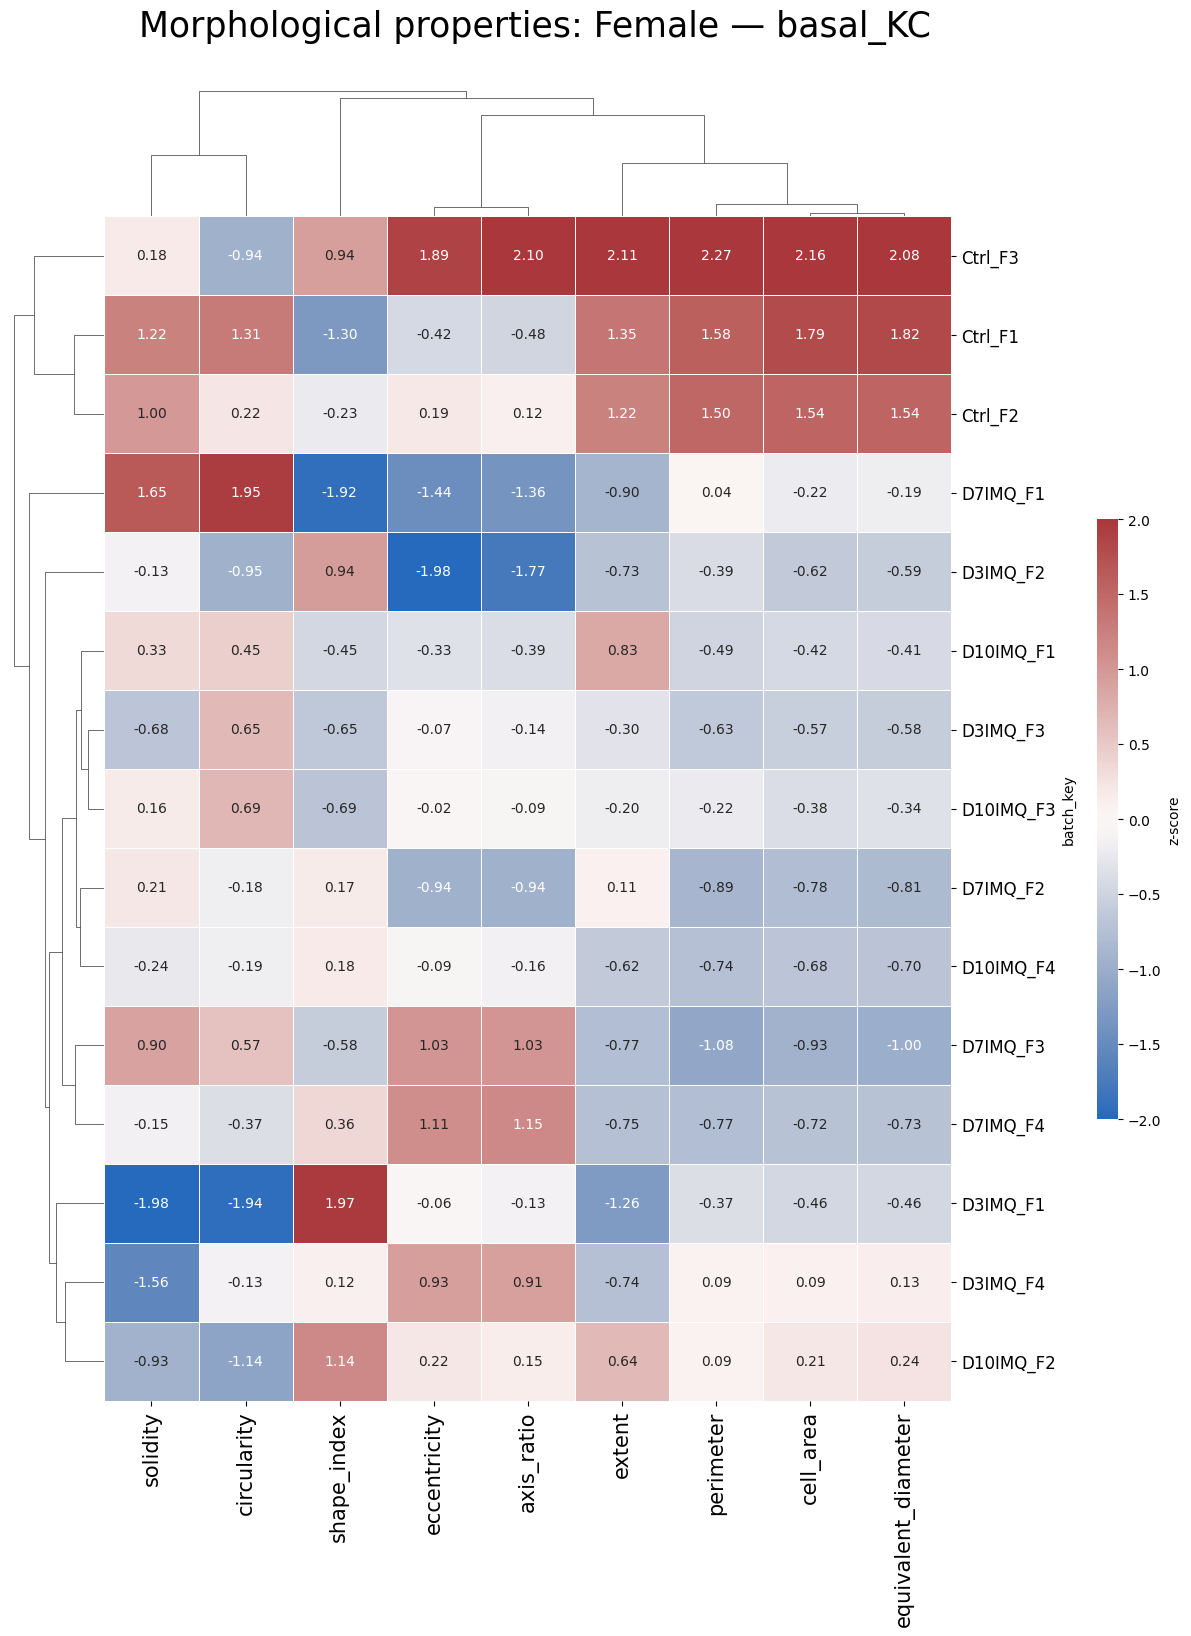

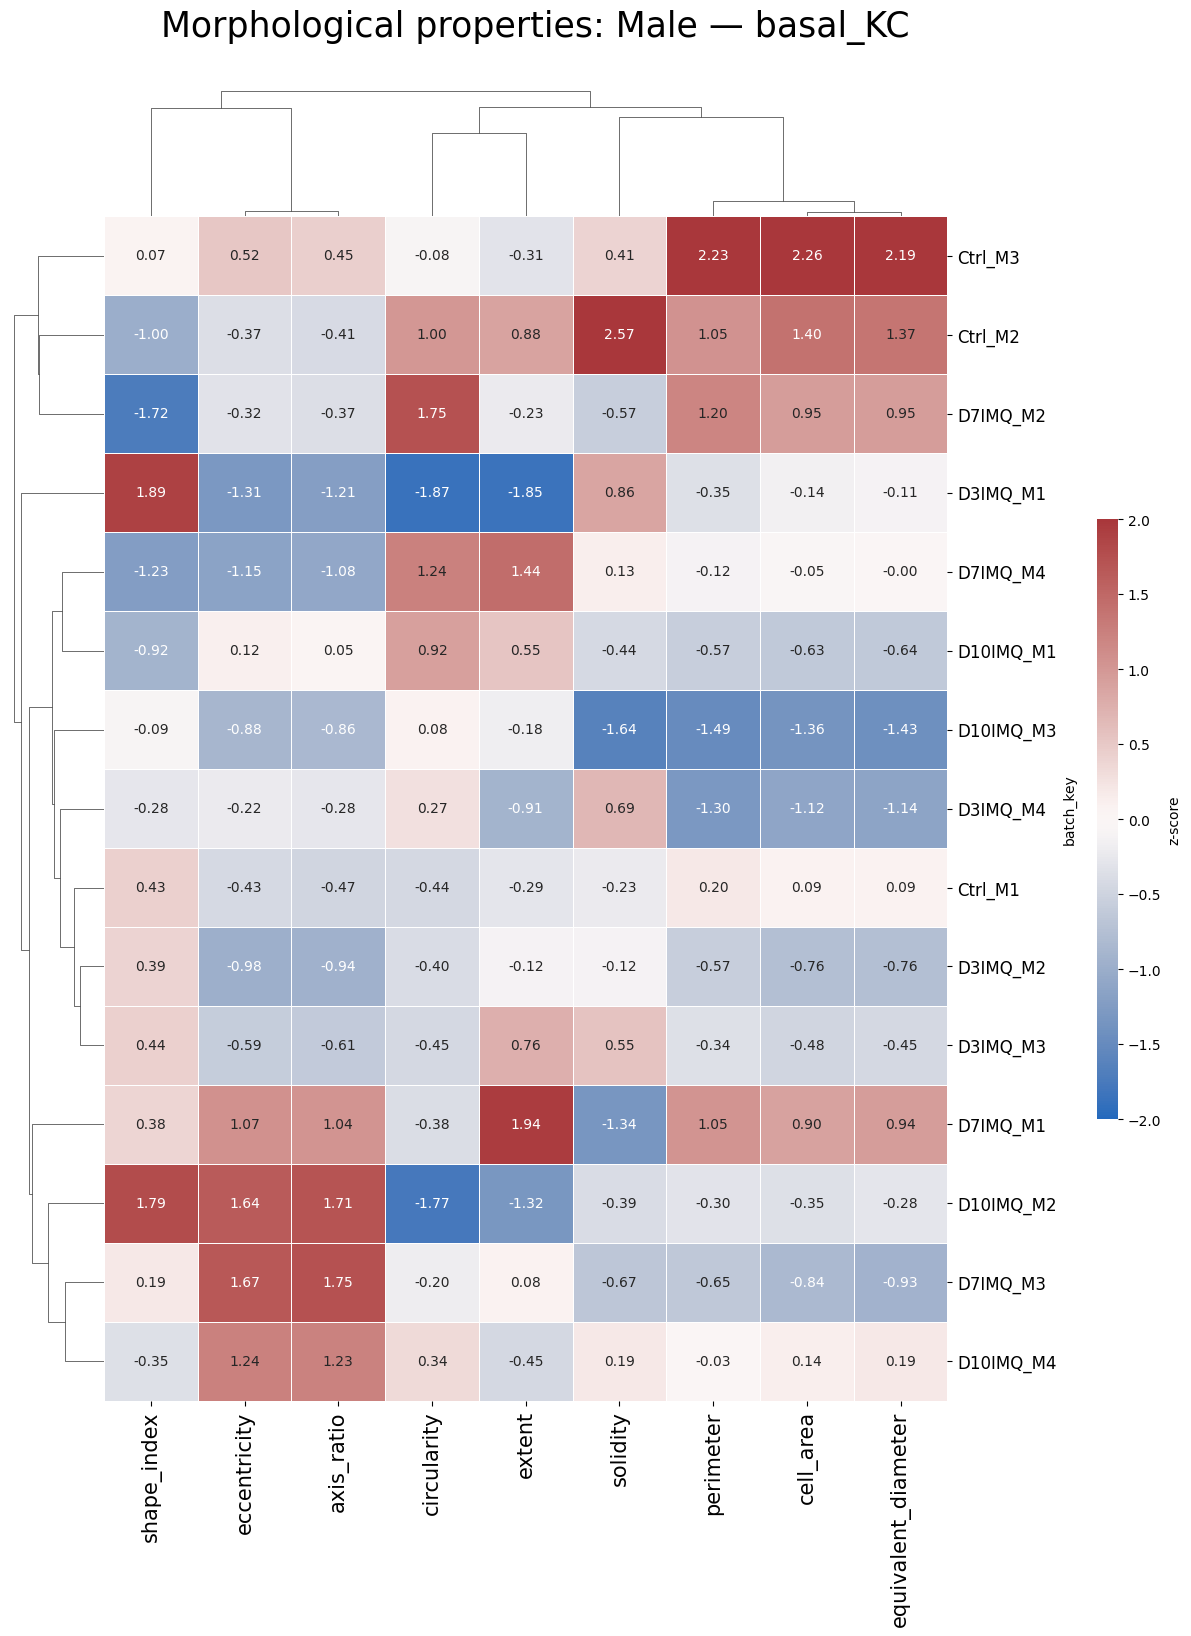

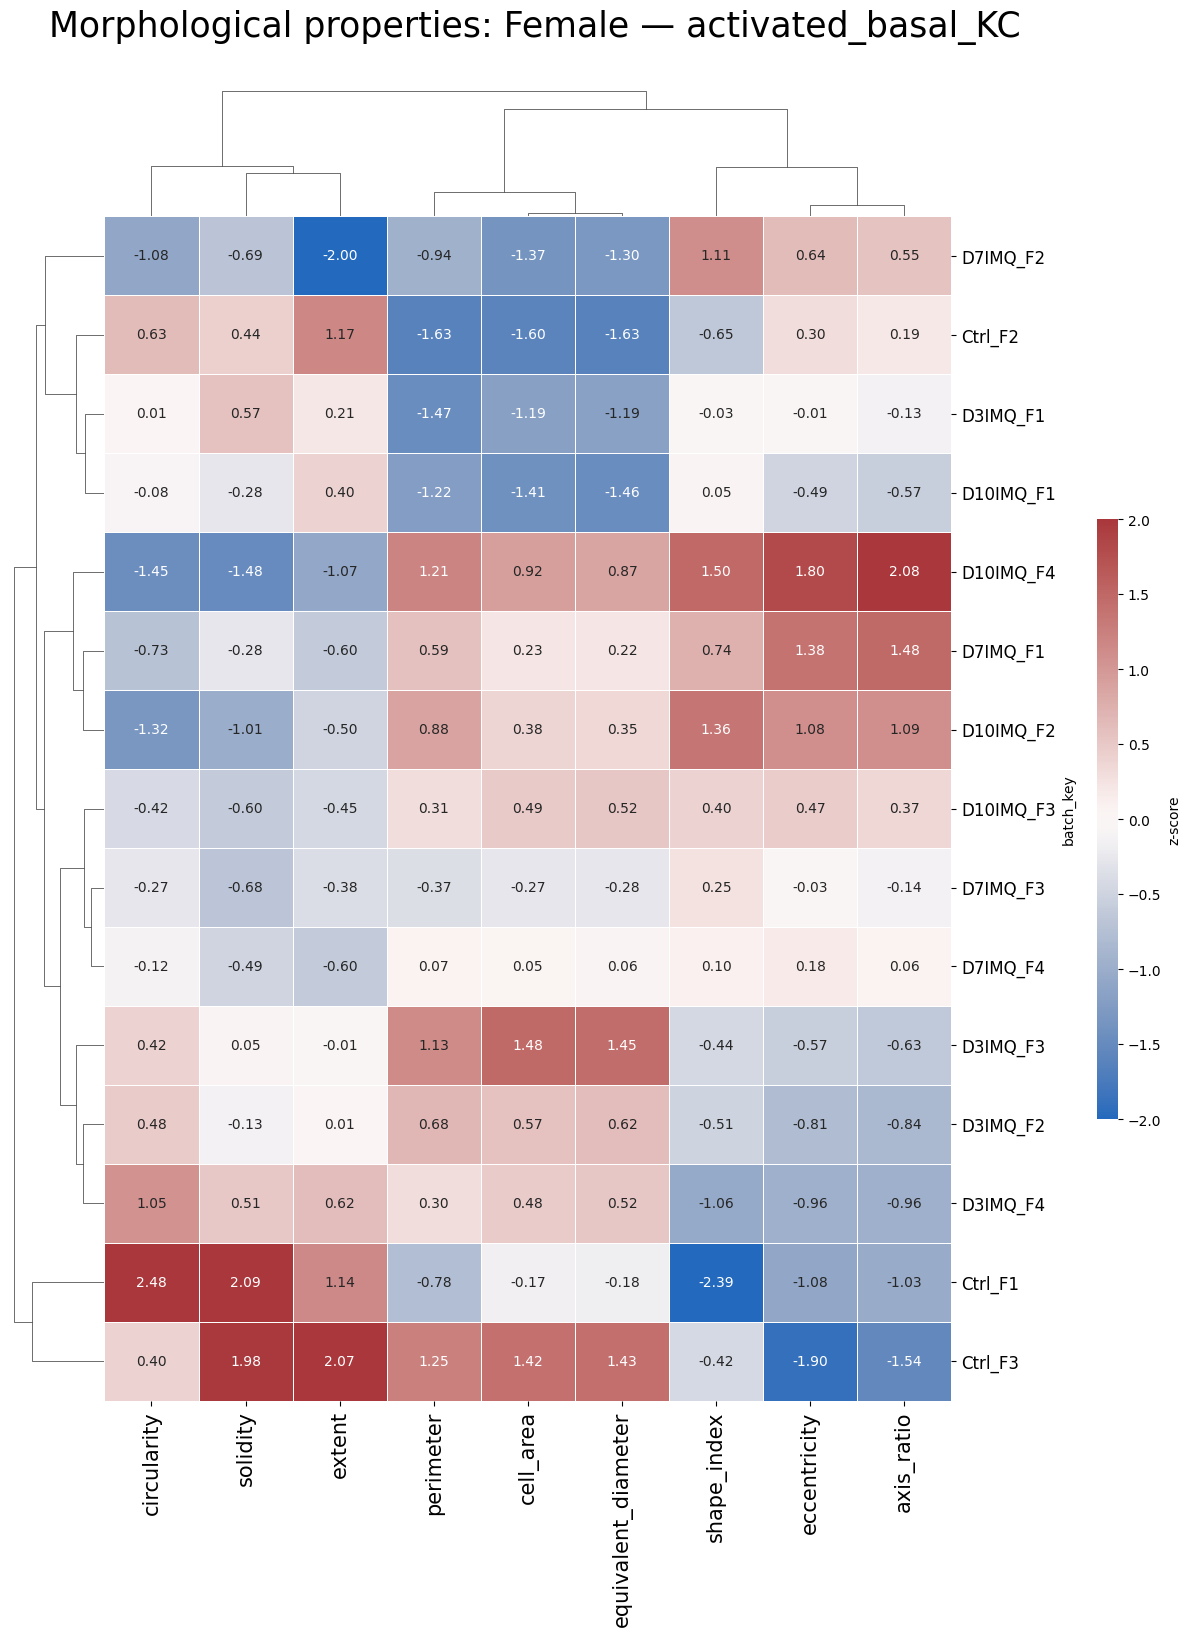

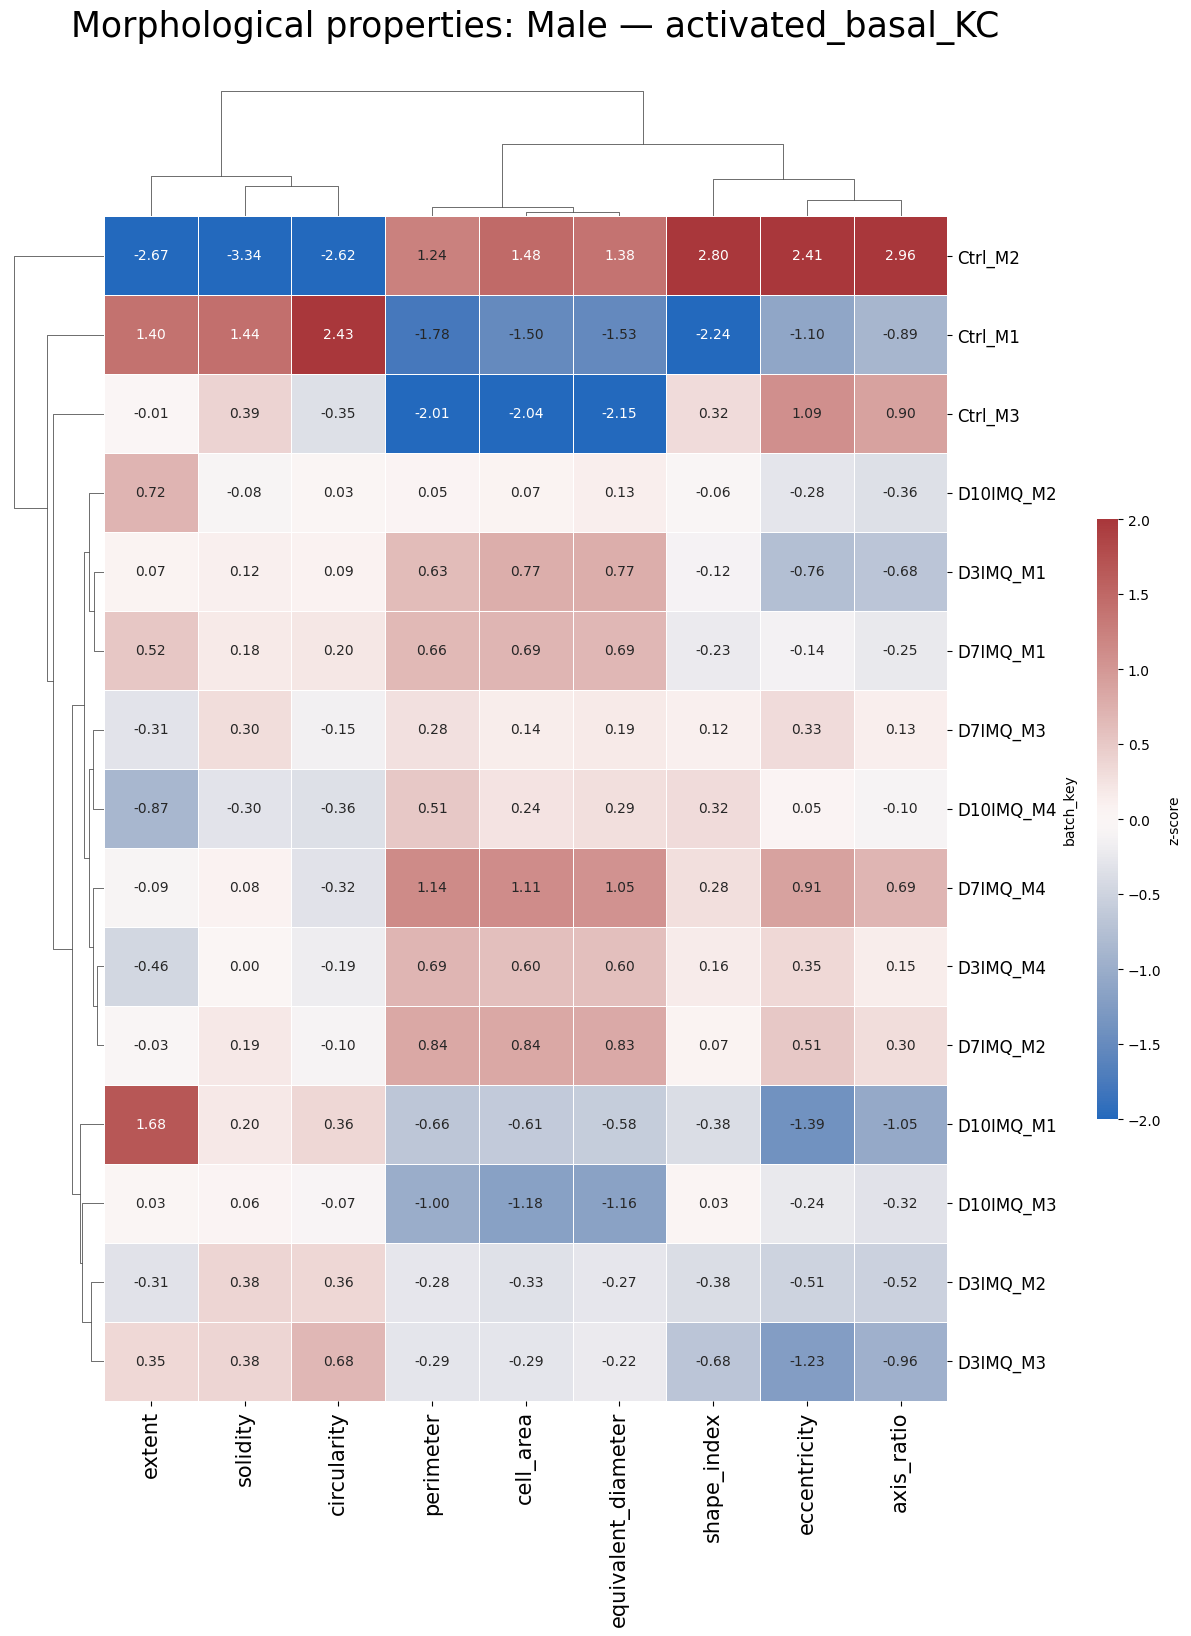

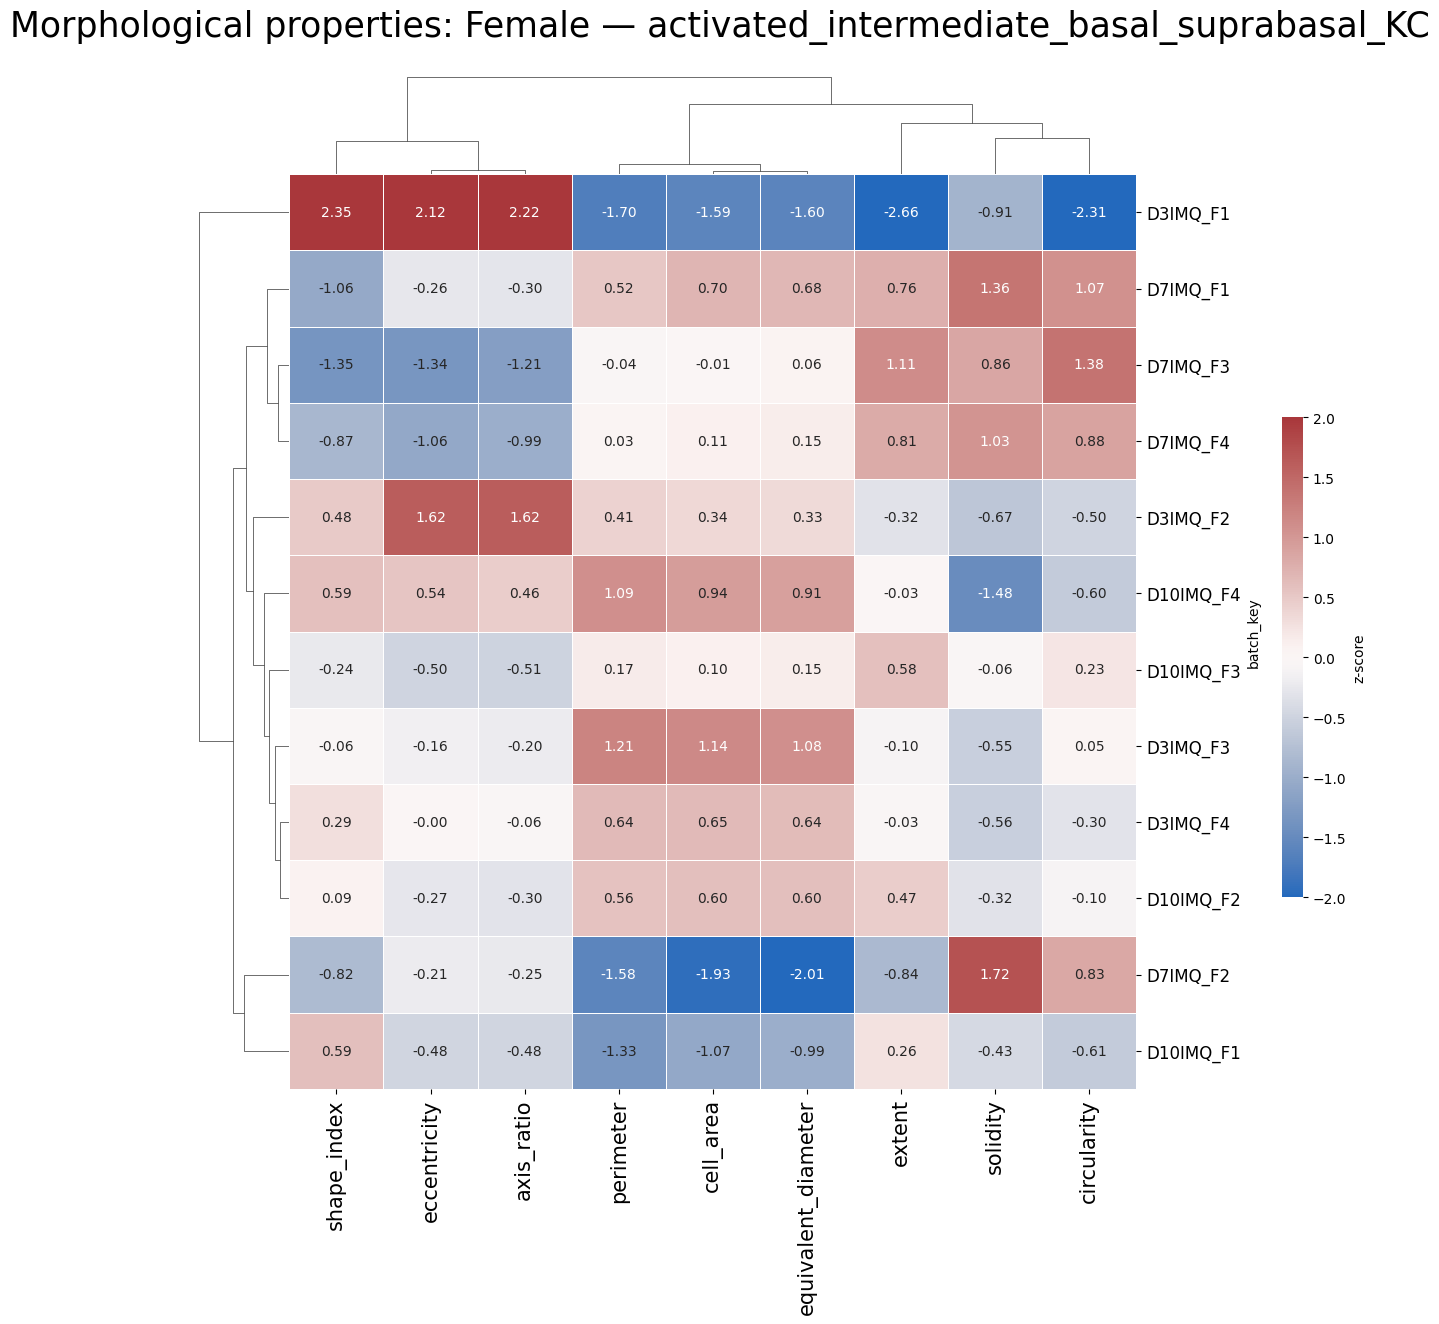

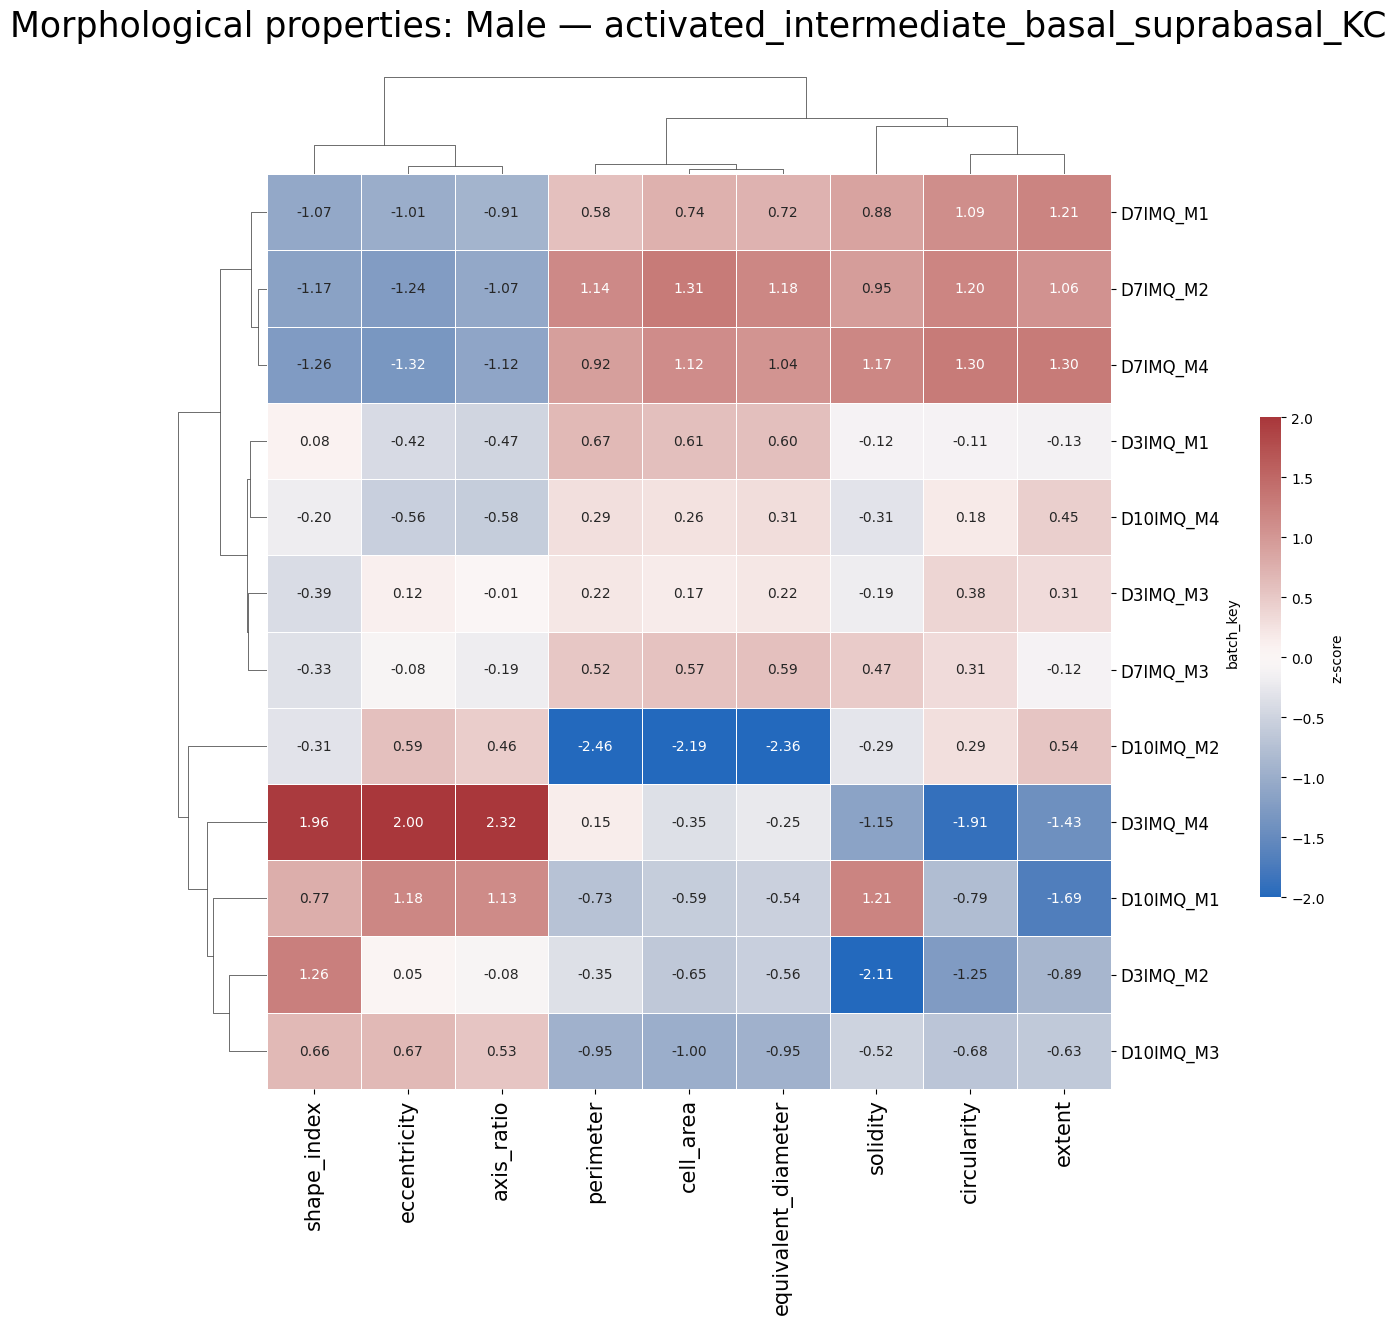

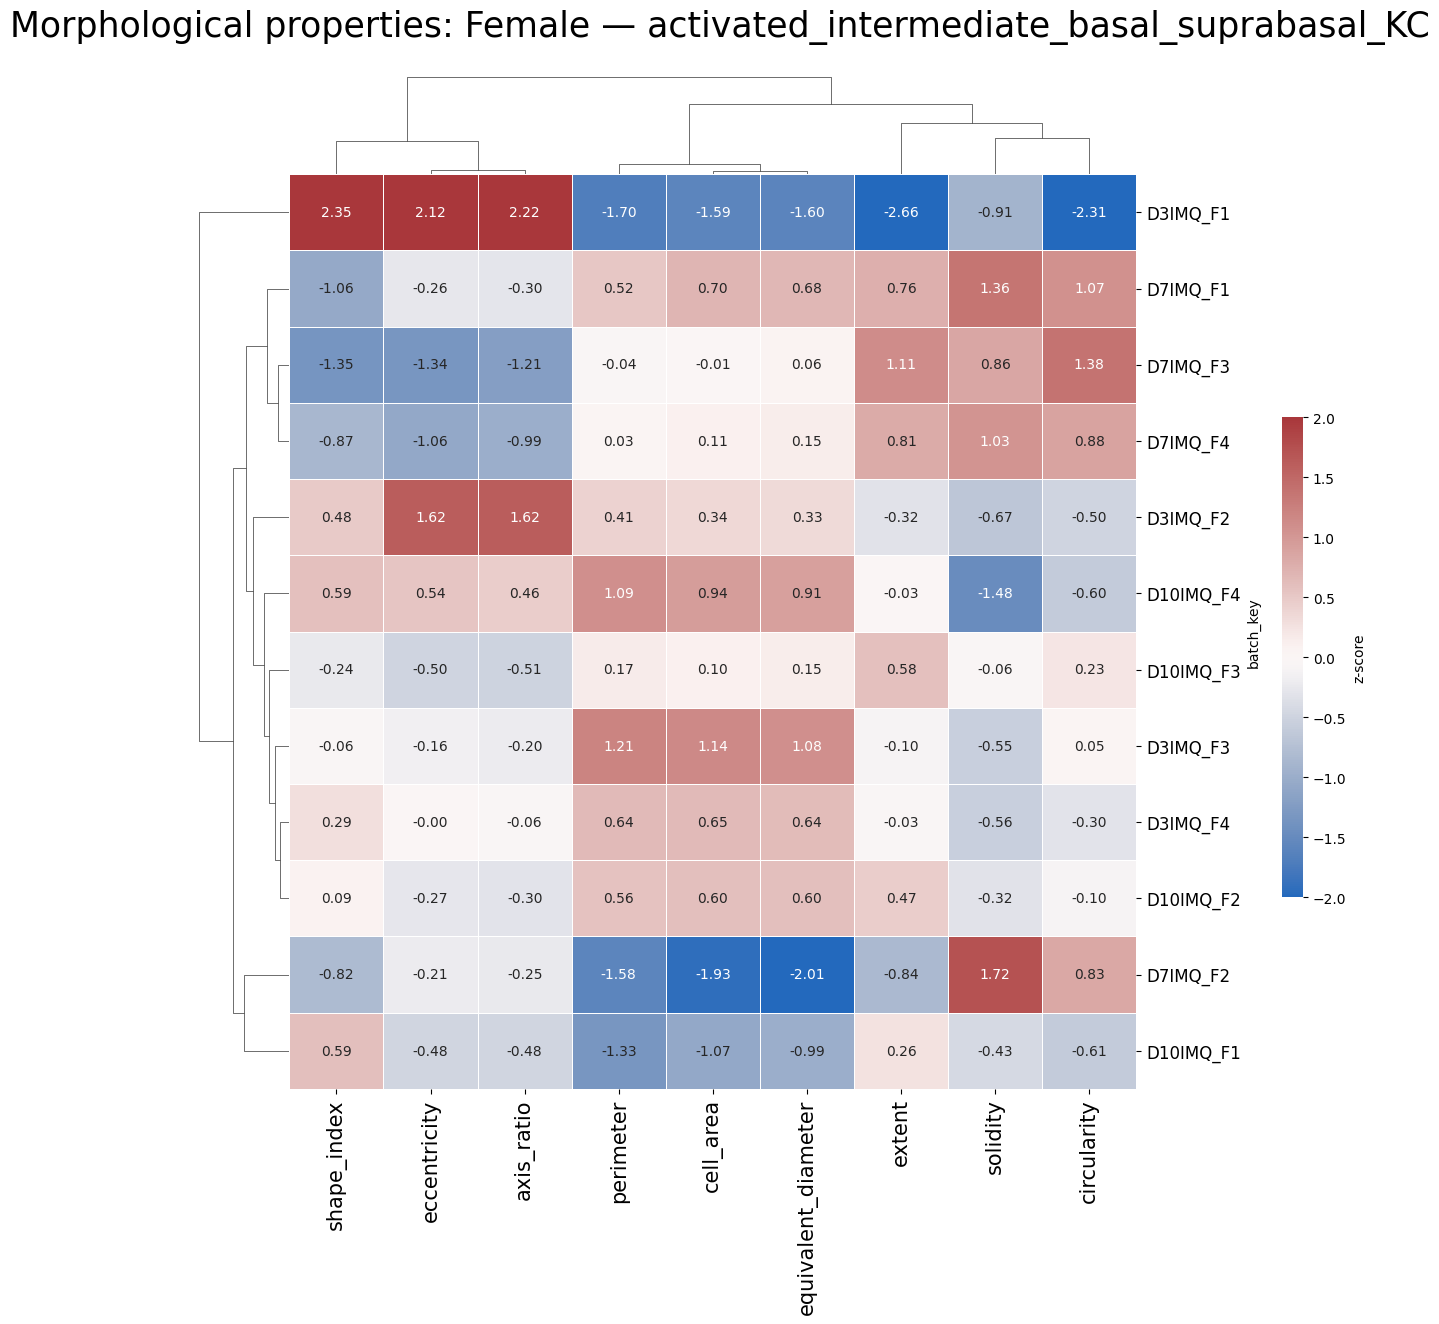

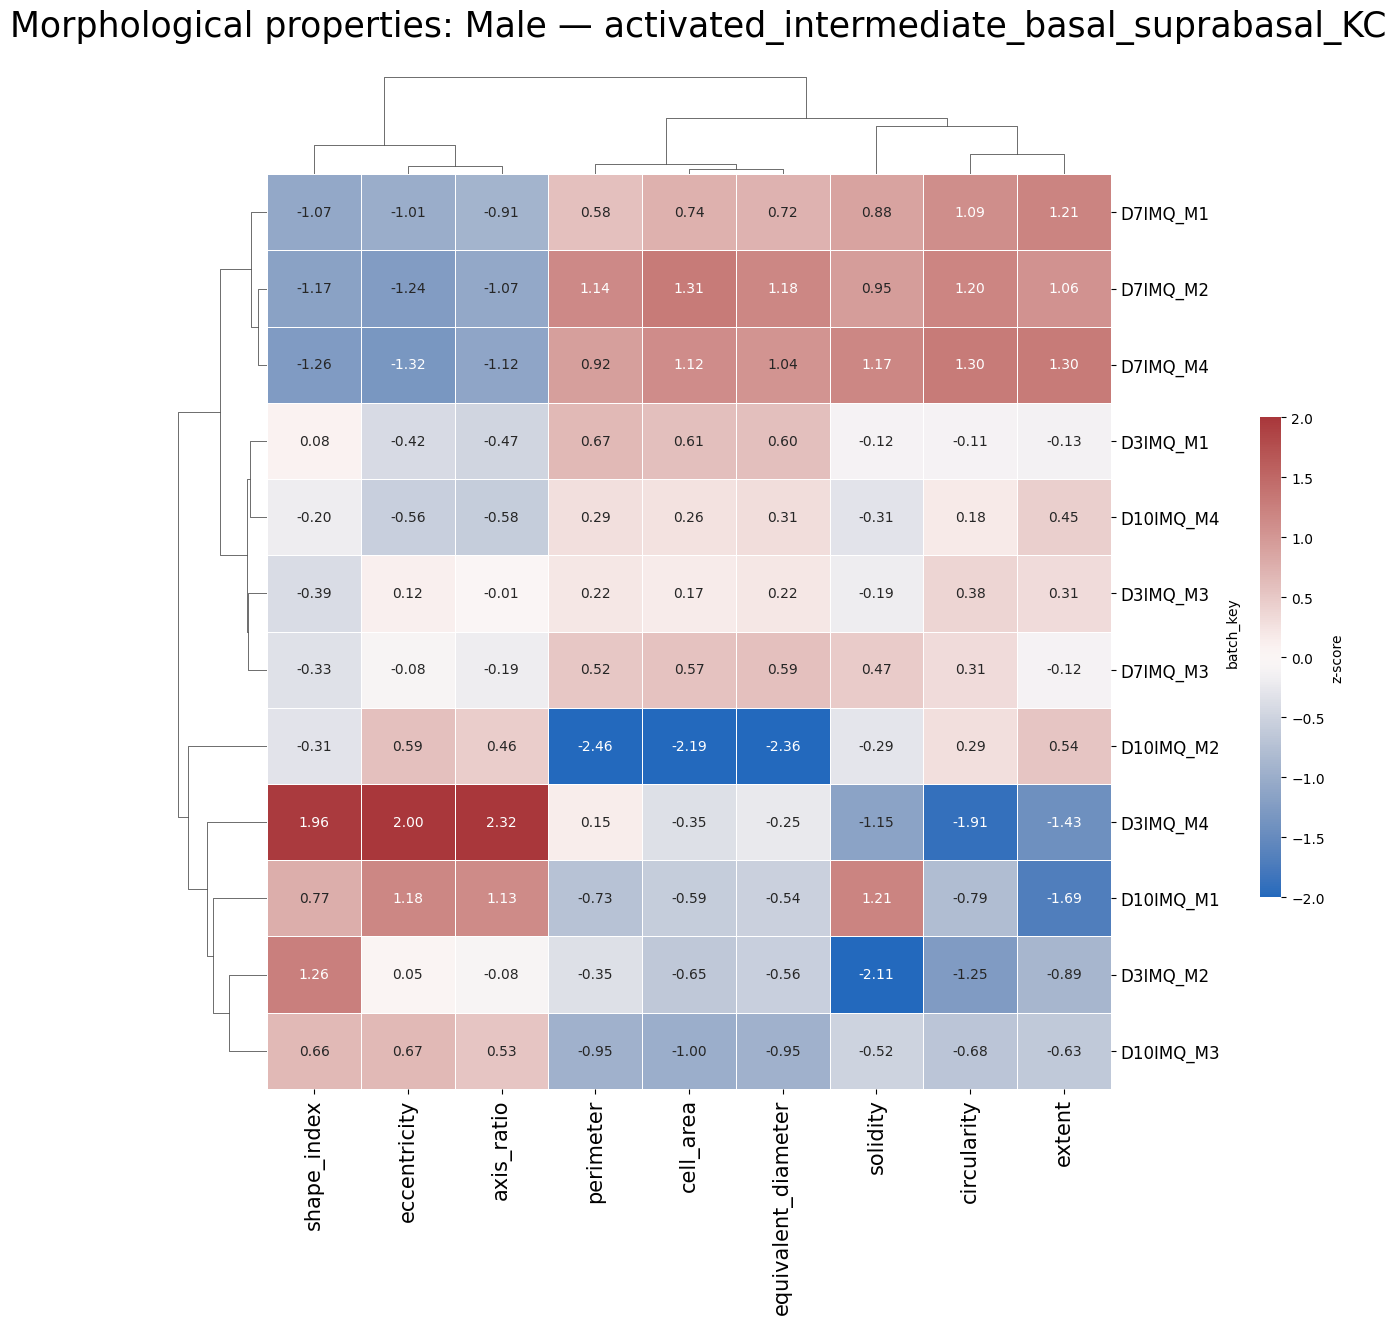

In [4]:
# Cluster map for a given celltype, comparing all properties across samples, splits by sex

#Cluster map of median of features vs sample for a given celltype
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

morph_props = ['cell_area', 'shape_index', 'solidity', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter']

def morph_heatmap(adata, celltype, group_by):
    """
    group_by is the sample grouping to use, either condition (course) or batch_key (fine)
    """
    for sex in ['_F', '_M']:
        data = adata.obs[(adata.obs['celltype_assignments'] == celltype) & (adata.obs['batch_key'].str.contains(sex))]

        # mean per sample per property
        mean_df = data.groupby(group_by, observed=True)[morph_props].median()

        # z-score normalise each property independently (column-wise)
        norm_df = (mean_df - mean_df.mean()) / mean_df.std()

        g = sns.clustermap(norm_df, cmap='vlag', annot=True, fmt='.2f',
                    linewidths=0.5, 
                    cbar_kws={'label': 'z-score'},
                    dendrogram_ratio=0.1,
                    cbar_pos =(1.02, 0.3, 0.02, 0.4),
                    figsize = (len(morph_props)*1.2, len(norm_df)*1.0))
        
        g.ax_heatmap.collections[0].set_clim(-2, 2)
        g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=15)
        g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=12, rotation=0)
        
        if sex == '_F':
            sexstr = 'Female'
        else:
            sexstr = 'Male'

        g.fig.suptitle(f'Morphological properties: {sexstr} — {celltype}', fontsize = 25, y=1.04)
        plt.show()


morph_heatmap(adata, 'basal_KC', group_by = 'batch_key')

morph_heatmap(adata, 'activated_basal_KC', group_by = 'batch_key')

morph_heatmap(adata, 'activated_intermediate_basal_suprabasal_KC', group_by = 'batch_key')

morph_heatmap(adata, 'activated_intermediate_basal_suprabasal_KC', group_by = 'batch_key')

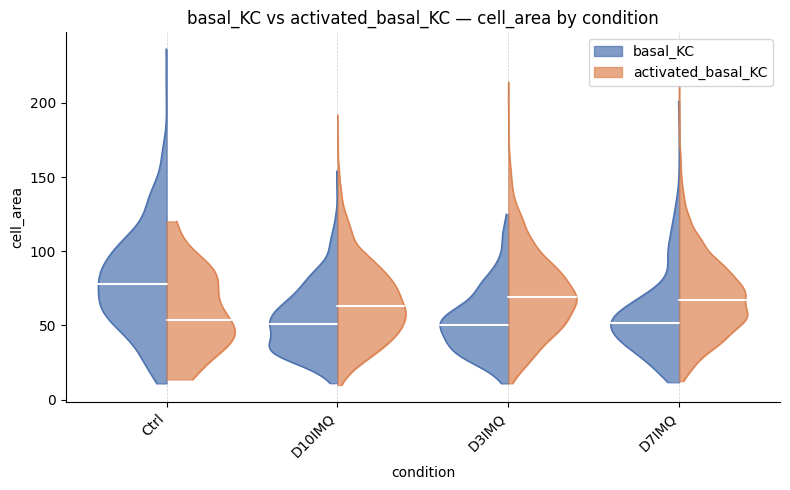

In [4]:
#violin plot of a property across samples (condition or batch_key)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import gaussian_kde

def violin_across_samples(celltypes, property, adata, grouping, group_order):
    """
    Plot violin plots for given celltypes across groups defined by `grouping` column.
    
    - Single celltype: one violin per group.
    - Two celltypes: split violin per group (left half = celltype 1, right half = celltype 2).
    """
    if group_order:
        group_order = group_order  # your desired order
        groups = sorted(adata.obs[grouping].dropna().unique(),
                key=lambda g: group_order.index(g)) 
    else:
        groups = sorted(adata.obs[grouping].dropna().unique())



    n_groups = len(groups)

    fig, ax = plt.subplots(figsize=(max(8, n_groups * 1.5), 5))
    colors = ['#4C72B0', '#DD8452']

    if len(celltypes) == 1:
        ct = celltypes[0]
        data, labels = [], []
        for grp in groups:
            mask = (adata.obs['celltype_assignments'] == ct) & (adata.obs[grouping] == grp)
            vals = adata.obs.loc[mask, property].dropna().values
            data.append(vals if len(vals) > 0 else np.array([np.nan]))
            labels.append(grp)

        parts = ax.violinplot(data, positions=range(1, n_groups + 1),
                              showmedians=True, showextrema=True)
        for pc in parts['bodies']:
            pc.set_facecolor(colors[0])
            pc.set_alpha(0.7)

        ax.set_xticks(range(1, n_groups + 1))
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_title(f'{ct} — {property} by {grouping}')

    elif len(celltypes) == 2:

        def draw_split_violin(ax, pos, left_data, right_data, width=0.8, color_left='#4C72B0', color_right='#DD8452'):
            """Draw a split violin: left half from left_data, right half from right_data."""
            for data, side, color in [(left_data, 'left', color_left),
                                       (right_data, 'right', color_right)]:
                if len(data) < 2:
                    continue

                kde = gaussian_kde(data, bw_method='scott')
                y_range = np.linspace(data.min(), data.max(), 200)
                density = kde(y_range)
                density = density / density.max() * (width / 2)  # normalise to half-width

                if side == 'left':
                    ax.fill_betweenx(y_range, pos - density, pos, alpha=0.7, color=color)
                    ax.plot(pos - density, y_range, color=color, lw=1)
                else:
                    ax.fill_betweenx(y_range, pos, pos + density, alpha=0.7, color=color)
                    ax.plot(pos + density, y_range, color=color, lw=1)

                # median line
                median = np.median(data)
                half_dens_at_median = kde(median)[0] / kde(y_range).max() * (width / 2)
                if side == 'left':
                    ax.plot([pos - half_dens_at_median, pos], [median, median],
                            color='white', lw=1.5, solid_capstyle='round')
                else:
                    ax.plot([pos, pos + half_dens_at_median], [median, median],
                            color='white', lw=1.5, solid_capstyle='round')

        for i, grp in enumerate(groups):
            pos = i + 1
            vals = []
            for ct in celltypes:
                mask = (adata.obs['celltype_assignments'] == ct) & (adata.obs[grouping] == grp)
                vals.append(adata.obs.loc[mask, property].dropna().values)

            draw_split_violin(ax, pos, left_data=vals[0], right_data=vals[1],
                              color_left=colors[0], color_right=colors[1])

            # centre dividing line
            ax.axvline(pos, color='grey', lw=0.5, linestyle='--', alpha=0.4)

        ax.set_xticks(range(1, n_groups + 1))
        ax.set_xticklabels(groups, rotation=45, ha='right')

        legend_patches = [mpatches.Patch(color=colors[i], alpha=0.7, label=ct)
                          for i, ct in enumerate(celltypes)]
        ax.legend(handles=legend_patches, loc='upper right')
        ax.set_title(f'{" vs ".join(celltypes)} — {property} by {grouping}')

    else:
        raise ValueError("Pass 1 or 2 celltypes.")

    ax.set_xlabel(grouping)
    ax.set_ylabel(property)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

violin_across_samples(['basal_KC', 'activated_basal_KC'], property = 'cell_area', adata = adata, grouping = 'condition', group_order = None)#, group_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ'])

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


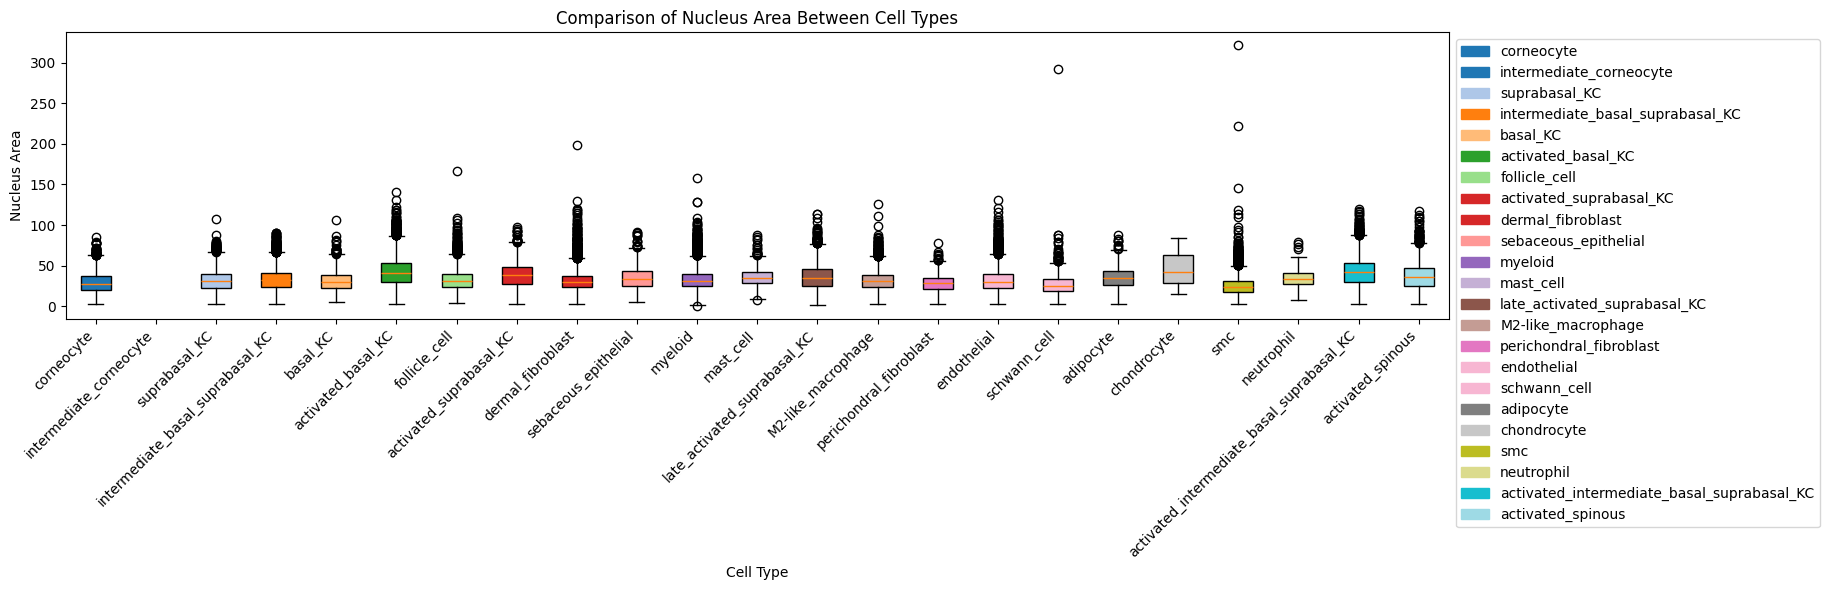

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


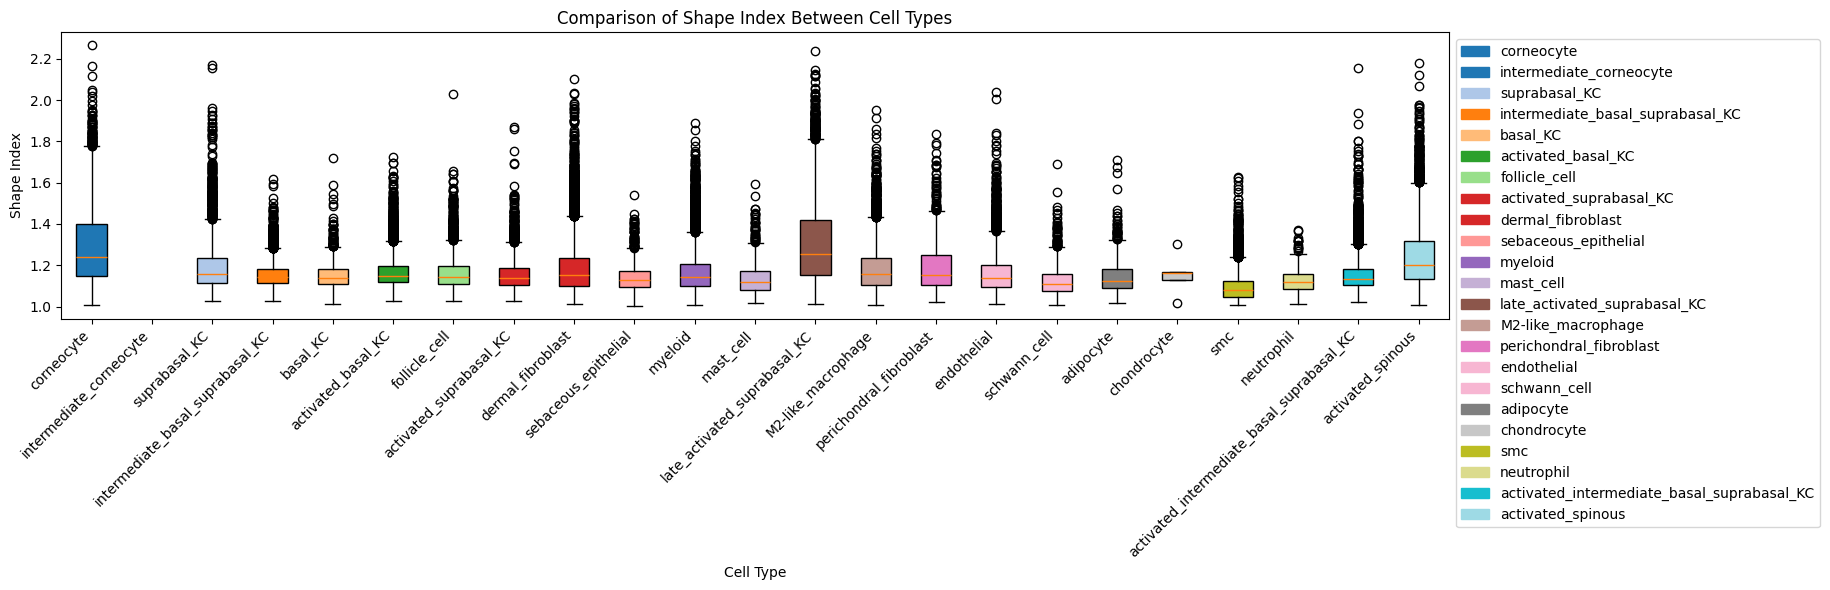

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


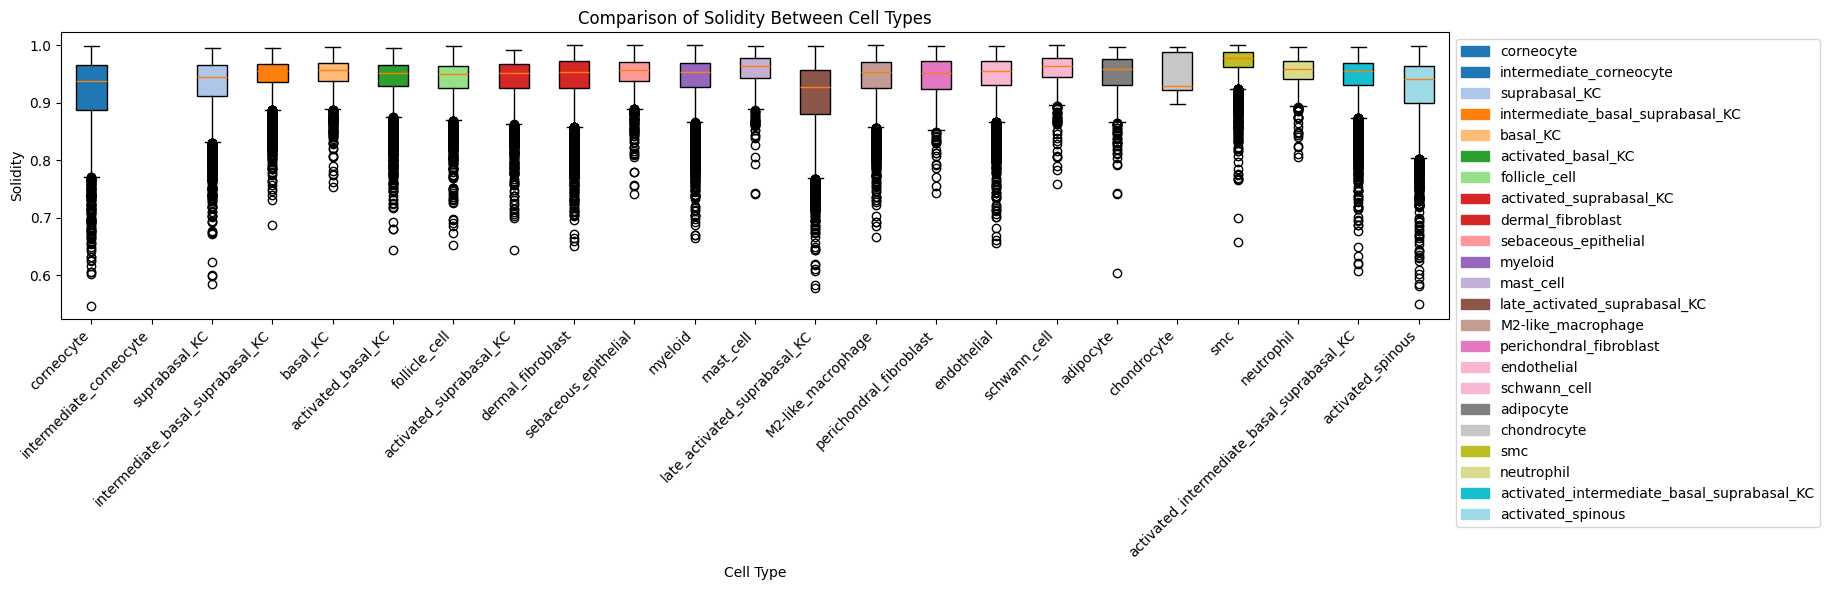

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


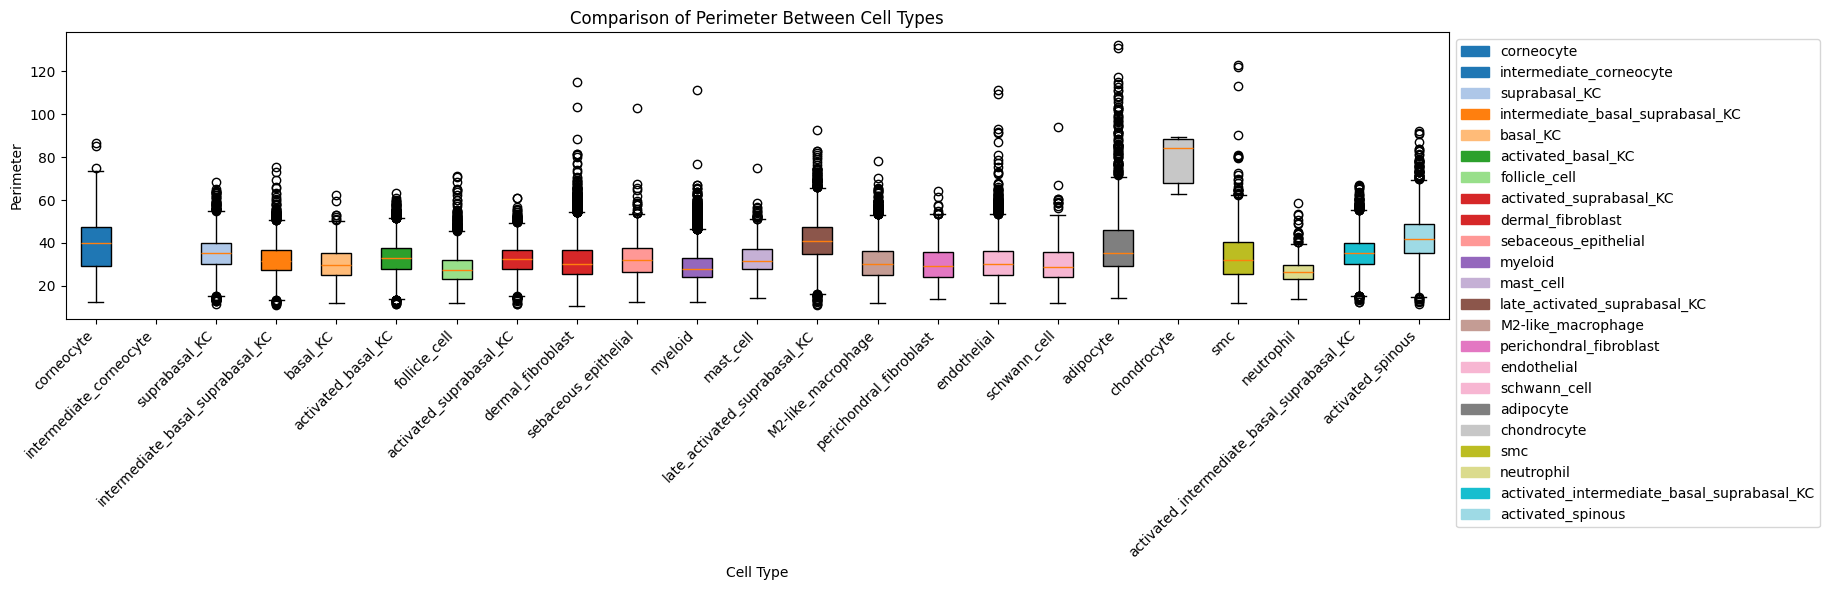

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


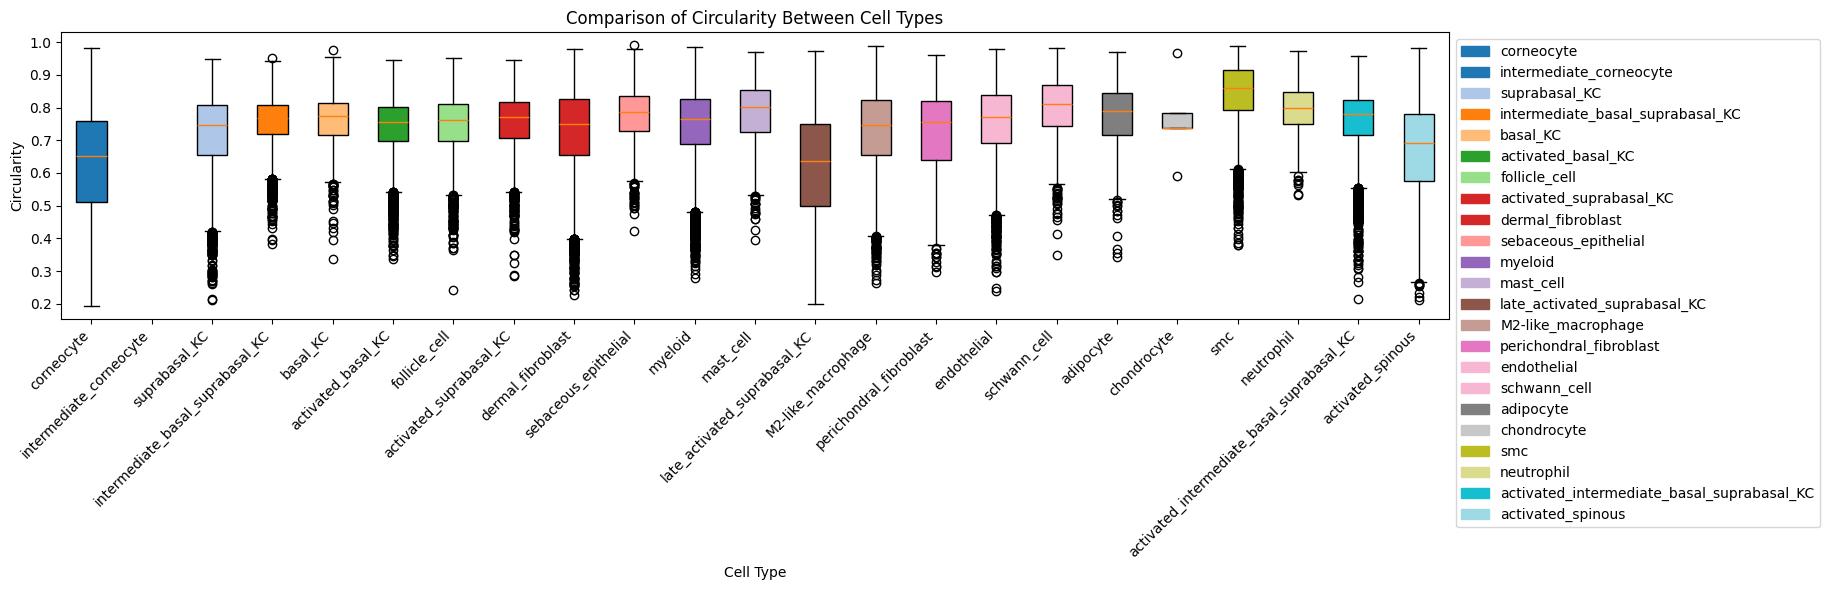

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


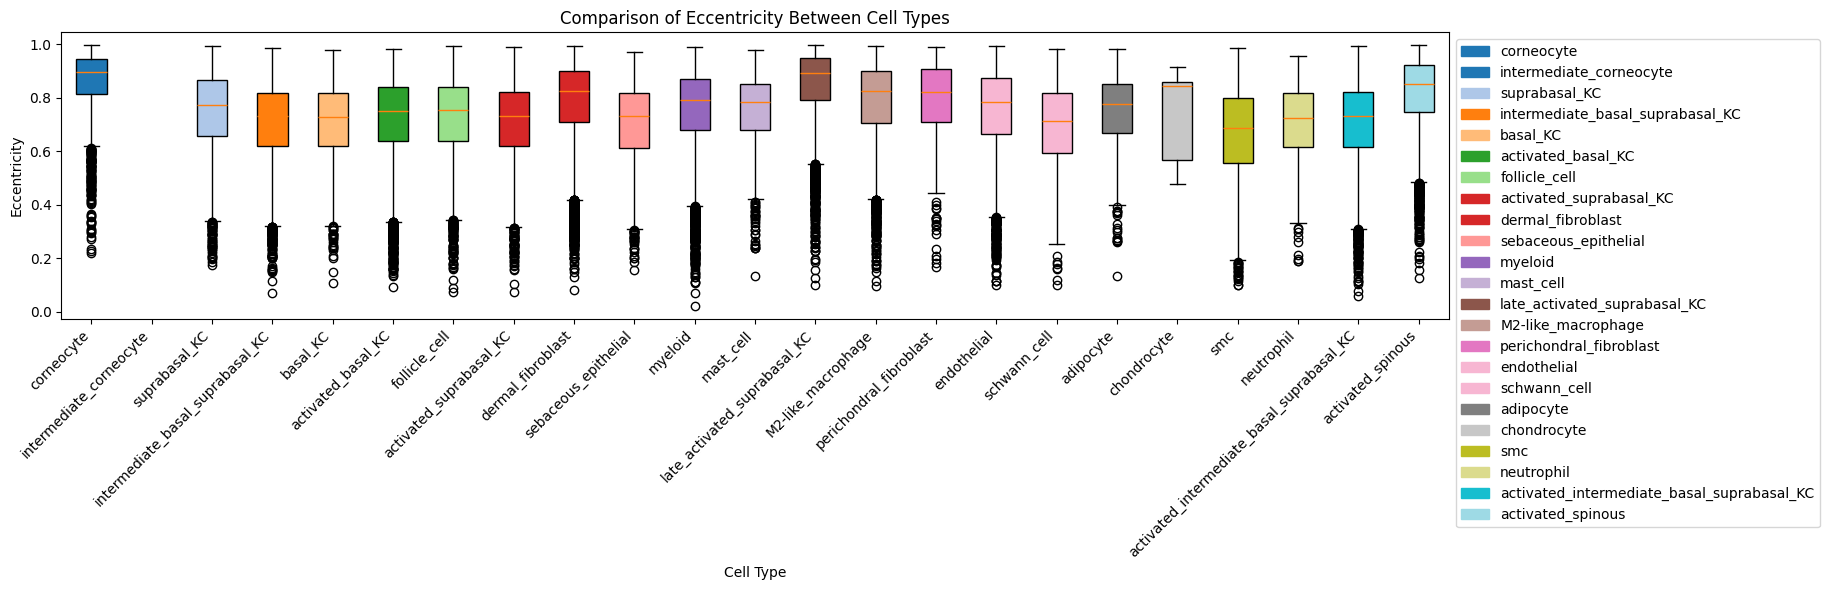

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


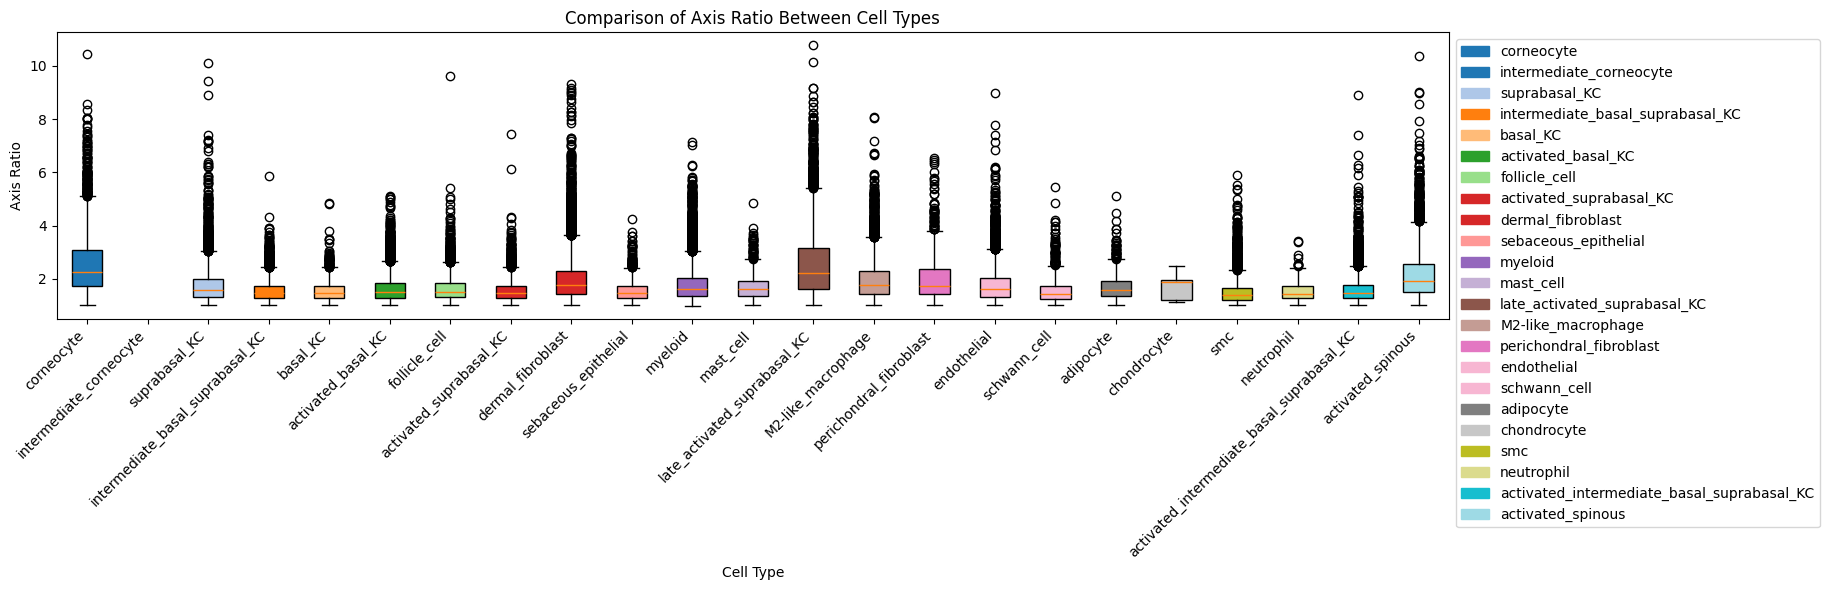

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


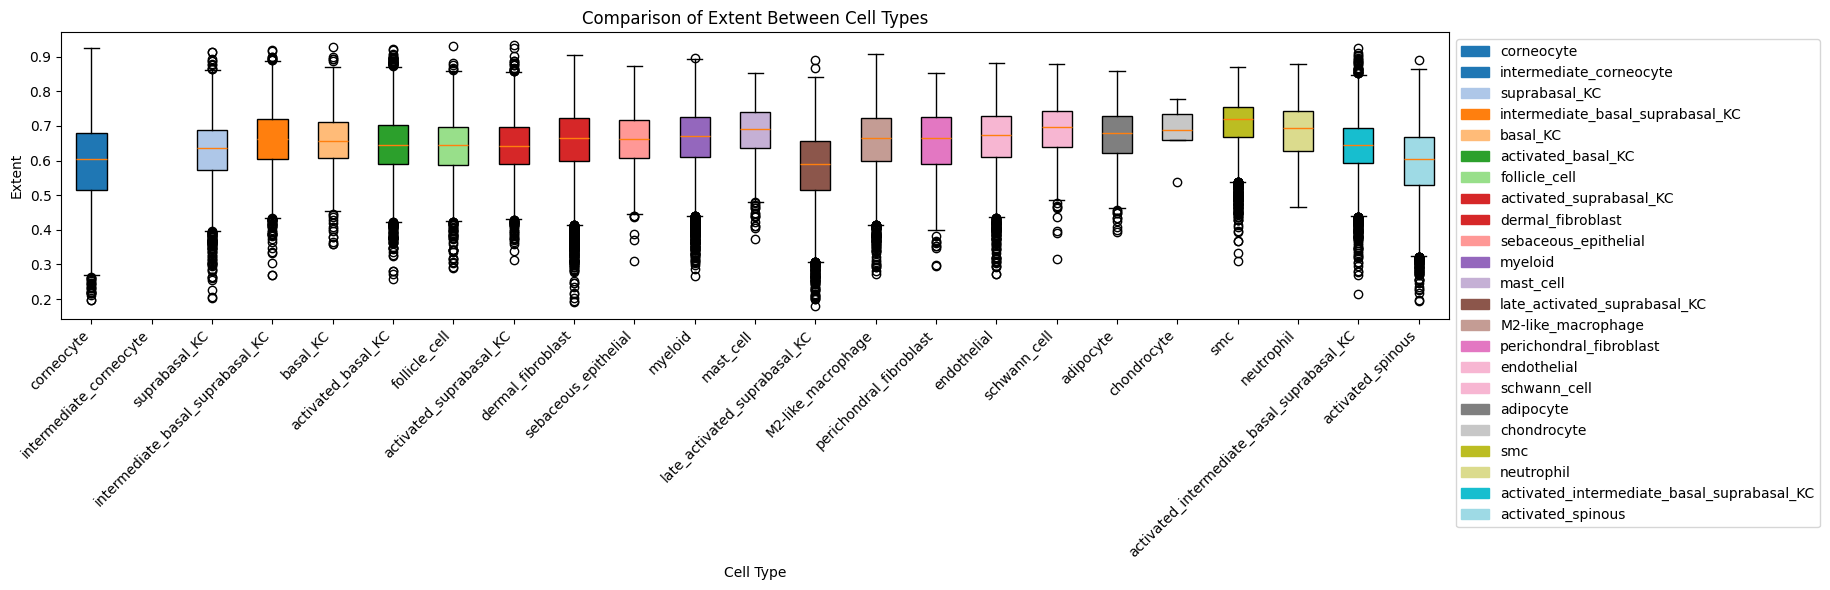

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_43084\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


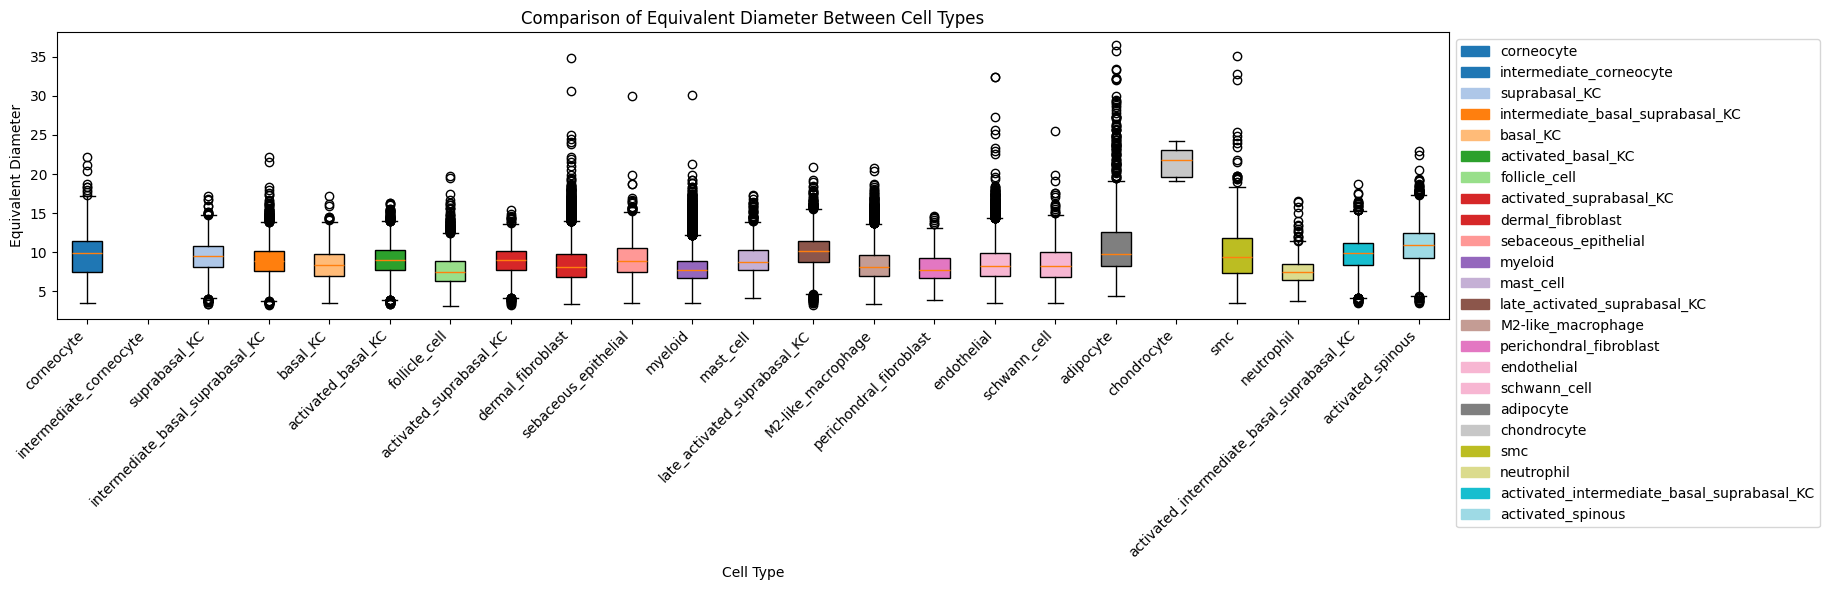

In [6]:
for property in ['nucleus_area', 'shape_index', 'solidity', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter']:
    compare_average(celltypes=['corneocyte',
    'intermediate_corneocyte',
    'suprabasal_KC',
    'intermediate_basal_suprabasal_KC',
    'basal_KC',
    'activated_basal_KC',
    'follicle_cell',
    'activated_suprabasal_KC',
    'dermal_fibroblast',
    'sebaceous_epithelial',
    'myeloid',
    'mast_cell',
    'late_activated_suprabasal_KC',
    'M2-like_macrophage',
    'perichondral_fibroblast',
    'endothelial',
    'schwann_cell',
    'adipocyte',
    'chondrocyte',
    'smc',
    'neutrophil',
    'activated_intermediate_basal_suprabasal_KC',
    'activated_spinous'], property = property, adata = adata)

In [ ]:
adata_f = adata[adata.obs.batch_key.str.contains('_F')].copy()
adata_m = adata[adata.obs.batch_key.str.contains('_M')].copy()
morph_heatmap(adata_f, 'myeloid', group_by = 'condition')
morph_heatmap(adata_m, 'myeloid', group_by = 'condition')


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_29792\1923466174.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = data.groupby(group_by)[morph_props].median()


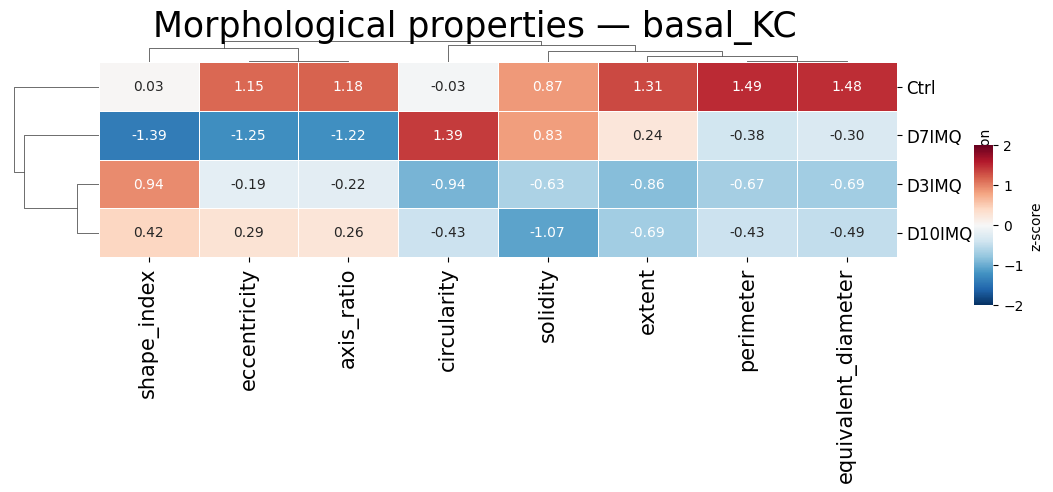

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_29792\1923466174.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = data.groupby(group_by)[morph_props].median()


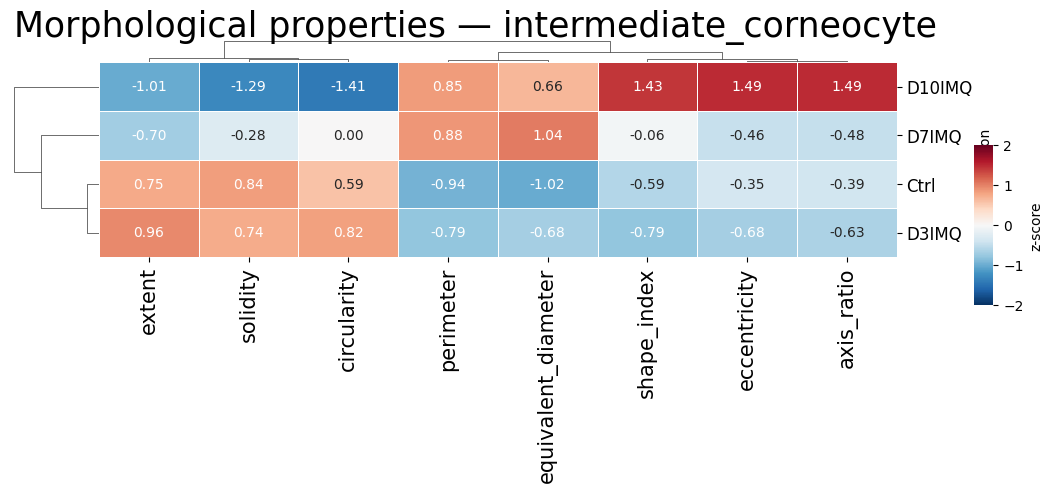

In [30]:
morph_heatmap(adata, 'basal_KC', group_by = 'condition')
morph_heatmap(adata, 'intermediate_corneocyte', group_by = 'condition')



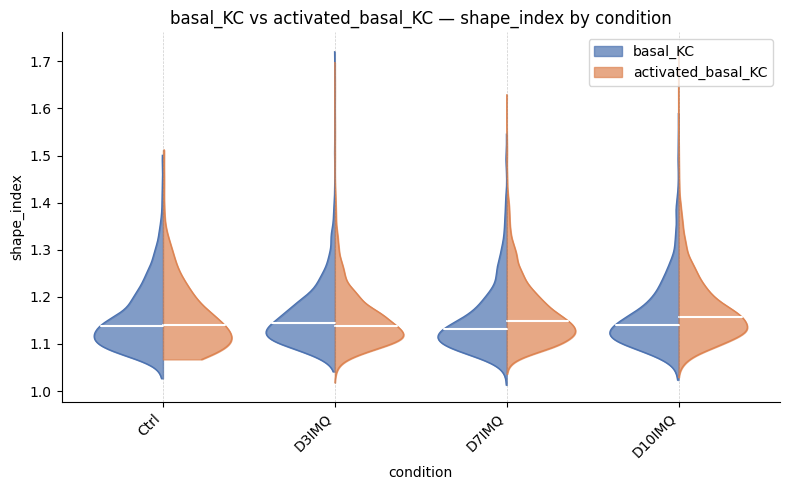

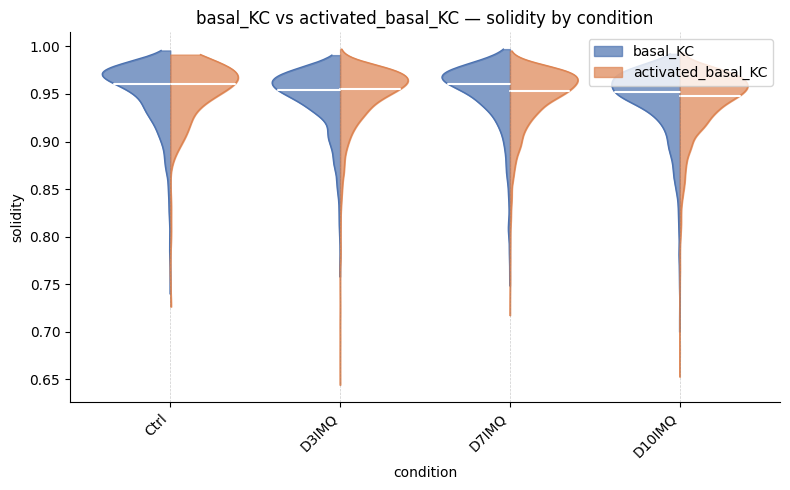

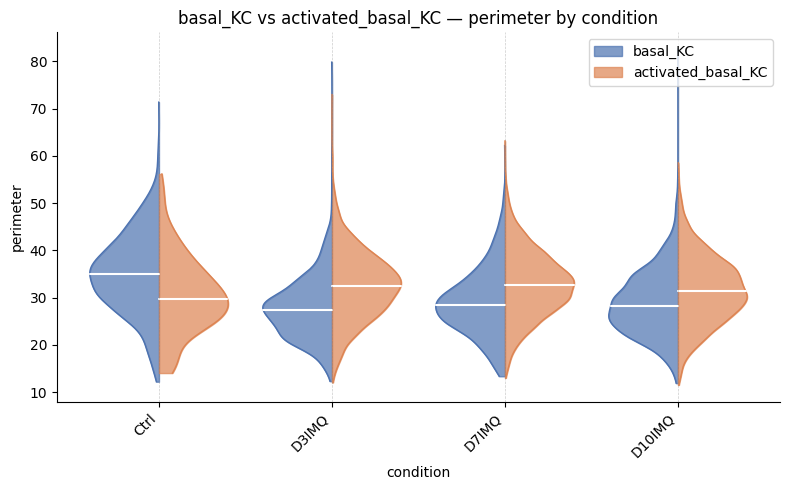

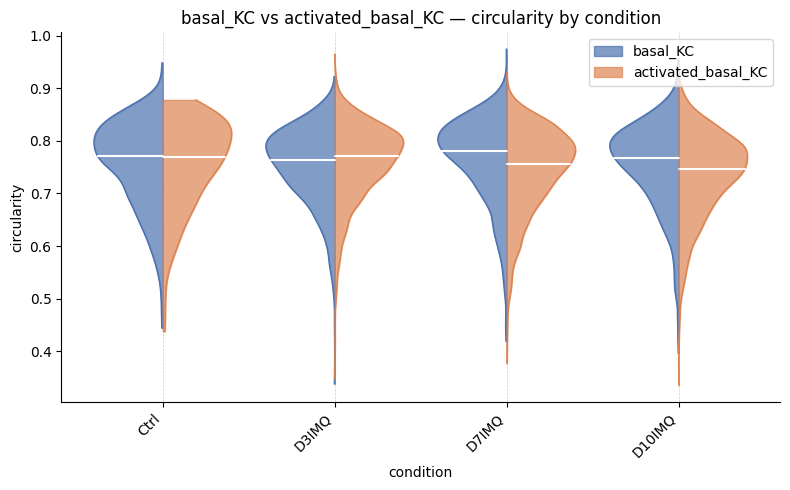

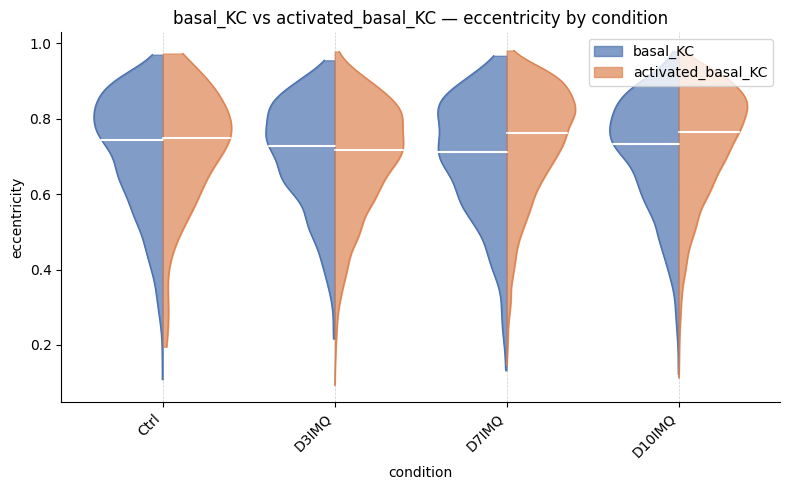

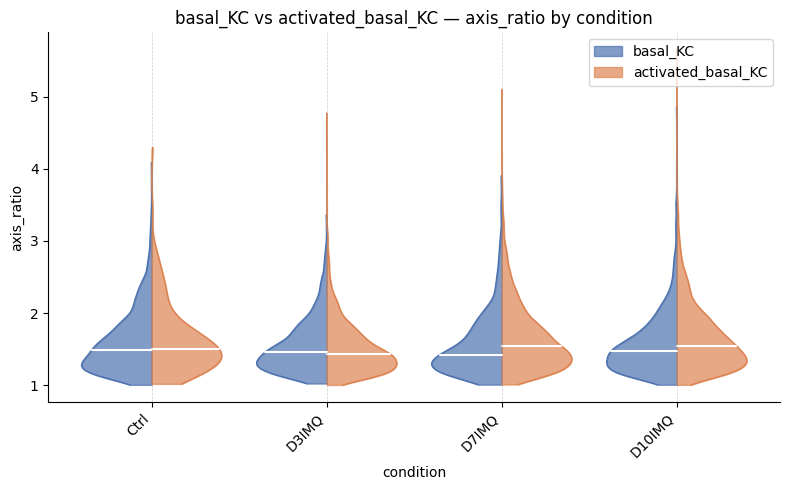

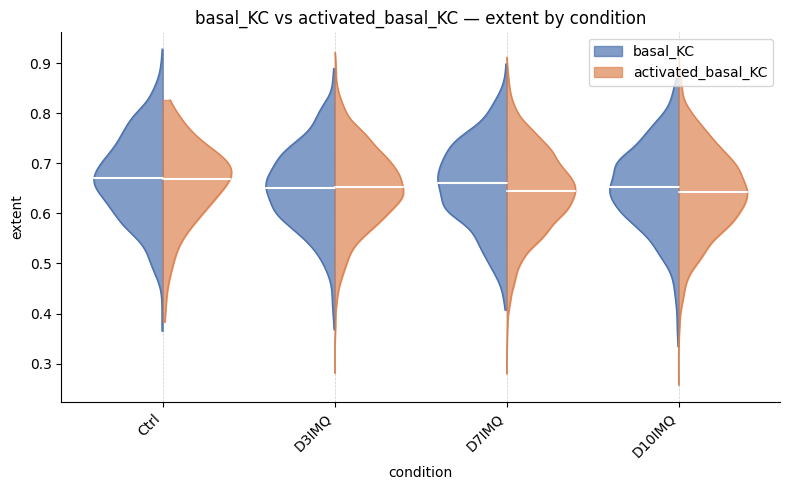

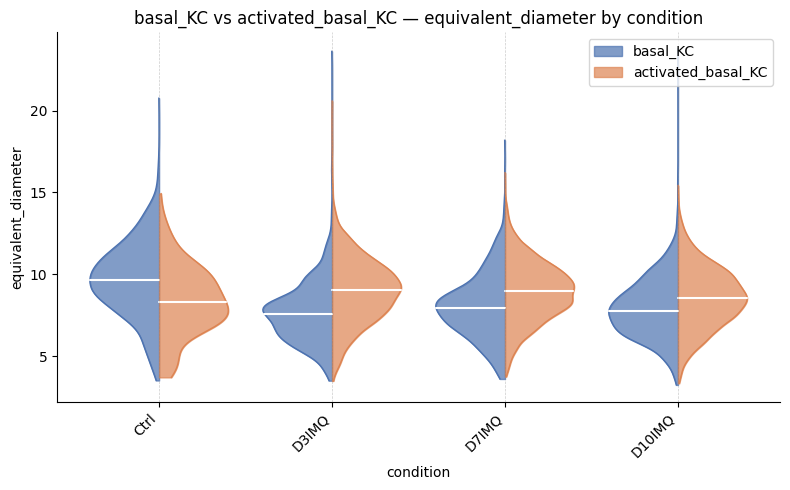

In [7]:
for property in morph_props:
    violin_across_samples(['basal_KC', 'activated_basal_KC'], property = property, adata = adata, grouping = 'condition', group_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ'])

# macrophage investigations

## mean + SE grouped plot of celltype property over conditions, with option for multiple celltypes
#### plot_property_over_condition_by_sex()

In [14]:
#stats version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


def _asterisks(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""


def plot_property_over_condition_by_sex(
    adata,
    celltypes,
    property_name,
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
    sex_order=("F", "M"),
    figsize=(14, 5),
    bar_width=0.18,
    capsize=4,
    file_name=None,
):
    # ==========================================
    # --- FONT SIZE CONFIGURATION ---
    # ==========================================
    SUPTITLE_SIZE    = 35   # Down from 25 (Main overall title)
    SUBPLOT_TITLE    = 25   # Down from 20 (Individual Female/Male titles)
    AXIS_LABEL_SIZE  = 23   # Down from 18/15
    TICK_LABEL_SIZE  = 20   # Controls both X and Y axis tick marks
    LEGEND_SIZE      = 18   
    P_VAL_STAR_SIZE  = 13    # Down from 10 (Significance stars)
    # ==========================================

    if property_name not in adata.obs.columns:
        raise KeyError(f"'{property_name}' not found in adata.obs")
    if celltype_col not in adata.obs.columns:
        raise KeyError(f"'{celltype_col}' not found in adata.obs")
    if batch_col not in adata.obs.columns:
        raise KeyError(f"'{batch_col}' not found in adata.obs")

    celltypes = list(celltypes)

    df = adata.obs[[celltype_col, property_name, batch_col]].copy()
    df = df[df[celltype_col].isin(celltypes)].copy()

    if df.empty:
        raise ValueError("No rows found for the requested cell types.")

    split_df = df[batch_col].astype(str).str.split("_", n=1, expand=True)
    if split_df.shape[1] < 2:
        raise ValueError(
            f"Could not split '{batch_col}' into condition and sex/replicate using '_'"
        )

    df["condition"] = split_df[0]
    sex_rep = split_df[1]
    df["sex"] = sex_rep.str[0]
    df["replicate"] = sex_rep.str[1:]

    df = df[df["condition"].isin(condition_order)].copy()
    df = df[df["sex"].isin(sex_order)].copy()

    # Step 1: average across cells within each biological replicate
    replicate_means = (
        df.groupby([celltype_col, "condition", "sex", batch_col], observed=True)[property_name]
        .mean()
        .reset_index(name="replicate_mean")
    )

    # Step 2: summary stats (mean ± SEM) across replicates
    def sem(x):
        x = x.dropna()
        n = x.shape[0]
        return 0.0 if n <= 1 else x.std(ddof=1) / np.sqrt(n)

    summary = (
        replicate_means.groupby([celltype_col, "condition", "sex"], observed=True)
        .agg(
            mean_property=("replicate_mean", "mean"),
            sem_property=("replicate_mean", sem),
            n_replicates=("replicate_mean", "count"),
        )
        .reset_index()
    )

    # Step 3: Welch's t-tests + BH correction per celltype × sex
    test_conditions = [c for c in condition_order if c != "Ctrl"]
    sig_results = {}

    for ct in celltypes:
        for sex in sex_order:
            ctrl_vals = replicate_means[
                (replicate_means[celltype_col] == ct)
                & (replicate_means["condition"] == "Ctrl")
                & (replicate_means["sex"] == sex)
            ]["replicate_mean"].dropna().values

            raw_pvals = []
            valid_conditions = []

            for cond in test_conditions:
                cond_vals = replicate_means[
                    (replicate_means[celltype_col] == ct)
                    & (replicate_means["condition"] == cond)
                    & (replicate_means["sex"] == sex)
                ]["replicate_mean"].dropna().values

                if len(ctrl_vals) >= 2 and len(cond_vals) >= 2:
                    _, p = ttest_ind(ctrl_vals, cond_vals, equal_var=False)
                    raw_pvals.append(p)
                    valid_conditions.append(cond)

            if raw_pvals:
                _, corrected_pvals, _, _ = multipletests(raw_pvals, method="fdr_bh")
                for cond, q in zip(valid_conditions, corrected_pvals):
                    stars = _asterisks(q)
                    sig_results[(ct, sex, cond)] = (q, stars) if stars else None
            
            for cond in test_conditions:
                if (ct, sex, cond) not in sig_results:
                    sig_results[(ct, sex, cond)] = None

    # Build color map
    if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):
        categories = list(adata.obs[celltype_col].cat.categories)
    else:
        categories = list(pd.unique(adata.obs[celltype_col].astype(str)))

    colors = adata.uns[f"{celltype_col}_colors"]
    color_map = dict(zip(categories, colors))

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    if len(sex_order) != 2:
        raise ValueError("This function currently expects exactly two sexes in sex_order.")

    n_celltypes = len(celltypes)
    n_conditions = len(condition_order)
    x = np.arange(n_conditions)

    offsets = (np.arange(n_celltypes) - (n_celltypes - 1) / 2) * bar_width
    sex_titles = {"F": "Female", "M": "Male"}

    for ax, sex in zip(axes, sex_order):
        for i, ct in enumerate(celltypes):
            ct_data = summary[(summary[celltype_col] == ct) & (summary["sex"] == sex)].copy()
            ct_data["condition"] = pd.Categorical(
                ct_data["condition"], categories=list(condition_order), ordered=True
            )
            ct_data = (
                ct_data.sort_values("condition")
                .set_index("condition")
                .reindex(condition_order)
            )

            means = ct_data["mean_property"].to_numpy()
            sems  = ct_data["sem_property"].to_numpy()

            if np.all(np.isnan(means)):
                continue

            color = color_map.get(ct, "grey")
            label = ct.replace("_", " ")
            bar_positions = x + offsets[i]

            ax.bar(
                bar_positions,
                np.nan_to_num(means),
                width=bar_width,
                color=color,
                label=label,
                alpha=0.85,
                zorder=2,
            )
            valid = ~np.isnan(means)
            ax.errorbar(
                bar_positions[valid],
                means[valid],
                yerr=sems[valid],
                fmt="none",
                ecolor="black",
                elinewidth=1.2,
                capsize=capsize,
                zorder=3,
            )

            # Step 4: annotate significant comparisons
            for j, cond in enumerate(condition_order):
                if cond == "Ctrl":
                    continue
                result = sig_results.get((ct, sex, cond))
                if result is None:
                    continue
                q, stars = result
                bar_top = np.nan_to_num(means[j]) + (sems[j] if not np.isnan(sems[j]) else 0)
                x_pos = bar_positions[j]
                y_offset = ax.get_ylim()[1] * 0.02 if ax.get_ylim()[1] != 0 else 0.01
                ax.text(
                    x_pos,
                    bar_top + y_offset,
                    f"{stars}",
                    ha="center",
                    va="bottom",
                    fontsize=P_VAL_STAR_SIZE,
                    color="black",
                    zorder=4,
                )

        ax.set_xticks(x)
        ax.set_xticklabels(condition_order, fontsize=TICK_LABEL_SIZE)
        ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE) # Standardized Y-ticks across groups
        
        ax.set_xlabel("Condition", fontsize=AXIS_LABEL_SIZE)
        ax.set_title(sex_titles.get(sex, sex), fontsize=SUBPLOT_TITLE) # Standardized subplot title line
        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)
        ax.set_xlim(-0.5, n_conditions - 0.5)

    axes[0].set_ylabel(property_name.replace("_", " ").title(), fontsize=AXIS_LABEL_SIZE)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            title="Cell type",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            frameon=True,
            edgecolor='black',
            fontsize=LEGEND_SIZE,
            title_fontsize=LEGEND_SIZE
        )

    fig.suptitle(f"{property_name.replace('_', ' ').title()} across conditions", y=1.02, fontsize=SUPTITLE_SIZE)
    fig.tight_layout()

    if file_name:
        plt.savefig(fr"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\inflam_kinetics_figures\{file_name}", dpi=500, bbox_inches='tight')

    return fig, axes

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_38300\2031889676.py:134: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):


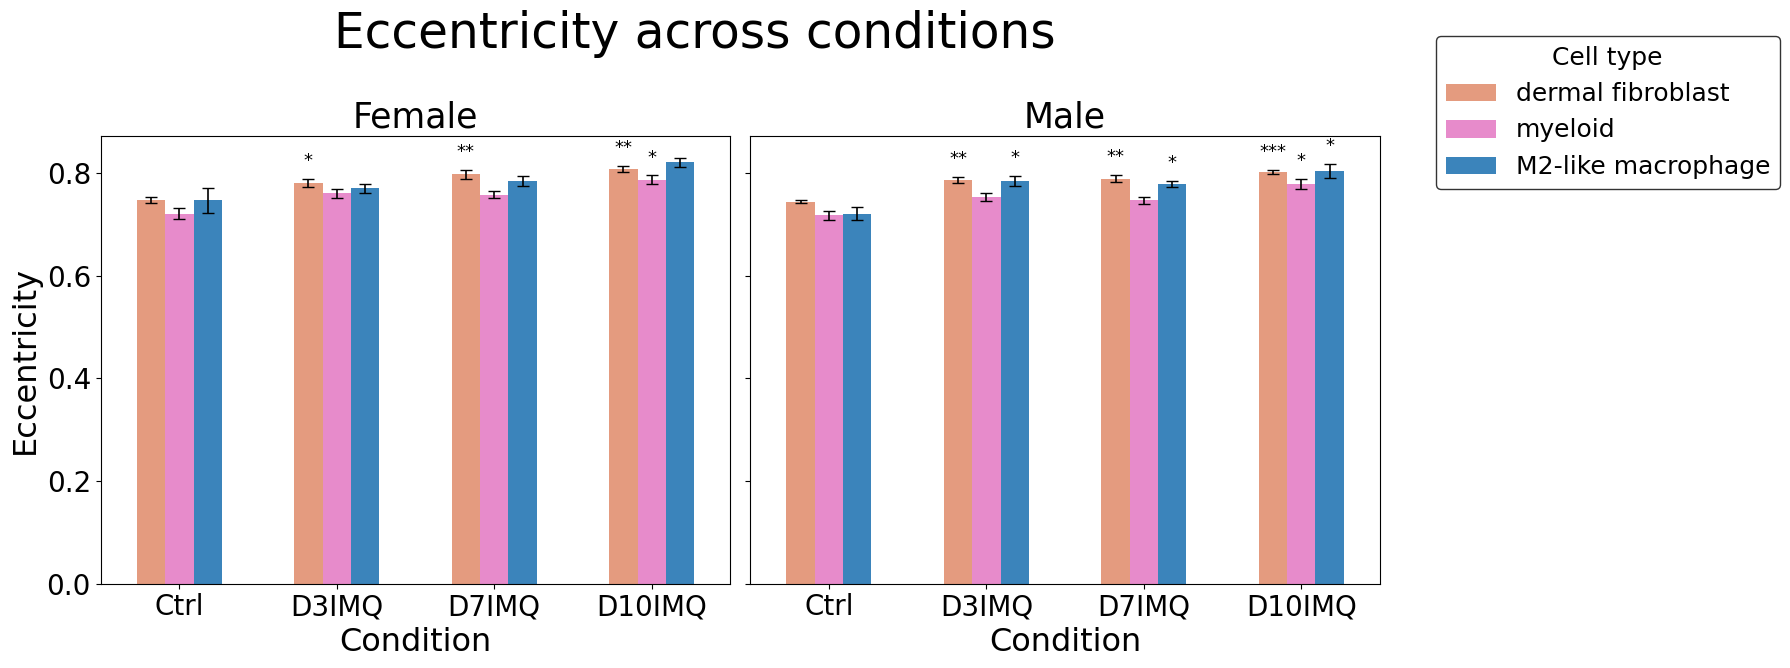

In [15]:
fig, ax = plot_property_over_condition_by_sex(
    adata,
    celltypes = ['dermal_fibroblast', 'myeloid', 'M2-like_macrophage'],
    property_name = 'eccentricity',
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
    sex_order=("F", "M"),
    figsize=(14, 6.5),
    bar_width=0.18,
    capsize=4,
)
plt.savefig(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\morph_props figures\stromal_eccentricity.png", dpi = 500, bbox_inches = 'tight')

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_38300\2031889676.py:134: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):


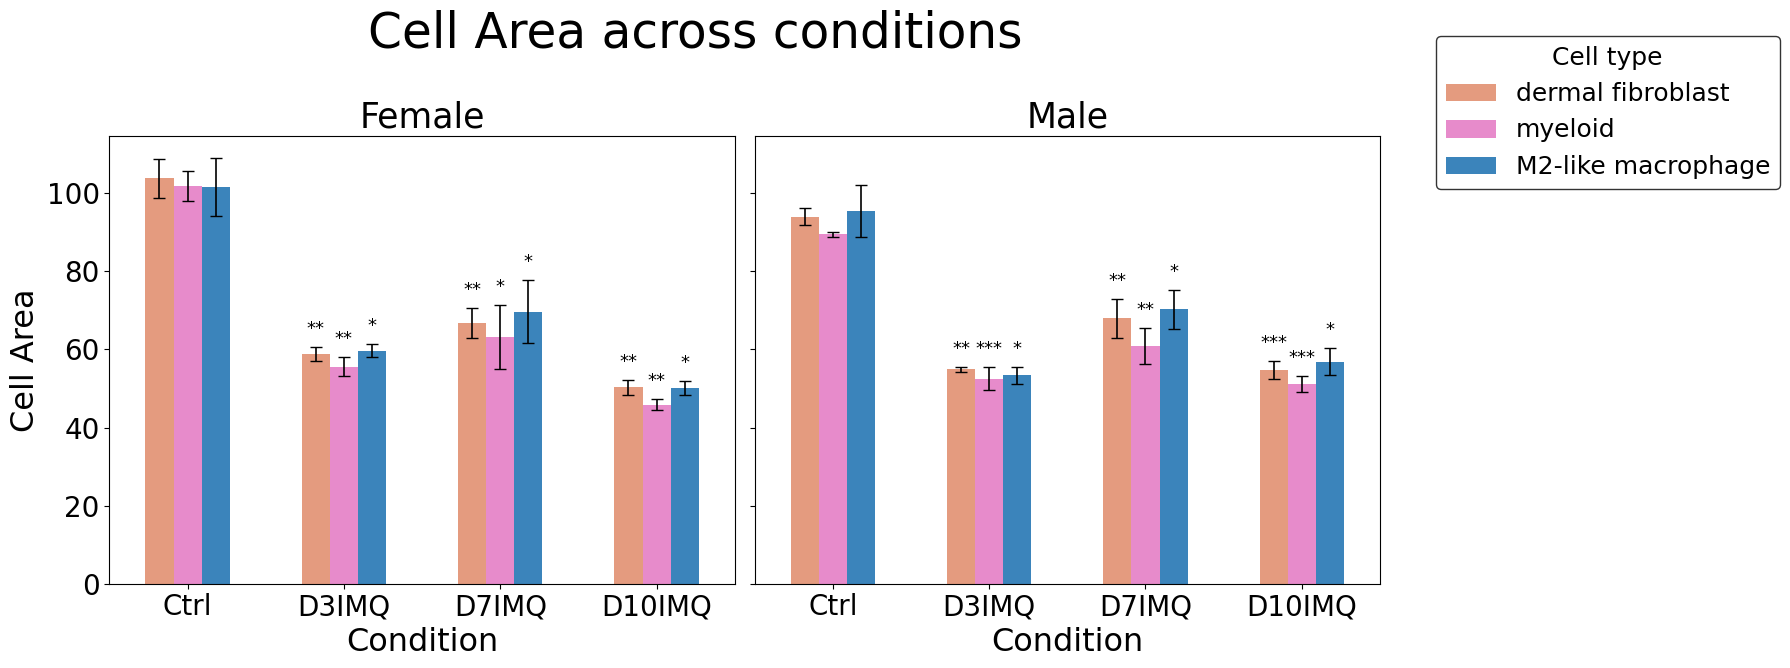

In [17]:
plot_property_over_condition_by_sex(
    adata,
    celltypes = ['dermal_fibroblast', 'myeloid', 'M2-like_macrophage'],
    property_name = 'cell_area',
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
    sex_order=("F", "M"),
    figsize=(14, 6.5),
    bar_width=0.18,
    capsize=4,
)

plt.savefig(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\morph_props figures\stromal_cell_area.png", dpi = 500, bbox_inches = 'tight')

### compare different celltypes

In [38]:
#violin plot with stats (just a welch t-test between the replicate means at a given condition)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.stats import ttest_ind
from scipy.stats import gaussian_kde


def _asterisks(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"


def _half_violin(ax, data, x_centre, side, color, width=0.35, alpha=0.8):
    """
    Draw one half of a violin plot.
    side: 'left' (goes left of x_centre) or 'right' (goes right).
    Returns the y positions and kde values for reference.
    """
    data = np.asarray(data)
    data = data[~np.isnan(data)]
    if len(data) < 2:
        return

    kde = gaussian_kde(data, bw_method="scott")
    y_grid = np.linspace(data.min(), data.max(), 300)
    density = kde(y_grid)
    density = density / density.max() * width  # normalise to max half-width

    if side == "right":
        x_fill = np.concatenate([[x_centre], x_centre + density, [x_centre]])
    else:
        x_fill = np.concatenate([[x_centre], x_centre - density, [x_centre]])

    y_fill = np.concatenate([[y_grid[0]], y_grid, [y_grid[-1]]])

    ax.fill_betweenx(y_grid, x_centre, x_centre + density * (1 if side == "right" else -1),
                     color=color, alpha=alpha, linewidth=0)
    # outline
    ax.plot(x_centre + density * (1 if side == "right" else -1), y_grid,
            color=color, linewidth=0.8, alpha=1.0)
    ax.axvline(x_centre, ymin=0, ymax=1, color="grey", linewidth=0.5,
               linestyle="--", zorder=1)

    # median line
    median = np.median(data)
    ax.hlines(median, x_centre - (width * 0.3 if side == "left" else 0),
              x_centre + (width * 0.3 if side == "right" else 0),
              colors="white", linewidth=1.5, zorder=3)


def plot_split_violin_by_condition(
    adata,
    celltypes,
    property_name,
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
    sex_order=("F", "M"),
    figsize=(14, 5),
    violin_width=0.35,
    alpha=0.8,
):
    """
    For exactly two cell types, plot split violins at each condition,
    split into subplots by sex. Left half = celltypes[0], right = celltypes[1].
    Welch's t-test on per-replicate means; asterisk above each violin pair.
    p-values listed in a side legend.
    """
    if len(celltypes) != 2:
        raise ValueError("Exactly two cell types must be provided.")
    if property_name not in adata.obs.columns:
        raise KeyError(f"'{property_name}' not found in adata.obs")

    ct_a, ct_b = celltypes

    df = adata.obs[[celltype_col, property_name, batch_col]].copy()
    df = df[df[celltype_col].isin(celltypes)].copy()

    split_df = df[batch_col].astype(str).str.split("_", n=1, expand=True)
    df["condition"] = split_df[0]
    df["sex"] = split_df[1].str[0]

    df = df[df["condition"].isin(condition_order)].copy()
    df = df[df["sex"].isin(sex_order)].copy()

    # Per-replicate means (used for the t-test)
    replicate_means = (
        df.groupby([celltype_col, "condition", "sex", batch_col], observed=True)[property_name]
        .mean()
        .reset_index(name="replicate_mean")
    )

    # Build color map
    if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):
        categories = list(adata.obs[celltype_col].cat.categories)
    else:
        categories = list(pd.unique(adata.obs[celltype_col].astype(str)))
    colors = adata.uns[f"{celltype_col}_colors"]
    color_map = dict(zip(categories, colors))

    color_a = color_map.get(ct_a, "steelblue")
    color_b = color_map.get(ct_b, "tomato")

    sex_titles = {"F": "Female", "M": "Male"}
    n_conditions = len(condition_order)
    x_positions = np.arange(n_conditions)

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # Store p-values for the side legend: {sex: [(condition, stars, p), ...]}
    pval_records = {sex: [] for sex in sex_order}

    for ax, sex in zip(axes, sex_order):
        for j, cond in enumerate(condition_order):
            x = x_positions[j]

            # Raw cell values for violin shape (all cells in this condition/sex)
            vals_a = df[
                (df[celltype_col] == ct_a) &
                (df["condition"] == cond) &
                (df["sex"] == sex)
            ][property_name].dropna().values

            vals_b = df[
                (df[celltype_col] == ct_b) &
                (df["condition"] == cond) &
                (df["sex"] == sex)
            ][property_name].dropna().values

            if len(vals_a) >= 2:
                _half_violin(ax, vals_a, x, "left", color_a, width=violin_width, alpha=alpha)
            if len(vals_b) >= 2:
                _half_violin(ax, vals_b, x, "right", color_b, width=violin_width, alpha=alpha)

            # T-test on per-replicate means
            rep_a = replicate_means[
                (replicate_means[celltype_col] == ct_a) &
                (replicate_means["condition"] == cond) &
                (replicate_means["sex"] == sex)
            ]["replicate_mean"].dropna().values

            rep_b = replicate_means[
                (replicate_means[celltype_col] == ct_b) &
                (replicate_means["condition"] == cond) &
                (replicate_means["sex"] == sex)
            ]["replicate_mean"].dropna().values

            if len(rep_a) >= 2 and len(rep_b) >= 2:
                _, p = ttest_ind(rep_a, rep_b, equal_var=False)
                stars = _asterisks(p)
                pval_records[sex].append((cond, stars, p))

                # Annotate asterisk above the violin pair
                y_max = max(
                    vals_a.max() if len(vals_a) else 0,
                    vals_b.max() if len(vals_b) else 0,
                )
                ax.text(x, y_max * 1.02, stars, ha="center", va="bottom",
                        fontsize=10, fontweight="bold", color="black", zorder=5)
            else:
                pval_records[sex].append((cond, "n/a", np.nan))

        ax.set_xticks(x_positions)
        ax.set_xticklabels(condition_order)
        ax.set_xlabel("Condition")
        ax.set_title(sex_titles.get(sex, sex))
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlim(-0.6, n_conditions - 0.4)

    axes[0].set_ylabel(property_name.replace("_", " ").title())

    # --- Side legend: celltype colours + p-value table ---
    legend_lines = []

    # Celltype colour patches
    from matplotlib.patches import Patch
    legend_lines.append(Patch(facecolor=color_a, label=ct_a.replace("_", " ")))
    legend_lines.append(Patch(facecolor=color_b, label=ct_b.replace("_", " ")))

    # Blank spacer
    legend_lines.append(Patch(facecolor="none", label=" ", linewidth=0))

    # P-value entries per sex
    for sex in sex_order:
        legend_lines.append(Patch(facecolor="none", label=f"── {sex_titles.get(sex, sex)} ──",
                                  linewidth=0))
        for cond, stars, p in pval_records[sex]:
            p_str = f"{p:.3f}" if not np.isnan(p) else "n/a"
            legend_lines.append(
                Patch(facecolor="none", linewidth=0,
                      label=f"{cond}: {stars}  (p={p_str})")
            )

    fig.legend(
        handles=legend_lines,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        fontsize=9,
        handlelength=1.2,
        handleheight=1.0,
    )

    fig.suptitle(
        f"{property_name.replace('_', ' ').title()}:  "
        f"{ct_a.replace('_', ' ')}  vs  {ct_b.replace('_', ' ')}",
        y=1.02,
    )
    fig.tight_layout()
    return fig, axes

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_31736\129808869.py:101: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):


(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Female'}, xlabel='Condition', ylabel='Perimeter'>,
        <Axes: title={'center': 'Male'}, xlabel='Condition'>], dtype=object))

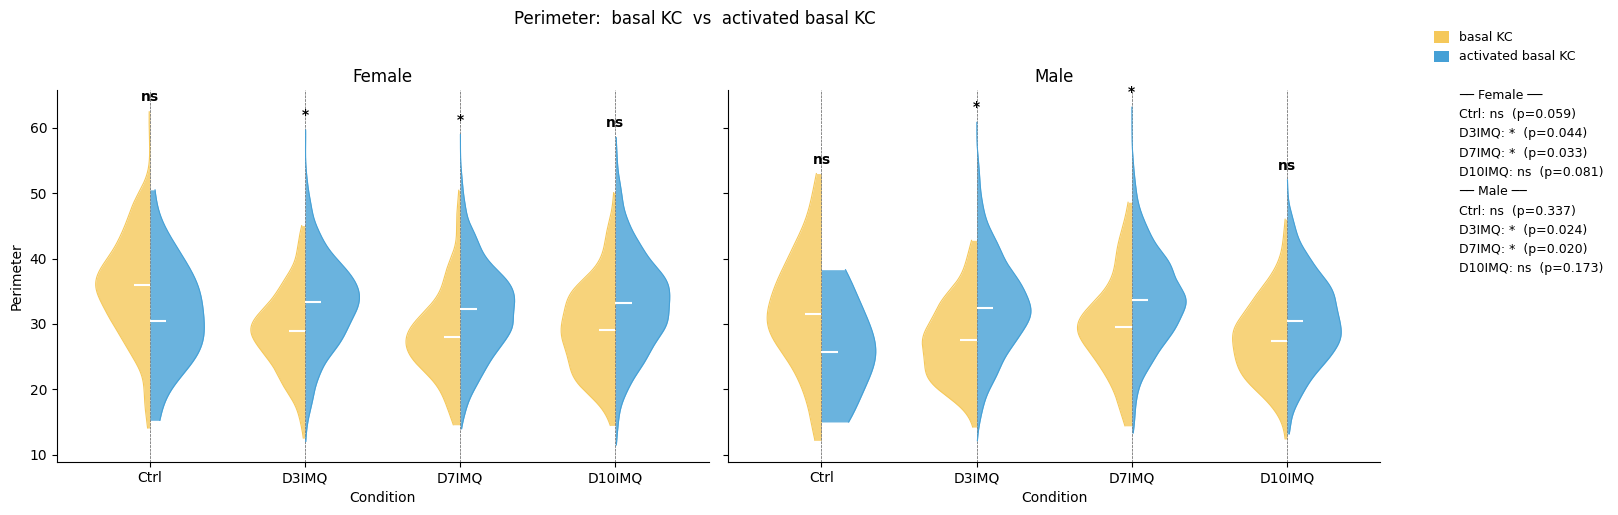

In [45]:
plot_split_violin_by_condition(
    adata,
    celltypes = ['basal_KC', 'activated_basal_KC'],
    property_name = 'perimeter',
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
    sex_order=("F", "M"),
    figsize=(14, 5),
    violin_width=0.35,
    alpha=0.8,
)

#plt.savefig(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\morph_props figures\stromal_cell_area.png", dpi = 500, bbox_inches = 'tight')

## Individual celltype boxplot with stats

In [19]:
#single celltype with stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests


def plot_single_cell_property_boxplot_by_sex(
    adata,
    celltype,
    property_name,
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
    sex_order=("F", "M"),
    figsize=(12, 5),
    reference_condition="Ctrl",
    box_width=0.45,
    capsize=4,
):
    """
    For a single cell type, plot replicate-mean box-and-whisker plots across
    conditions (Female / Male subplots), with Benjamini-Hochberg-corrected
    two-sample t-tests comparing each condition to the reference.

    Parameters
    ----------
    adata            : AnnData
    celltype         : str   — single cell type to plot
    property_name    : str   — .obs column to summarise
    celltype_col     : str
    batch_col        : str   — e.g. 'Ctrl_F2'
    condition_order  : sequence
    sex_order        : sequence (exactly two)
    reference_condition : str — condition to test against (default 'Ctrl')
    box_width        : float
    """

    # ── Validation ────────────────────────────────────────────────────────────
    for col in (property_name, celltype_col, batch_col):
        if col not in adata.obs.columns:
            raise KeyError(f"'{col}' not found in adata.obs")
    if len(sex_order) != 2:
        raise ValueError("sex_order must contain exactly two values")

    # ── Subset & parse ────────────────────────────────────────────────────────
    df = adata.obs[[celltype_col, property_name, batch_col]].copy()
    df = df[df[celltype_col] == celltype].copy()
    if df.empty:
        raise ValueError(f"No rows found for cell type '{celltype}'")

    split_df    = df[batch_col].astype(str).str.split("_", n=1, expand=True)
    df["condition"]  = split_df[0]
    sex_rep          = split_df[1]
    df["sex"]        = sex_rep.str[0]
    df["replicate"]  = sex_rep.str[1:]

    df = df[df["condition"].isin(condition_order) & df["sex"].isin(sex_order)].copy()

    # ── Replicate means (unit of observation for the plot & stats) ────────────
    rep_means = (
        df.groupby([celltype_col, "condition", "sex", batch_col], observed=True)[property_name]
        .mean()
        .reset_index(name="replicate_mean")
    )

    # ── Colour ────────────────────────────────────────────────────────────────
    if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):
        categories = list(adata.obs[celltype_col].cat.categories)
    else:
        categories = list(pd.unique(adata.obs[celltype_col].astype(str)))
    color_map = dict(zip(categories, adata.uns[f"{celltype_col}_colors"]))
    color = color_map.get(celltype, "steelblue")

    # ── Significance helper ───────────────────────────────────────────────────
    def significance_label(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "ns"

    # ── Plot ──────────────────────────────────────────────────────────────────
    sex_titles = {"F": "Female", "M": "Male"}
    fig, axes  = plt.subplots(1, 2, figsize=figsize, sharey=True)

    for ax, sex in zip(axes, sex_order):

        # Gather data per condition
        groups = {}
        for cond in condition_order:
            vals = rep_means.loc[
                (rep_means["sex"] == sex) & (rep_means["condition"] == cond),
                "replicate_mean"
            ].dropna().values
            if len(vals) > 0:
                groups[cond] = vals

        if not groups:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_title(sex_titles.get(sex, sex))
            continue

        x_positions = {cond: i for i, cond in enumerate(condition_order) if cond in groups}

        # ── Box plots ─────────────────────────────────────────────────────────
        bp = ax.boxplot(
            [groups[c] for c in x_positions],
            positions=list(x_positions.values()),
            widths=box_width,
            patch_artist=True,
            notch=False,
            showfliers=False,       # hide individual outlier points
            medianprops=dict(color="black", linewidth=1.8),
            boxprops=dict(facecolor=color, alpha=0.6, linewidth=1.2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
        )

        # ── BH-corrected t-tests vs reference ─────────────────────────────────
        ref_vals  = groups.get(reference_condition)
        comparisons = [c for c in condition_order
                       if c != reference_condition and c in groups]

        if ref_vals is not None and len(ref_vals) >= 2 and comparisons:
            raw_p = []
            valid_comparisons = []
            for cond in comparisons:
                cond_vals = groups[cond]
                if len(cond_vals) >= 2:
                    _, p = stats.ttest_ind(ref_vals, cond_vals, equal_var=False)
                    raw_p.append(p)
                    valid_comparisons.append(cond)

            if raw_p:
                _, corrected_p, _, _ = multipletests(raw_p, method="fdr_bh")

                # ── Draw significance braces ───────────────────────────────────
                y_data_max = max(
                    np.max(v) for v in groups.values()
                )
                y_range    = y_data_max - ax.get_ylim()[0]
                brace_step = y_range * 0.13   # vertical gap between stacked braces
                brace_base = y_data_max + y_range * 0.08

                ref_x = x_positions[reference_condition]

                for j, (cond, p_corr) in enumerate(zip(valid_comparisons, corrected_p)):
                    cond_x  = x_positions[cond]
                    y_brace = brace_base + j * brace_step

                    # Horizontal line spanning the two bars
                    ax.plot([ref_x, cond_x], [y_brace, y_brace],
                            color="black", linewidth=1.0)
                    # Vertical ticks at each end
                    tick_h = brace_step * 0.18
                    ax.plot([ref_x, ref_x],   [y_brace - tick_h, y_brace],
                            color="black", linewidth=1.0)
                    ax.plot([cond_x, cond_x], [y_brace - tick_h, y_brace],
                            color="black", linewidth=1.0)
                    # Label
                    if p_corr < 0.001:
                        p_text = f"p < 0.001"
                    elif p_corr >= 0.05:
                        p_text = f"p = {p_corr:.3f} (ns)" # optional: keeps 'ns' for clarity
                    else:
                        asterisk = significance_label(p_corr)
                        p_text = f"p = {p_corr:.3f}{asterisk}"

                    ax.text(
                        (ref_x + cond_x) / 2, 
                        y_brace + brace_step * 0.08,
                        p_text,
                        ha="center", 
                        va="bottom", 
                        fontsize=9  # Slightly smaller font so long text strings fit
                    )

                # Extend y-axis to accommodate braces
                n_braces   = len(valid_comparisons)
                new_y_top  = brace_base + n_braces * brace_step + brace_step * 0.4
                ax.set_ylim(top=new_y_top)

        ax.set_xticks(list(x_positions.values()))
        ax.set_xticklabels(list(x_positions.keys()))
        ax.set_xlabel("Condition")
        ax.set_title(sex_titles.get(sex, sex), fontsize=13)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel(property_name.replace("_", " ").title(), fontsize=12)
    fig.suptitle(
        f"{property_name.replace('_', ' ').title()}  —  {celltype.replace('_', ' ')}",
        #f"(box = replicate means | Welch's t-test, BH corrected)",
        fontsize=13, y=1.02
    )
    fig.tight_layout()
    return fig, axes

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32696\2030235986.py:69: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32696\2030235986.py:69: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32696\2030235986.py:69: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):


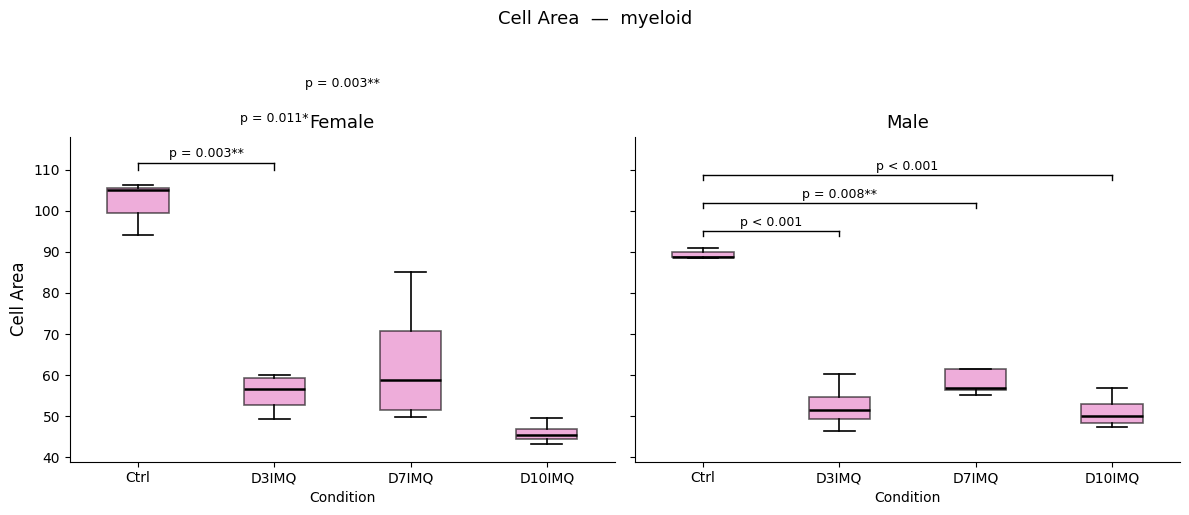

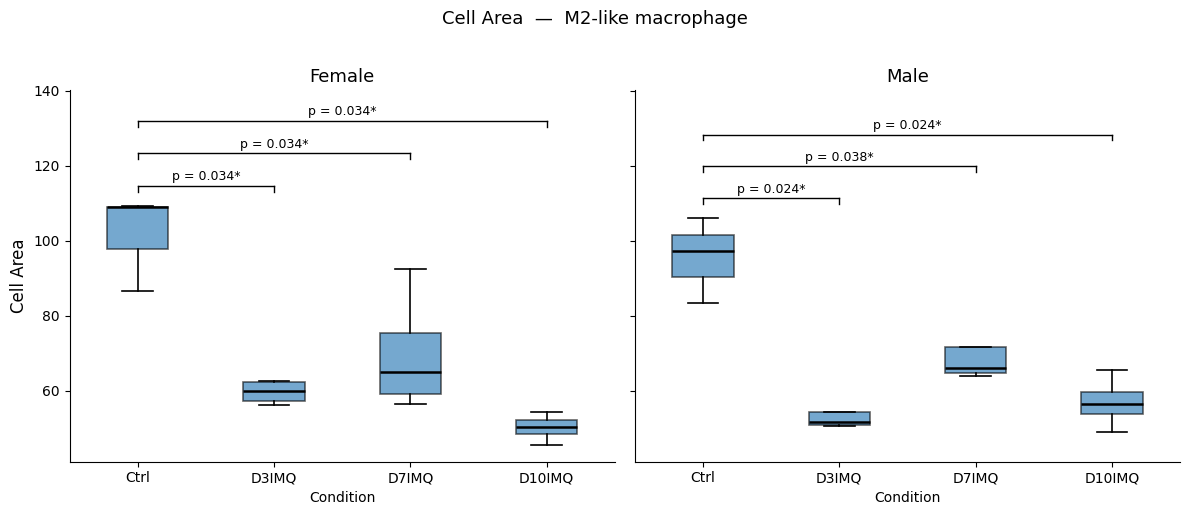

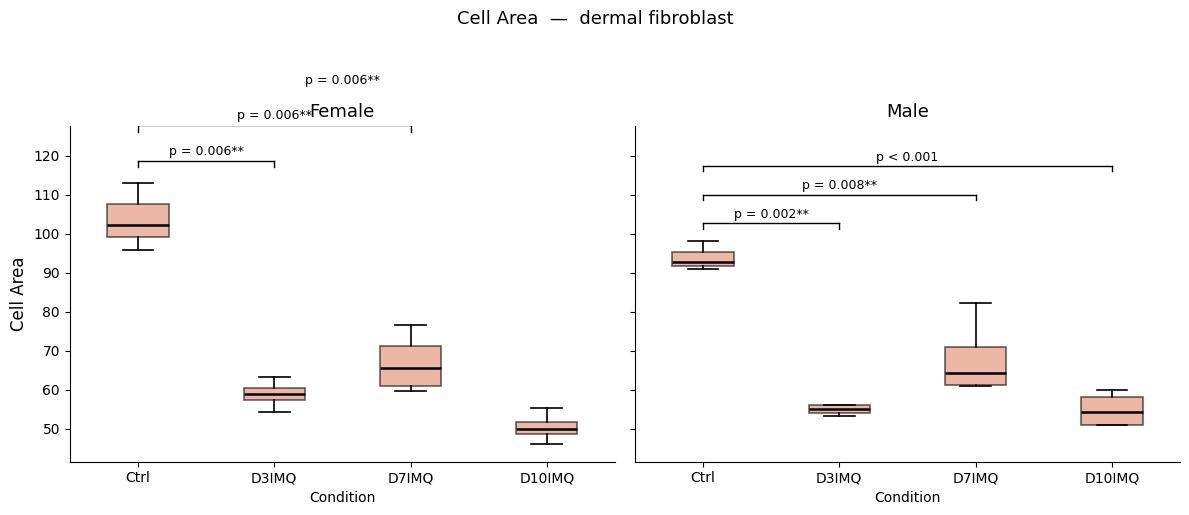

In [30]:
for cell in ['myeloid', 'M2-like_macrophage', 'dermal_fibroblast']:
    plot_single_cell_property_boxplot_by_sex(
        adata,
        celltype = cell,
        property_name = 'cell_area',
        celltype_col="celltype_assignments",
        batch_col="batch_key",
        condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
        sex_order=("F", "M"),
        figsize=(12, 5),
        reference_condition="Ctrl",
        box_width=0.45,
        capsize=4,
    )

## KC morphology

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32724\1533197153.py:77: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):


(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Female'}, xlabel='Condition', ylabel='Cell Area'>,
        <Axes: title={'center': 'Male'}, xlabel='Condition'>], dtype=object))

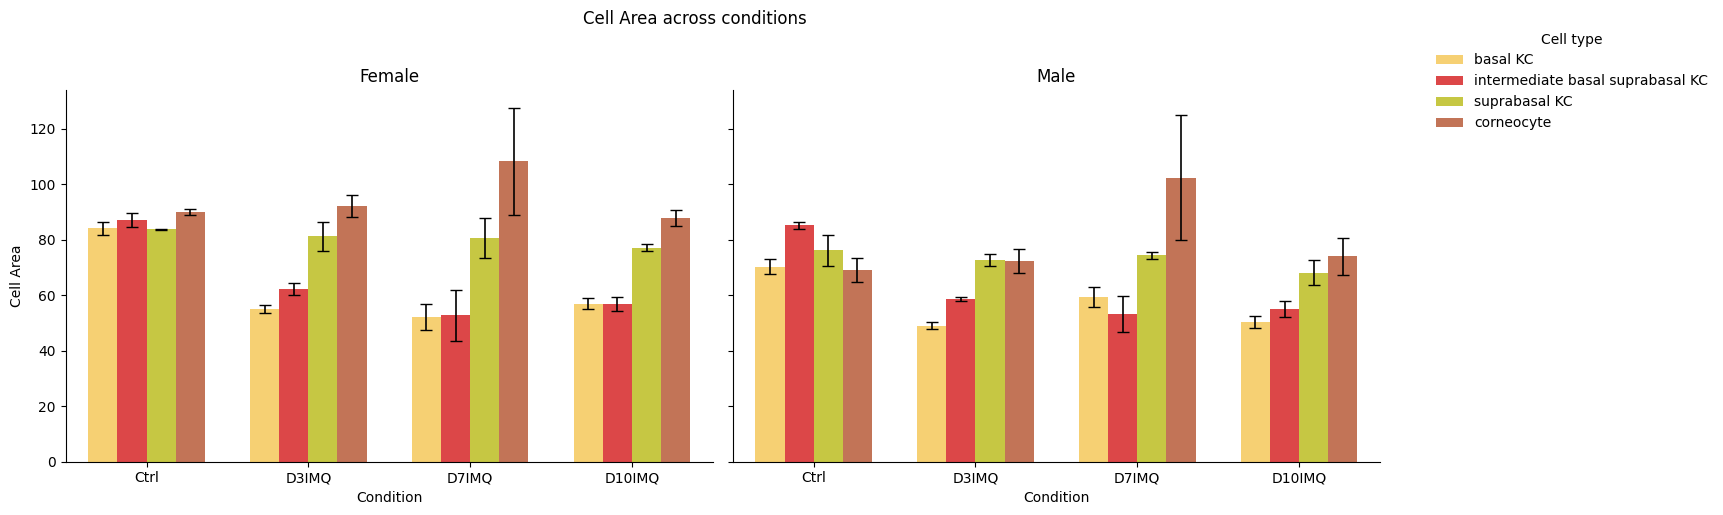

In [18]:
celltypes = ['basal_KC', 'intermediate_basal_suprabasal_KC', 'suprabasal_KC', 'corneocyte']
condition_order = ('Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ')

plot_property_over_condition_by_sex(
    adata,
    celltypes = celltypes,
    property_name = 'cell_area',
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=condition_order,
    sex_order=("F", "M"),
    figsize=(14, 5),
    bar_width=0.18,
    capsize=4,
)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32724\1533197153.py:77: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):


(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Female'}, xlabel='Condition', ylabel='Cell Area'>,
        <Axes: title={'center': 'Male'}, xlabel='Condition'>], dtype=object))

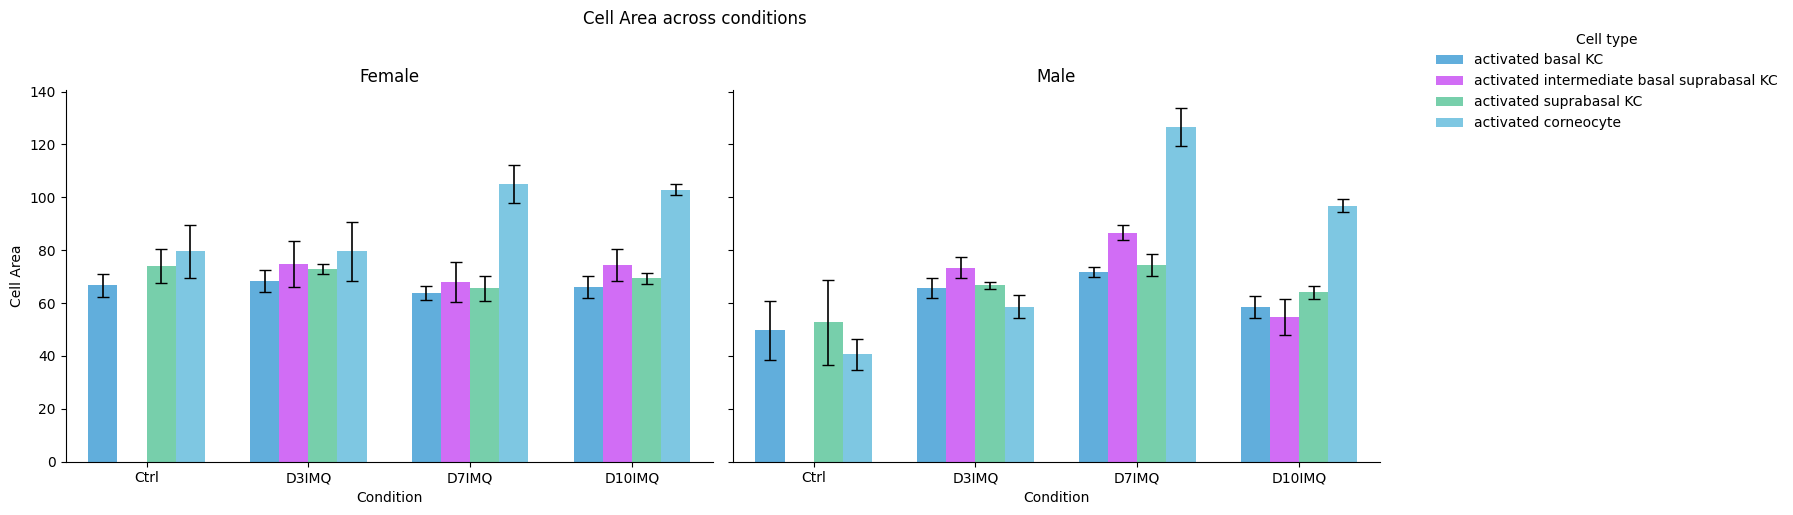

In [15]:
celltypes = ['activated_basal_KC', 'activated_intermediate_basal_suprabasal_KC', 'activated_suprabasal_KC', 'activated_corneocyte']
condition_order = ('Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ')

plot_property_over_condition_by_sex(
    adata,
    celltypes = celltypes,
    property_name = 'cell_area',
    celltype_col="celltype_assignments",
    batch_col="batch_key",
    condition_order=condition_order,
    sex_order=("F", "M"),
    figsize=(14, 5),
    bar_width=0.18,
    capsize=4,
)

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32724\2030235986.py:69: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32724\2030235986.py:69: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32724\2030235986.py:69: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32724\2030235986.py:69: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a futu

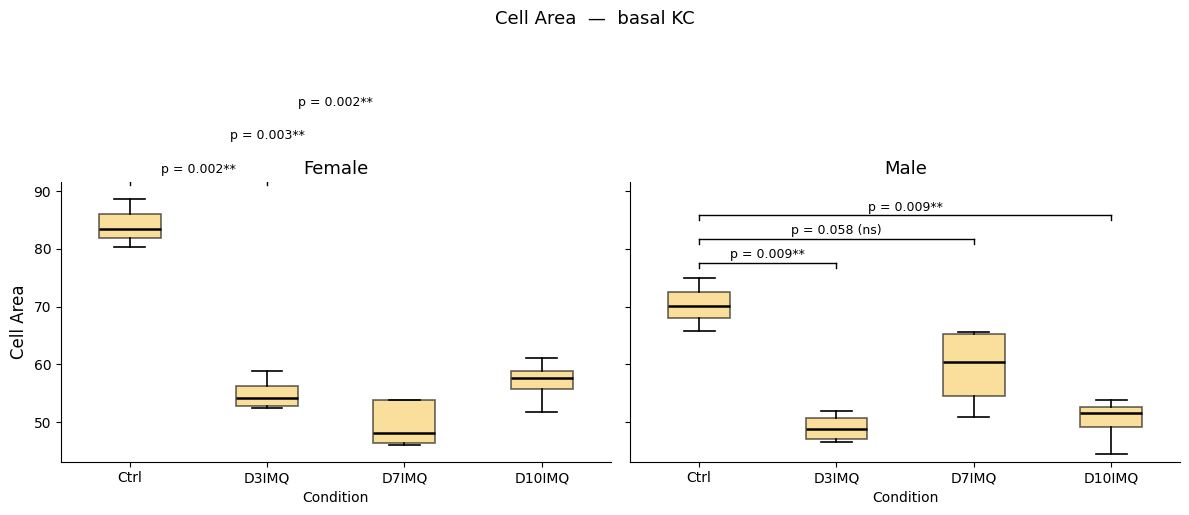

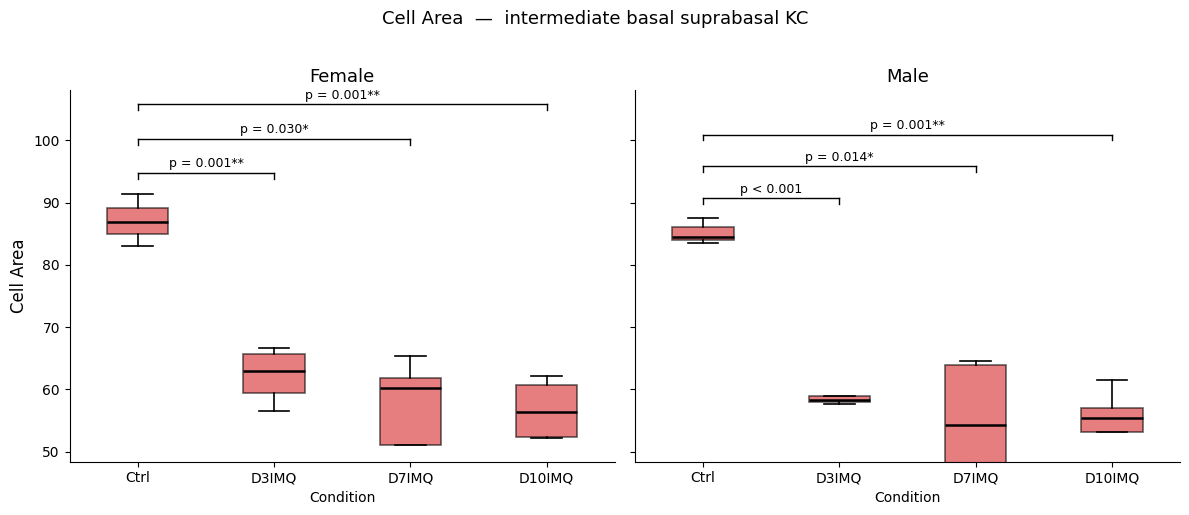

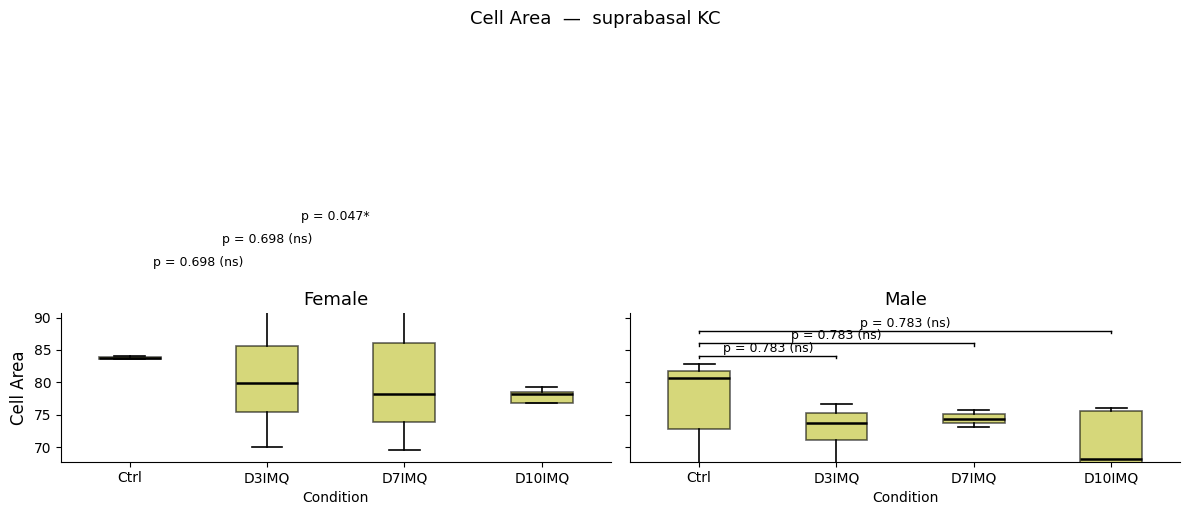

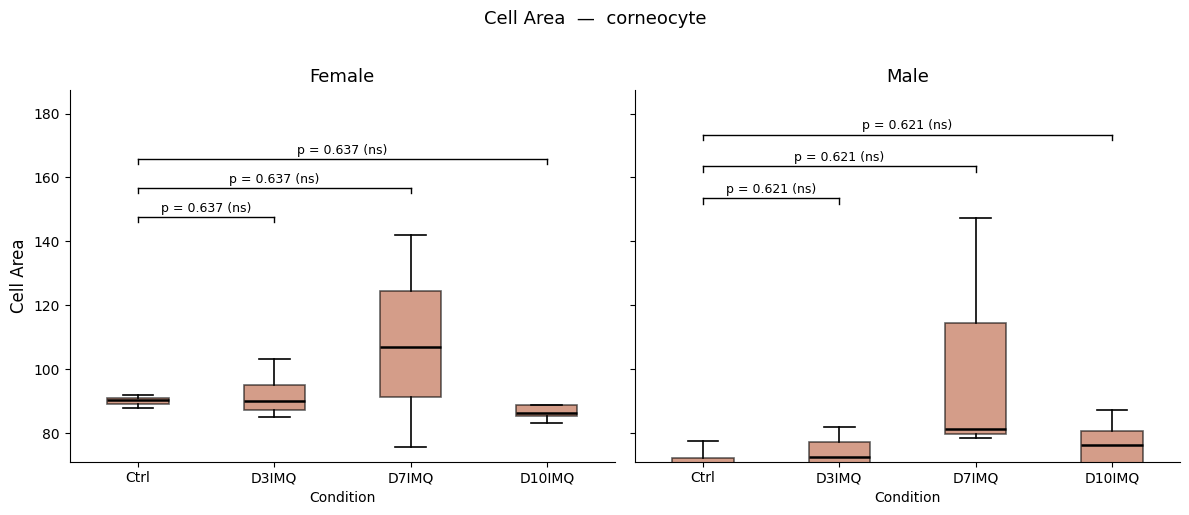

In [21]:
for cell in ['basal_KC', 'intermediate_basal_suprabasal_KC', 'suprabasal_KC', 'corneocyte']:
    plot_single_cell_property_boxplot_by_sex(
        adata,
        celltype = cell,
        property_name = 'cell_area',
        celltype_col="celltype_assignments",
        batch_col="batch_key",
        condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
        sex_order=("F", "M"),
        figsize=(12, 5),
        reference_condition="Ctrl",
        box_width=0.45,
        capsize=4,
    )

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32724\2030235986.py:69: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32724\2030235986.py:69: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32724\2030235986.py:69: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[celltype_col]):
C:\Users\dbuxton\AppData\Local\Temp\ipykernel_32724\2030235986.py:69: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a futu

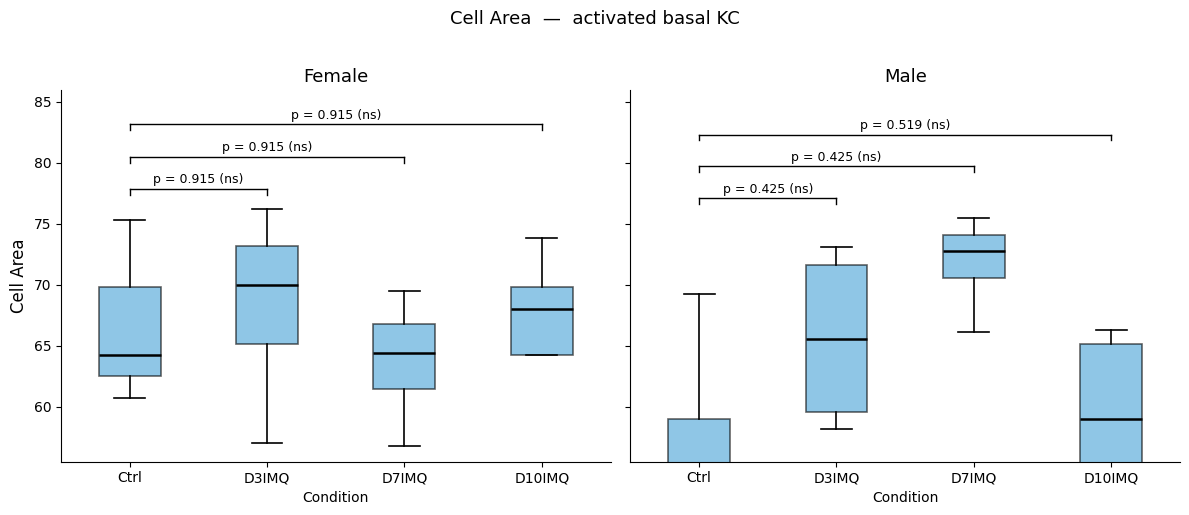

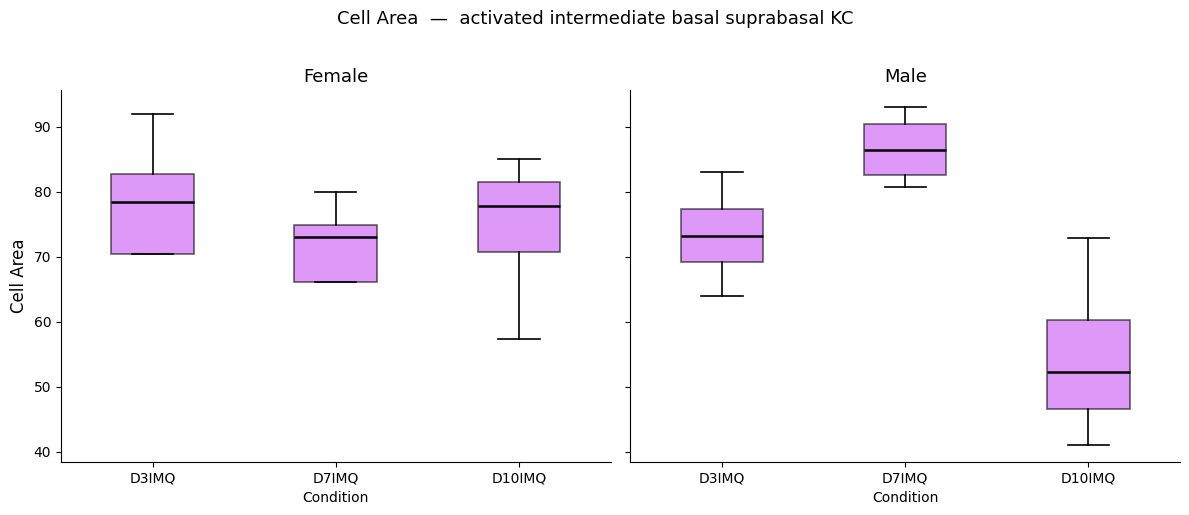

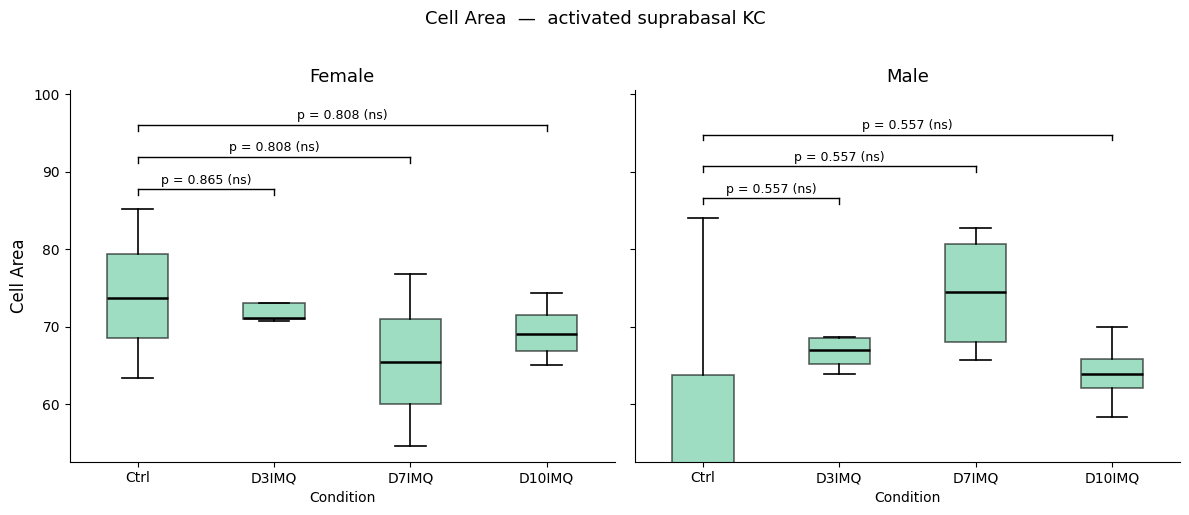

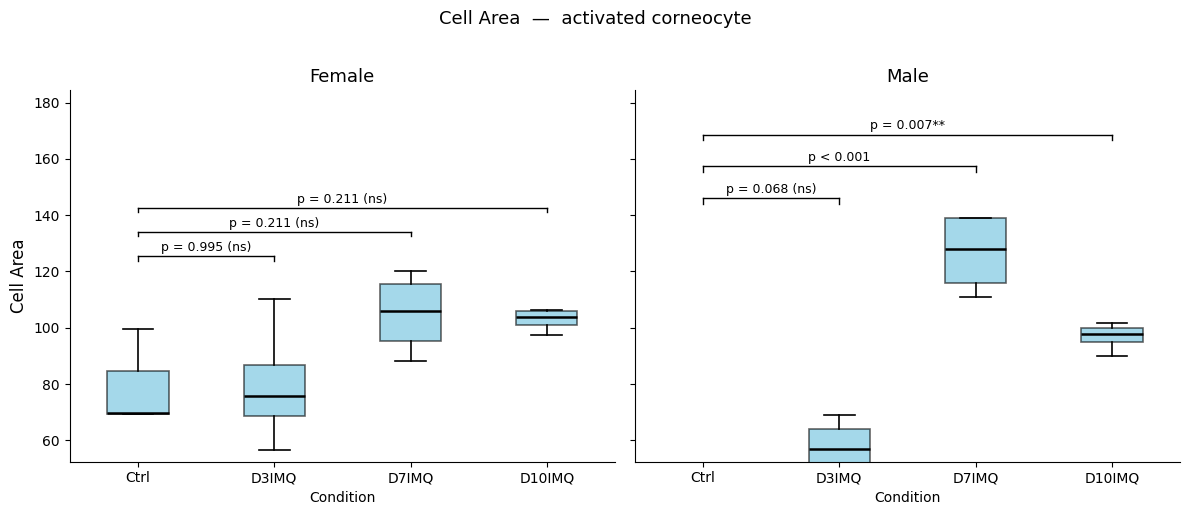

In [22]:
for cell in ['activated_basal_KC', 'activated_intermediate_basal_suprabasal_KC', 'activated_suprabasal_KC', 'activated_corneocyte']:
    plot_single_cell_property_boxplot_by_sex(
        adata,
        celltype = cell,
        property_name = 'cell_area',
        celltype_col="celltype_assignments",
        batch_col="batch_key",
        condition_order=("Ctrl", "D3IMQ", "D7IMQ", "D10IMQ"),
        sex_order=("F", "M"),
        figsize=(12, 5),
        reference_condition="Ctrl",
        box_width=0.45,
        capsize=4,
    )

# MuSpAn for wPCF

In [1]:
#making MuSpAn domains
import muspan as ms
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
adata = adata[adata.obs['compartment'].str.contains('orsal')]

replicates = {}
for rep in adata.obs.batch_key.unique():
    replicates[rep] = adata[adata.obs.batch_key == rep].copy()

In [2]:

#DEFINE PROPERTY FOR wPCF
morph_prop = 'eccentricity'

In [3]:
#dictionary of domains
rep_domains = {}
for name, rep in replicates.items():
    rep_domains[name] = ms.domain(f'{name}')

#add points, these will be in um if taken from xenium data
for name, domain in rep_domains.items():
    points = replicates[name].obsm['spatial']
    domain.add_points(points, 'cells')


#add cell labels
for name, domain in rep_domains.items():
    labels = replicates[name].obs.celltype_assignments.to_numpy()
    domain.add_labels('celltype_assignments', labels)

#add morphological labels
for name, domain in rep_domains.items():
    morph_labels = replicates[name].obs[morph_prop].to_numpy()
    domain.add_labels(morph_prop, labels = morph_labels)

#estimate boundary using alphashape -- could also use compartment segmentations, similar results, given they are both defined by cell existence. 
for domain in rep_domains.values():
    domain.estimate_boundary(method = 'alpha shape',
                             alpha_shape_kwargs = {'alpha': 150})

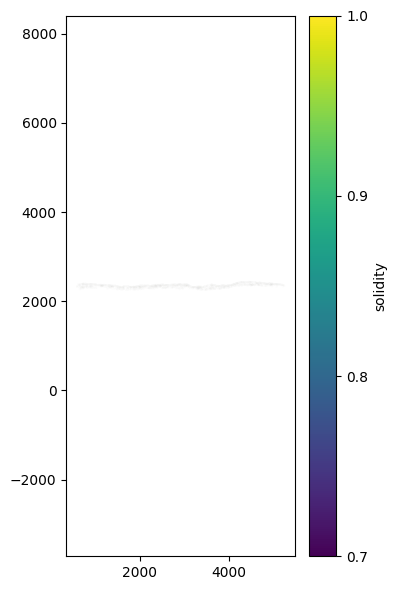

In [ ]:
#visualisation sense check
for name, domain in sorted(rep_domains.items()):
    ms.visualise.visualise(domain, color_by=morph_prop,figure_kwargs={'figsize': (4, 6)})
    
    break

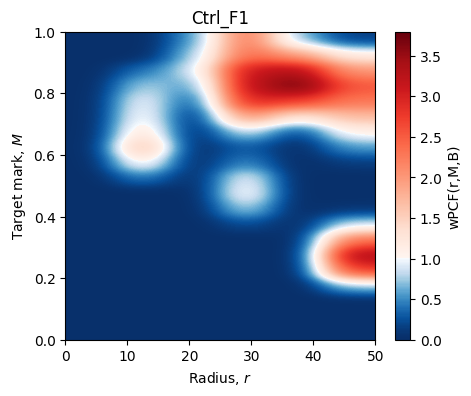

In [18]:
for name, domain in sorted(rep_domains.items()):
    cellA = ms.query.query(domain, ('celltype_assignments'), 'is', 'activated_basal_KC')
    cellB = ms.query.query(domain, ('celltype_assignments'), 'is', 'myeloid')

    radii, wPCF = ms.spatial_statistics.weighted_pair_correlation_function(
    domain, cellA, cellB, mark_pop_B=morph_prop, max_R=50, annulus_step=10, annulus_width=10
    )       

    # Visualize the weighted pair correlation function (wPCF)
    fig, ax = ms.visualise.visualise_wpcf(radii, wPCF, figure_kwargs={'figsize': (5, 4)})

    ax.set_title(name)

    # Plot the expected value of the target mark M (M = r^2) as a function of r
    #plt.gca().plot(np.arange(0, 1, 0.01), np.arange(0, 1, 0.01) ** 2, color=[0, 0, 0], linestyle=':', lw=5)
    break
    

### Averaging wPCF

----------------------------------------


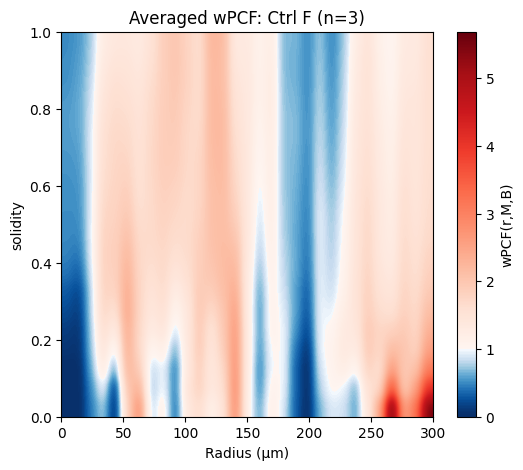

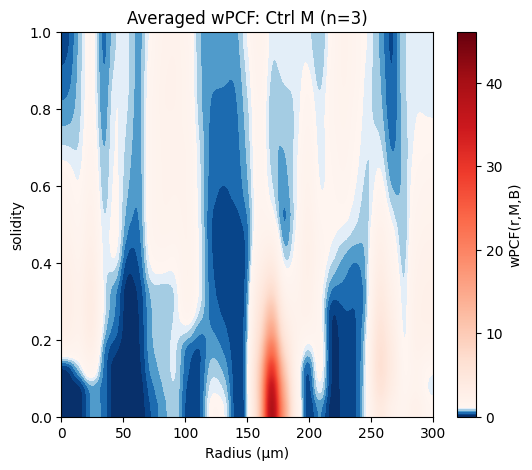

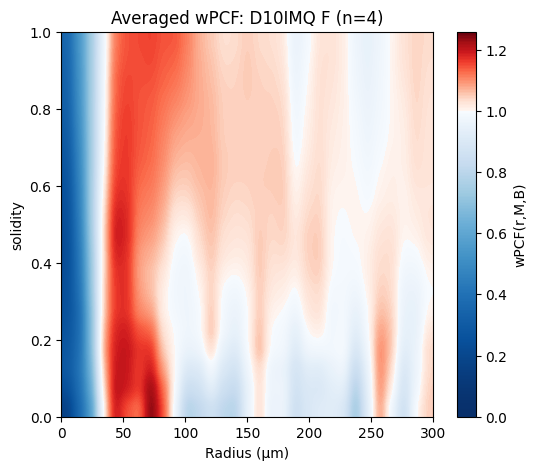

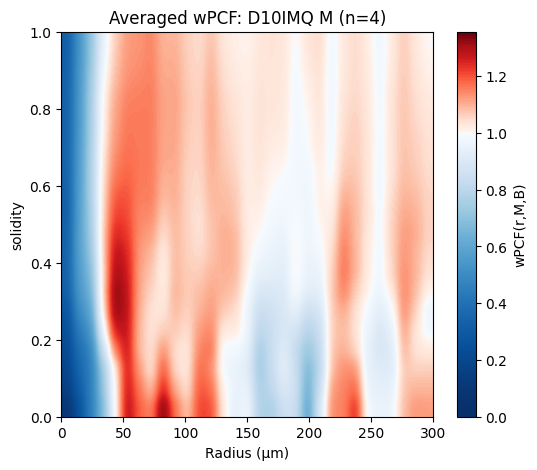

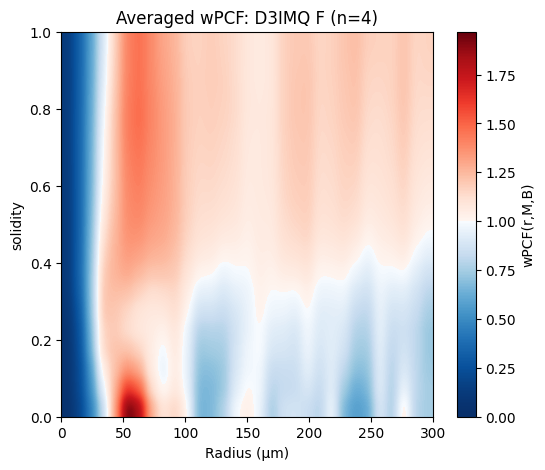

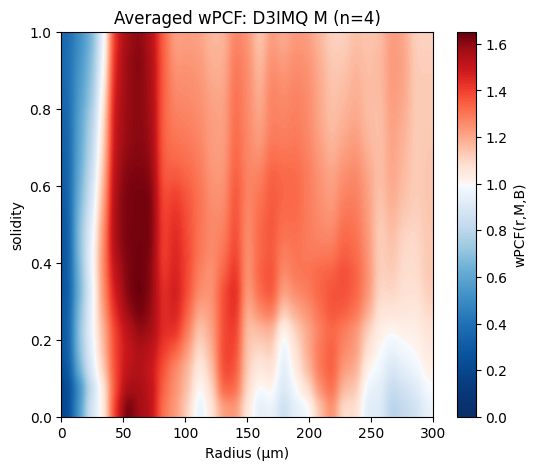

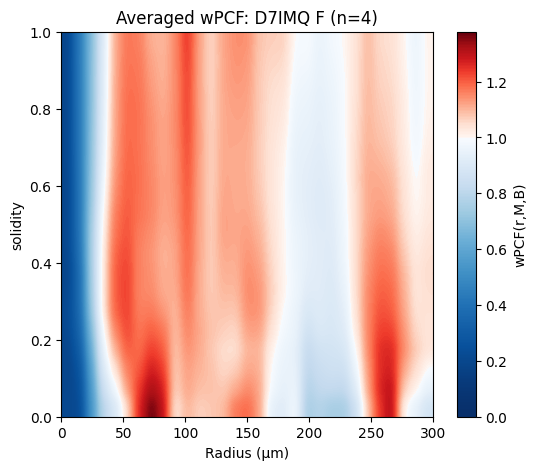

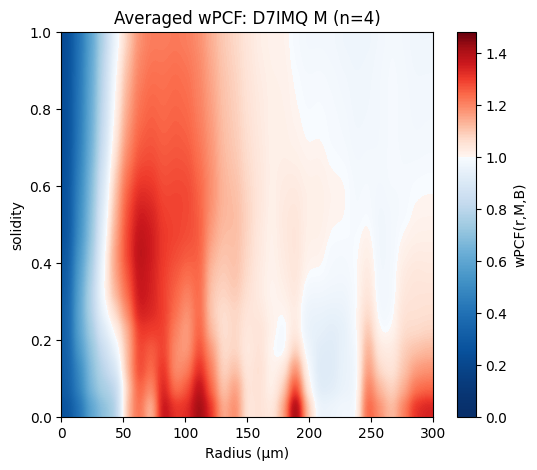

In [39]:
import numpy as np
import re
import matplotlib.pyplot as plt

"""GLOBAL_AREA_MIN = 0     
GLOBAL_AREA_MAX = 300 
GLOBAL_AREA_STEP = 25   """ #only use if trying to get area to work

grouped_wpcfs = {}
shared_radii = None

for name, domain in sorted(rep_domains.items()):
    
    match = re.match(r"^([A-Za-z0-9]+_[FM])", name)
    if not match:
        continue
        
    group_key = match.group(1) 
    
    if group_key not in grouped_wpcfs:
        grouped_wpcfs[group_key] = []

    cellA = ms.query.query(domain, ('celltype_assignments'), 'is', 'activated_basal_KC')
    cellB = ms.query.query(domain, ('celltype_assignments'), 'is', 'myeloid')

    radii, wPCF = ms.spatial_statistics.weighted_pair_correlation_function(
        domain, cellA, cellB, 
        mark_pop_B=morph_prop, 
        max_R=300, 
        annulus_step=10, 
        annulus_width=15,
        # mark_min_pop_B=GLOBAL_AREA_MIN,   
        # mark_max_pop_B=GLOBAL_AREA_MAX,   
        # mark_step_pop_B=GLOBAL_AREA_STEP  
    )       
    
    
    # 2. Keep the longest radii array for the final visualization
    if shared_radii is None or len(radii) > len(shared_radii):
        shared_radii = radii

    grouped_wpcfs[group_key].append(wPCF)

print("-" * 40)

# 3. Average the arrays with NaN Padding
averaged_wpcfs = {}

for group_key, wpcf_list in grouped_wpcfs.items():
    
    # Find the maximum rows and columns for this group
    max_rows = max([arr.shape[0] for arr in wpcf_list])
    max_cols = max([arr.shape[1] for arr in wpcf_list])
    
    padded_list = []
    
    for arr in wpcf_list:
        # Calculate how much padding is needed for rows and cols
        pad_rows = max_rows - arr.shape[0]
        pad_cols = max_cols - arr.shape[1]
        
        # Pad the bottom and right edges with NaNs
        padded_arr = np.pad(
            arr, 
            ((0, pad_rows), (0, pad_cols)), 
            mode='constant', 
            constant_values=np.nan
        )
        padded_list.append(padded_arr)

    # Now all arrays in the list are the exact same shape, so this will work:
    avg_wpcf = np.nanmean(padded_list, axis=0)
    averaged_wpcfs[group_key] = avg_wpcf
    
    
    fig, ax = ms.visualise.visualise_wpcf(
        shared_radii, 
        avg_wpcf, 
        figure_kwargs={'figsize': (6, 5)}
    )


    ax.set_title(f"Averaged wPCF: {group_key.replace("_", " ")} (n={len(wpcf_list)})")
    ax.set_ylabel(f"{morph_prop.replace("_", " ")}")
    ax.set_xlabel("Radius (µm)")
    
    plt.show()

----------------------------------------


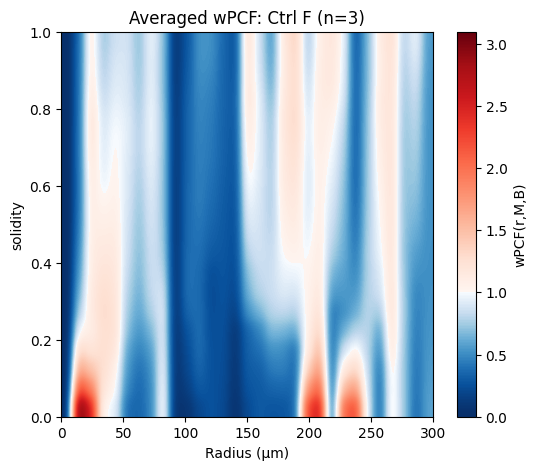

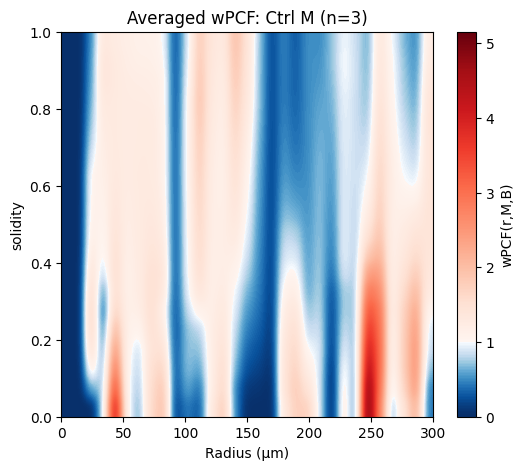

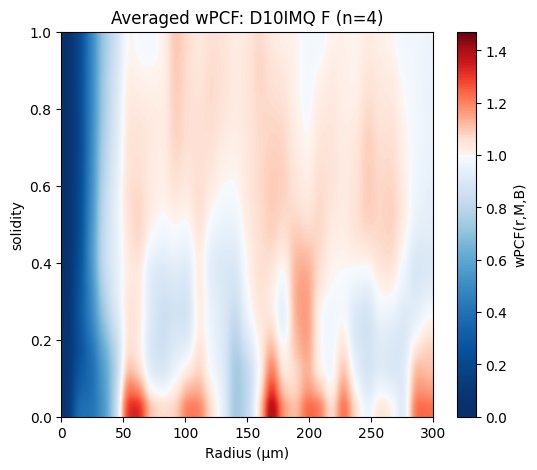

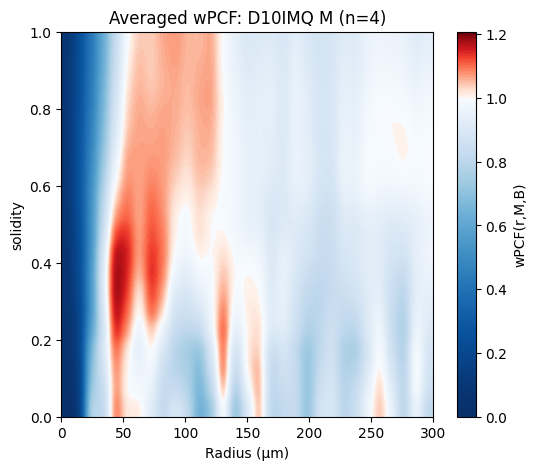

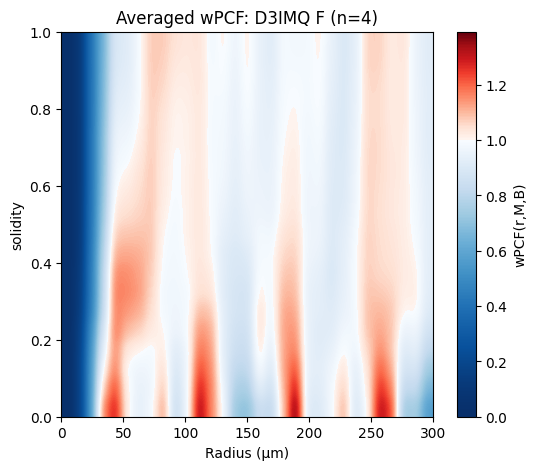

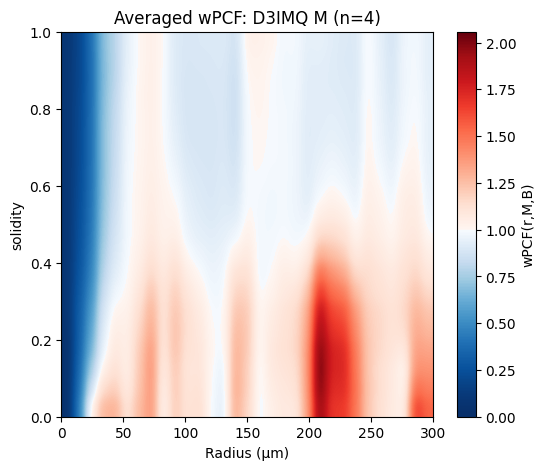

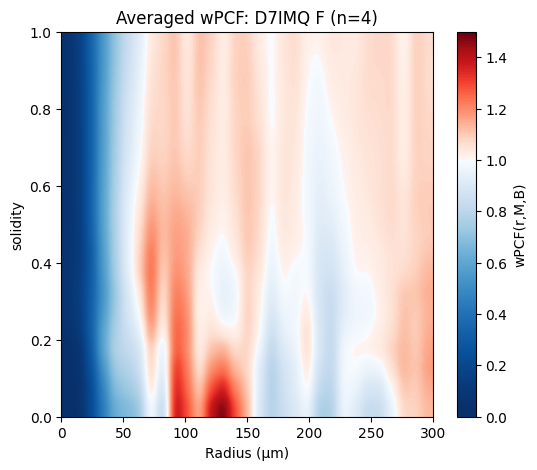

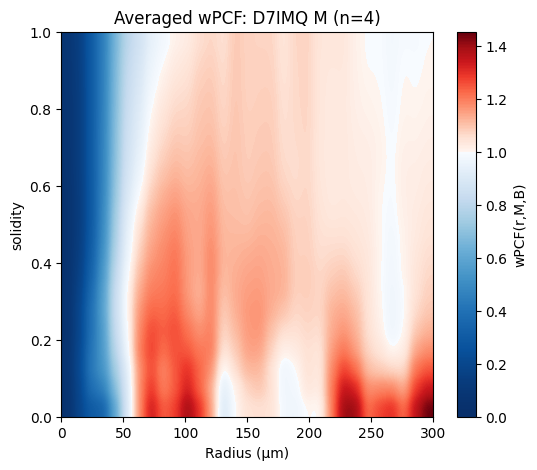

In [40]:
import numpy as np
import re
import matplotlib.pyplot as plt

"""GLOBAL_AREA_MIN = 0     
GLOBAL_AREA_MAX = 300 
GLOBAL_AREA_STEP = 25   """ #only use if trying to get area to work

grouped_wpcfs = {}
shared_radii = None

for name, domain in sorted(rep_domains.items()):
    
    match = re.match(r"^([A-Za-z0-9]+_[FM])", name)
    if not match:
        continue
        
    group_key = match.group(1) 
    
    if group_key not in grouped_wpcfs:
        grouped_wpcfs[group_key] = []

    cellA = ms.query.query(domain, ('celltype_assignments'), 'is', 'activated_basal_KC')
    cellB = ms.query.query(domain, ('celltype_assignments'), 'is', 'M2-like_macrophage')

    radii, wPCF = ms.spatial_statistics.weighted_pair_correlation_function(
        domain, cellA, cellB, 
        mark_pop_B=morph_prop, 
        max_R=300, 
        annulus_step=10, 
        annulus_width=15,
        # mark_min_pop_B=GLOBAL_AREA_MIN,   
        # mark_max_pop_B=GLOBAL_AREA_MAX,   
        # mark_step_pop_B=GLOBAL_AREA_STEP  
    )       
    
    
    # 2. Keep the longest radii array for the final visualization
    if shared_radii is None or len(radii) > len(shared_radii):
        shared_radii = radii

    grouped_wpcfs[group_key].append(wPCF)

print("-" * 40)

# 3. Average the arrays with NaN Padding
averaged_wpcfs = {}

for group_key, wpcf_list in grouped_wpcfs.items():
    
    # Find the maximum rows and columns for this group
    max_rows = max([arr.shape[0] for arr in wpcf_list])
    max_cols = max([arr.shape[1] for arr in wpcf_list])
    
    padded_list = []
    
    for arr in wpcf_list:
        # Calculate how much padding is needed for rows and cols
        pad_rows = max_rows - arr.shape[0]
        pad_cols = max_cols - arr.shape[1]
        
        # Pad the bottom and right edges with NaNs
        padded_arr = np.pad(
            arr, 
            ((0, pad_rows), (0, pad_cols)), 
            mode='constant', 
            constant_values=np.nan
        )
        padded_list.append(padded_arr)

    # Now all arrays in the list are the exact same shape, so this will work:
    avg_wpcf = np.nanmean(padded_list, axis=0)
    averaged_wpcfs[group_key] = avg_wpcf
    
    
    fig, ax = ms.visualise.visualise_wpcf(
        shared_radii, 
        avg_wpcf, 
        figure_kwargs={'figsize': (6, 5)}
    )


    ax.set_title(f"Averaged wPCF: {group_key.replace("_", " ")} (n={len(wpcf_list)})")
    ax.set_ylabel(f"{morph_prop.replace("_", " ")}")
    ax.set_xlabel("Radius (µm)")
    
    plt.show()

----------------------------------------


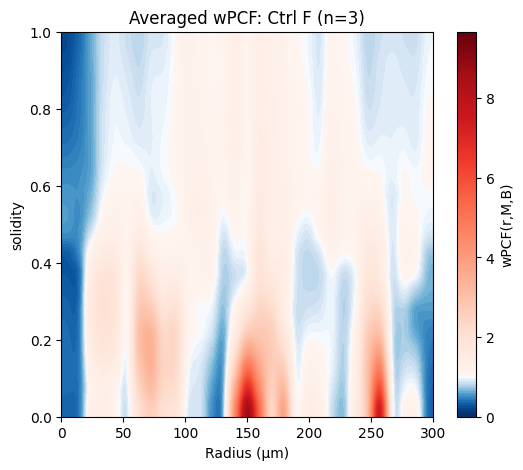

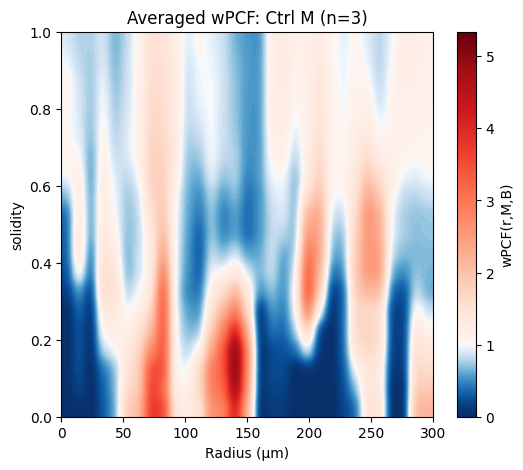

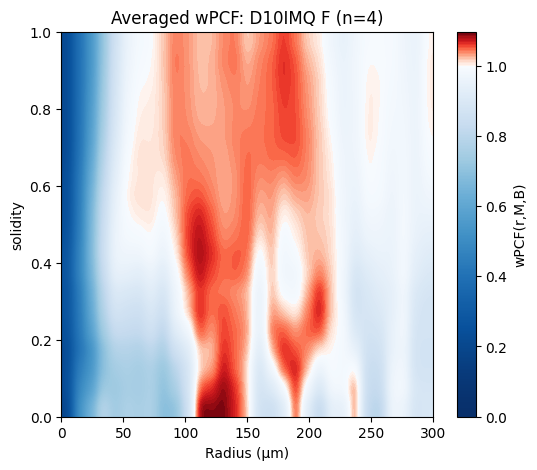

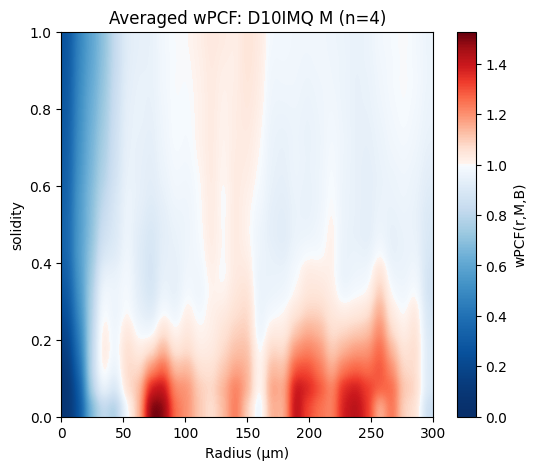

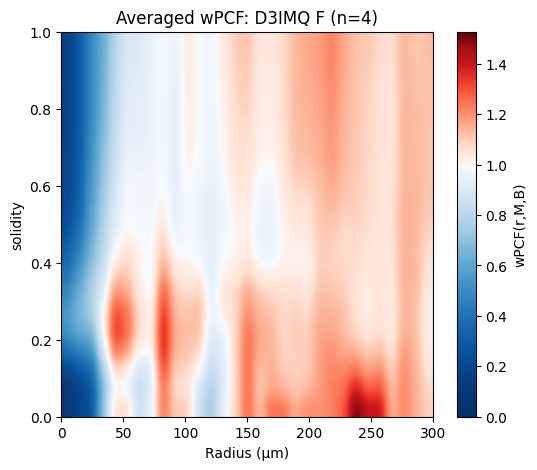

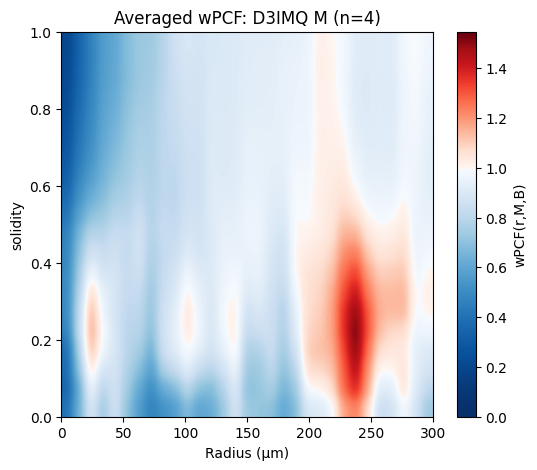

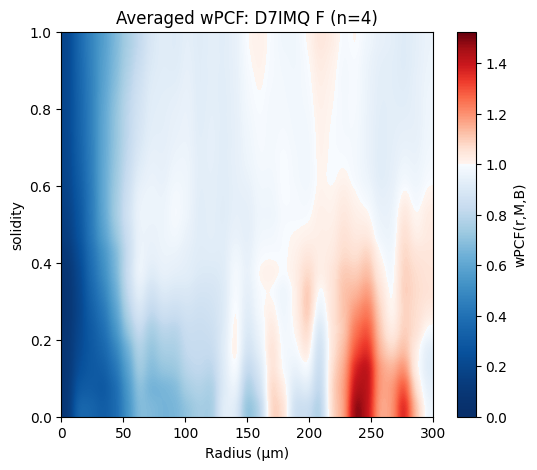

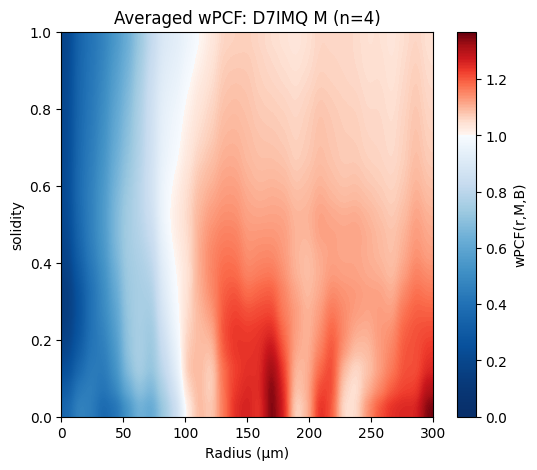

In [41]:
import numpy as np
import re
import matplotlib.pyplot as plt

"""GLOBAL_AREA_MIN = 0     
GLOBAL_AREA_MAX = 300 
GLOBAL_AREA_STEP = 25   """ #only use if trying to get area to work

grouped_wpcfs = {}
shared_radii = None

for name, domain in sorted(rep_domains.items()):
    
    match = re.match(r"^([A-Za-z0-9]+_[FM])", name)
    if not match:
        continue
        
    group_key = match.group(1) 
    
    if group_key not in grouped_wpcfs:
        grouped_wpcfs[group_key] = []

    cellA = ms.query.query(domain, ('celltype_assignments'), 'is', 'activated_basal_KC')
    cellB = ms.query.query(domain, ('celltype_assignments'), 'is', 'dermal_fibroblast')

    radii, wPCF = ms.spatial_statistics.weighted_pair_correlation_function(
        domain, cellA, cellB, 
        mark_pop_B=morph_prop, 
        max_R=300, 
        annulus_step=10, 
        annulus_width=15,
        # mark_min_pop_B=GLOBAL_AREA_MIN,   
        # mark_max_pop_B=GLOBAL_AREA_MAX,   
        # mark_step_pop_B=GLOBAL_AREA_STEP  
    )       
    
    
    # 2. Keep the longest radii array for the final visualization
    if shared_radii is None or len(radii) > len(shared_radii):
        shared_radii = radii

    grouped_wpcfs[group_key].append(wPCF)

print("-" * 40)

# 3. Average the arrays with NaN Padding
averaged_wpcfs = {}

for group_key, wpcf_list in grouped_wpcfs.items():
    
    # Find the maximum rows and columns for this group
    max_rows = max([arr.shape[0] for arr in wpcf_list])
    max_cols = max([arr.shape[1] for arr in wpcf_list])
    
    padded_list = []
    
    for arr in wpcf_list:
        # Calculate how much padding is needed for rows and cols
        pad_rows = max_rows - arr.shape[0]
        pad_cols = max_cols - arr.shape[1]
        
        # Pad the bottom and right edges with NaNs
        padded_arr = np.pad(
            arr, 
            ((0, pad_rows), (0, pad_cols)), 
            mode='constant', 
            constant_values=np.nan
        )
        padded_list.append(padded_arr)

    # Now all arrays in the list are the exact same shape, so this will work:
    avg_wpcf = np.nanmean(padded_list, axis=0)
    averaged_wpcfs[group_key] = avg_wpcf
    
    
    fig, ax = ms.visualise.visualise_wpcf(
        shared_radii, 
        avg_wpcf, 
        figure_kwargs={'figsize': (6, 5)}
    )


    ax.set_title(f"Averaged wPCF: {group_key.replace("_", " ")} (n={len(wpcf_list)})")
    ax.set_ylabel(f"{morph_prop.replace("_", " ")}")
    ax.set_xlabel("Radius (µm)")
    
    plt.show()

### Better plotting of averaged wPCF

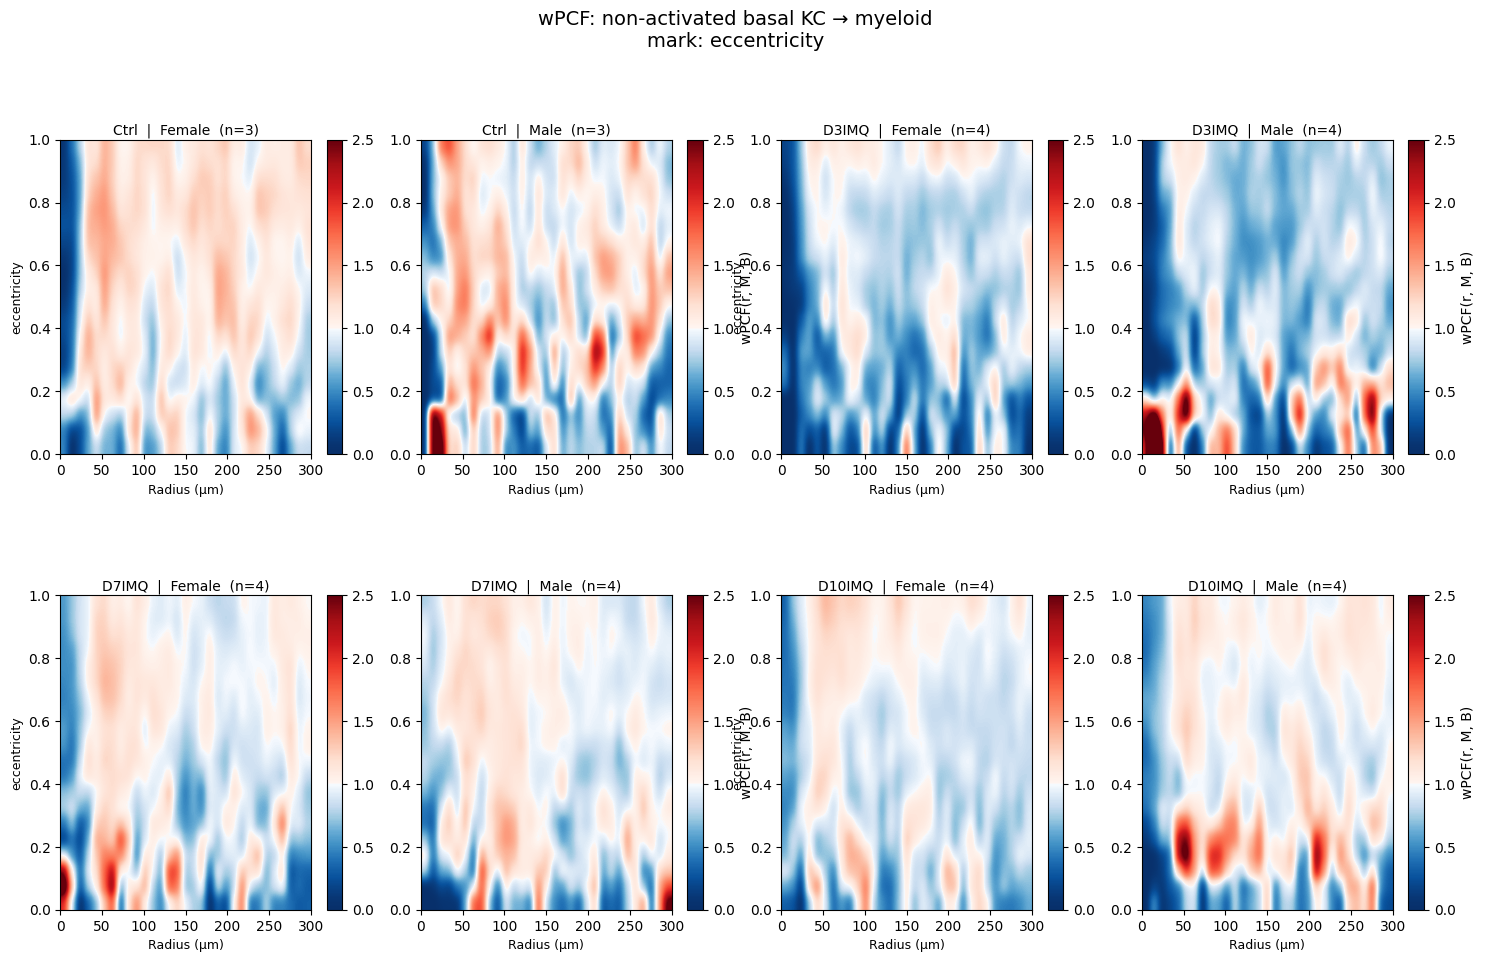

In [4]:
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ── 1. Compute wPCFs and average per group (same as before) ──────────────────

grouped_wpcfs = {}
shared_radii  = None

for name, domain in sorted(rep_domains.items()):
    match = re.match(r"^([A-Za-z0-9]+_[FM])", name)
    if not match:
        continue
    group_key = match.group(1)

    if group_key not in grouped_wpcfs:
        grouped_wpcfs[group_key] = []

    cellA = ms.query.query(domain, ('celltype_assignments'), 'is', 'basal_KC')
    cellB = ms.query.query(domain, ('celltype_assignments'), 'is', 'myeloid')

    radii, wPCF = ms.spatial_statistics.weighted_pair_correlation_function(
        domain, cellA, cellB,
        mark_pop_B=morph_prop,
        max_R=300,
        annulus_step=10,
        annulus_width=15,
    )

    if shared_radii is None or len(radii) > len(shared_radii):
        shared_radii = radii

    grouped_wpcfs[group_key].append(wPCF)

# ── 2. Average across replicates ─────────────────────────────────────────────

averaged_wpcfs = {}

for group_key, wpcf_list in grouped_wpcfs.items():
    max_rows = max(arr.shape[0] for arr in wpcf_list)
    max_cols = max(arr.shape[1] for arr in wpcf_list)

    padded_list = []
    for arr in wpcf_list:
        padded_arr = np.pad(
            arr,
            ((0, max_rows - arr.shape[0]), (0, max_cols - arr.shape[1])),
            mode='constant',
            constant_values=np.nan
        )
        padded_list.append(padded_arr)

    averaged_wpcfs[group_key] = np.nanmean(padded_list, axis=0)

# ── 3. Global colorbar limit across all groups ───────────────────────────────

# colorbar_limit = max(
#     np.nanmax(np.abs(avg))
#     for avg in averaged_wpcfs.values()
# )
colorbar_limit = 2.5

# ── 4. Layout: 2 rows x 4 cols, each adjacent pair = one condition ───────────
# Column pairs:  0-1 = Ctrl,  2-3 = D3IMQ,  4-5 = D7IMQ,  6-7 = D10IMQ
# Rows:          0   = top,   1   = bottom

condition_layout = [
    ("Ctrl",   0, 0),   # (condition, grid_row, col_pair_index)
    ("D3IMQ",  0, 1),
    ("D7IMQ",  1, 0),
    ("D10IMQ", 1, 1),
]

sexes      = ["F", "M"]
sex_labels = {"F": "Female", "M": "Male"}

fig = plt.figure(figsize=(18, 10))

# Small hspace/wspace between individual axes; larger gap between condition blocks
# achieved by leaving column 4 and row 2 slightly wider via GridSpec ratios
gs = GridSpec(
    nrows=2, ncols=4,
    figure=fig,
    hspace=0.45,
    wspace=0.15,
)

for condition, grid_row, col_pair in condition_layout:
    col_base = col_pair * 2          # first of the two columns for this condition

    for sex_idx, sex in enumerate(sexes):
        group_key = f"{condition}_{sex}"
        ax        = fig.add_subplot(gs[grid_row, col_base + sex_idx])

        if group_key not in averaged_wpcfs:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10)
            ax.set_title(f"{condition} – {sex_labels[sex]}", fontsize=10)
            continue

        avg_wpcf   = averaged_wpcfs[group_key]
        n_reps     = len(grouped_wpcfs[group_key])

        # Only pass a colorbar to the rightmost panel of each condition pair
        # to avoid four colorbars per row; a single shared one is added after
        _, _ = ms.visualise.visualise_wpcf(
            shared_radii,
            avg_wpcf,
            ax=ax,
            colorbar_limit=colorbar_limit,
            cbar_kwargs={"label": "wPCF(r, M, B)"} if sex_idx == 1 else {"label":""},
        )

        ax.set_title(
            f"{condition}  |  {sex_labels[sex]}  (n={n_reps})",
            fontsize=10, pad=4
        )

        # Only label outer axes to reduce clutter
        if sex_idx == 0:
            ax.set_ylabel(morph_prop.replace("_", " "), fontsize=9)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Radius (µm)", fontsize=9)

fig.suptitle(
    f"wPCF: non-activated basal KC → myeloid\n"
    f"mark: {morph_prop.replace('_', ' ')}",
    fontsize=14, y=1.01
)

plt.tight_layout()

plt.savefig(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\morph_props figures\nonactbKC_myeloid_wPCF", dpi = 500, bbox_inches = 'tight')

plt.show()

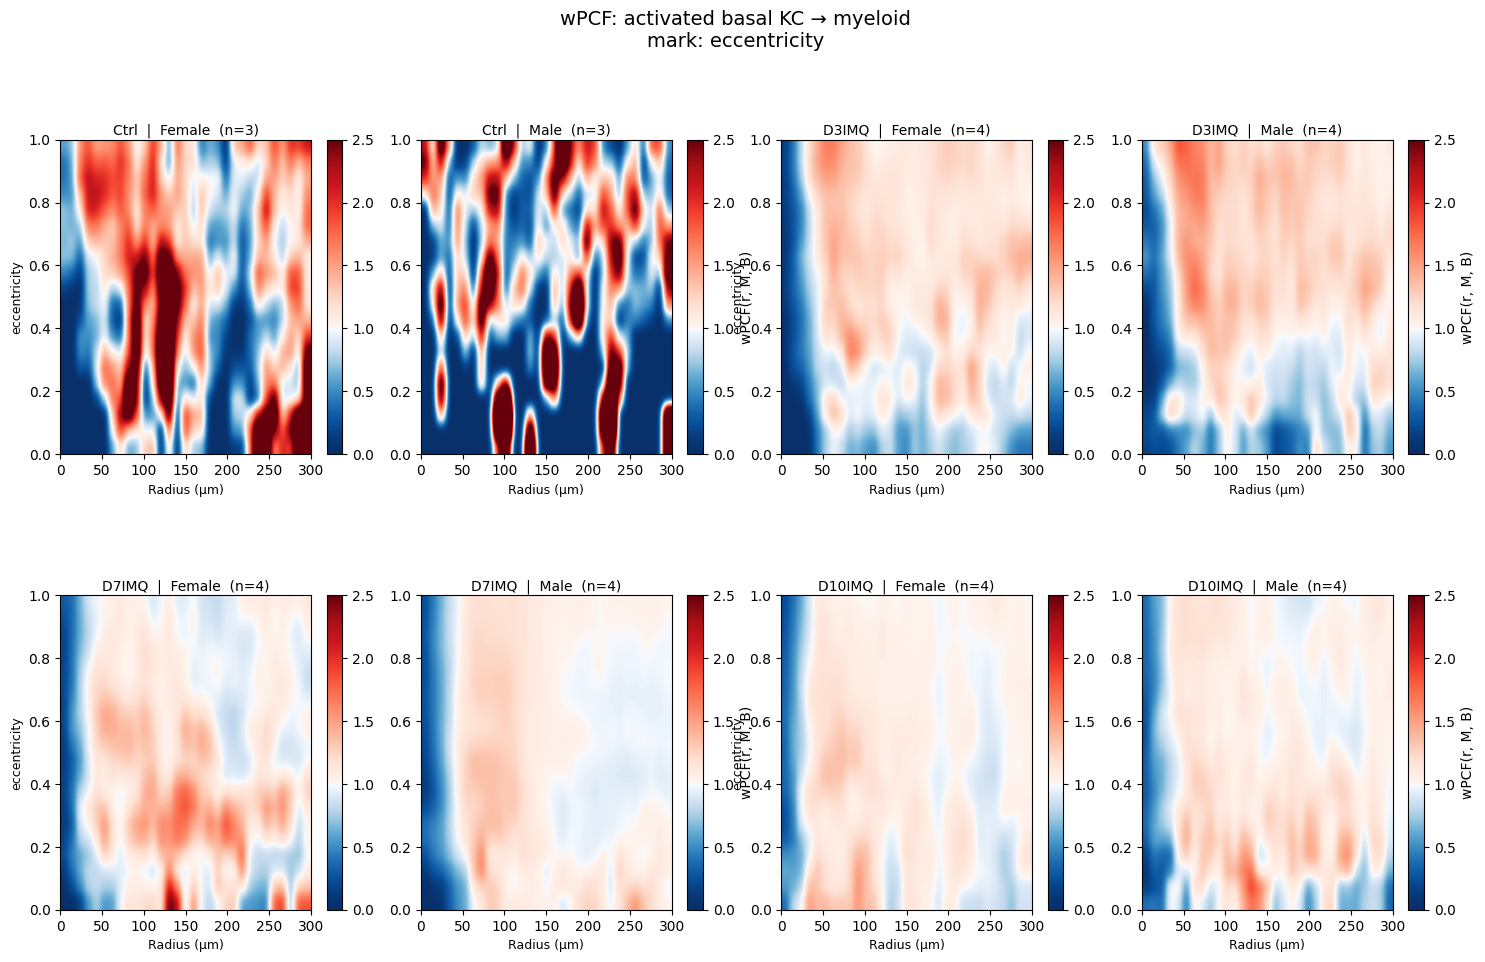

In [7]:
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ── 1. Compute wPCFs and average per group (same as before) ──────────────────

grouped_wpcfs = {}
shared_radii  = None

for name, domain in sorted(rep_domains.items()):
    match = re.match(r"^([A-Za-z0-9]+_[FM])", name)
    if not match:
        continue
    group_key = match.group(1)

    if group_key not in grouped_wpcfs:
        grouped_wpcfs[group_key] = []

    cellA = ms.query.query(domain, ('celltype_assignments'), 'is', 'activated_basal_KC')
    cellB = ms.query.query(domain, ('celltype_assignments'), 'is', 'myeloid')

    radii, wPCF = ms.spatial_statistics.weighted_pair_correlation_function(
        domain, cellA, cellB,
        mark_pop_B=morph_prop,
        max_R=300,
        annulus_step=10,
        annulus_width=15,
    )

    if shared_radii is None or len(radii) > len(shared_radii):
        shared_radii = radii

    grouped_wpcfs[group_key].append(wPCF)

# ── 2. Average across replicates ─────────────────────────────────────────────

averaged_wpcfs = {}

for group_key, wpcf_list in grouped_wpcfs.items():
    max_rows = max(arr.shape[0] for arr in wpcf_list)
    max_cols = max(arr.shape[1] for arr in wpcf_list)

    padded_list = []
    for arr in wpcf_list:
        padded_arr = np.pad(
            arr,
            ((0, max_rows - arr.shape[0]), (0, max_cols - arr.shape[1])),
            mode='constant',
            constant_values=np.nan
        )
        padded_list.append(padded_arr)

    averaged_wpcfs[group_key] = np.nanmean(padded_list, axis=0)

# ── 3. Global colorbar limit across all groups ───────────────────────────────

# colorbar_limit = max(
#     np.nanmax(np.abs(avg))
#     for avg in averaged_wpcfs.values()
# )
colorbar_limit = 2.5

# ── 4. Layout: 2 rows x 4 cols, each adjacent pair = one condition ───────────
# Column pairs:  0-1 = Ctrl,  2-3 = D3IMQ,  4-5 = D7IMQ,  6-7 = D10IMQ
# Rows:          0   = top,   1   = bottom

condition_layout = [
    ("Ctrl",   0, 0),   # (condition, grid_row, col_pair_index)
    ("D3IMQ",  0, 1),
    ("D7IMQ",  1, 0),
    ("D10IMQ", 1, 1),
]

sexes      = ["F", "M"]
sex_labels = {"F": "Female", "M": "Male"}

fig = plt.figure(figsize=(18, 10))

# Small hspace/wspace between individual axes; larger gap between condition blocks
# achieved by leaving column 4 and row 2 slightly wider via GridSpec ratios
gs = GridSpec(
    nrows=2, ncols=4,
    figure=fig,
    hspace=0.45,
    wspace=0.15,
)

for condition, grid_row, col_pair in condition_layout:
    col_base = col_pair * 2          # first of the two columns for this condition

    for sex_idx, sex in enumerate(sexes):
        group_key = f"{condition}_{sex}"
        ax        = fig.add_subplot(gs[grid_row, col_base + sex_idx])

        if group_key not in averaged_wpcfs:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10)
            ax.set_title(f"{condition} – {sex_labels[sex]}", fontsize=10)
            continue

        avg_wpcf   = averaged_wpcfs[group_key]
        n_reps     = len(grouped_wpcfs[group_key])

        # Only pass a colorbar to the rightmost panel of each condition pair
        # to avoid four colorbars per row; a single shared one is added after
        _, _ = ms.visualise.visualise_wpcf(
            shared_radii,
            avg_wpcf,
            ax=ax,
            colorbar_limit=colorbar_limit,
            cbar_kwargs={"label": "wPCF(r, M, B)"} if sex_idx == 1 else {"label":""},
        )

        ax.set_title(
            f"{condition}  |  {sex_labels[sex]}  (n={n_reps})",
            fontsize=10, pad=4
        )

        # Only label outer axes to reduce clutter
        if sex_idx == 0:
            ax.set_ylabel(morph_prop.replace("_", " "), fontsize=9)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Radius (µm)", fontsize=9)

fig.suptitle(
    f"wPCF: activated basal KC → myeloid\n"
    f"mark: {morph_prop.replace('_', ' ')}",
    fontsize=14, y=1.01
)

plt.tight_layout()

plt.savefig(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\morph_props figures\ActbKC_myeloid_wPCF", dpi = 500, bbox_inches = 'tight')

plt.show()

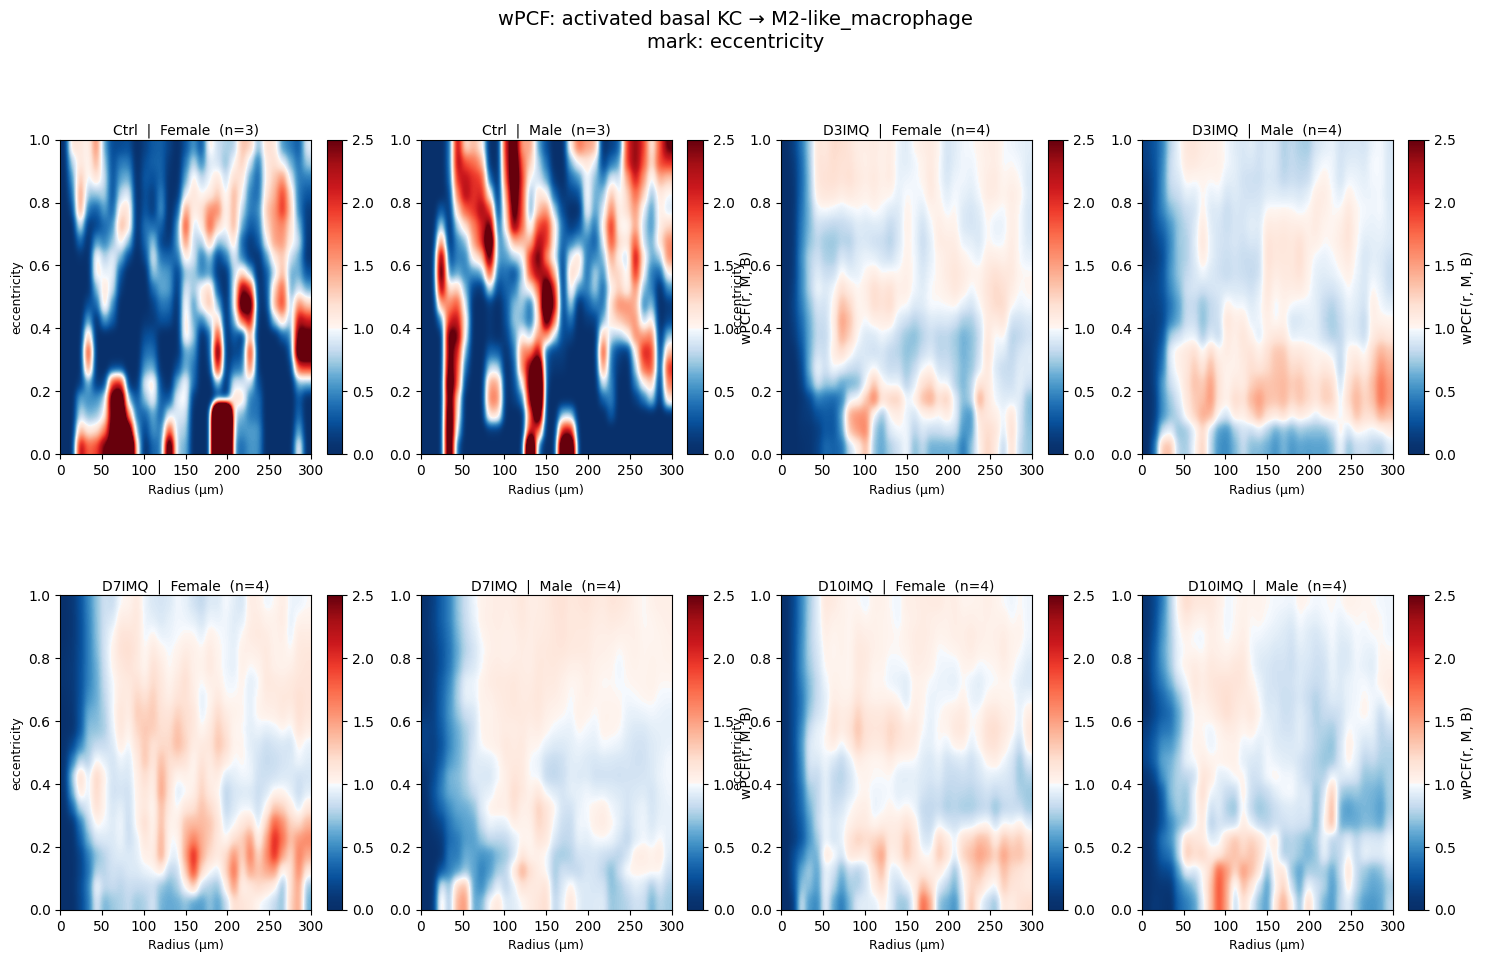

In [5]:
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ── 1. Compute wPCFs and average per group (same as before) ──────────────────

grouped_wpcfs = {}
shared_radii  = None

for name, domain in sorted(rep_domains.items()):
    match = re.match(r"^([A-Za-z0-9]+_[FM])", name)
    if not match:
        continue
    group_key = match.group(1)

    if group_key not in grouped_wpcfs:
        grouped_wpcfs[group_key] = []

    cellA = ms.query.query(domain, ('celltype_assignments'), 'is', 'activated_basal_KC')
    cellB = ms.query.query(domain, ('celltype_assignments'), 'is', 'M2-like_macrophage')

    radii, wPCF = ms.spatial_statistics.weighted_pair_correlation_function(
        domain, cellA, cellB,
        mark_pop_B=morph_prop,
        max_R=300,
        annulus_step=10,
        annulus_width=15,
    )

    if shared_radii is None or len(radii) > len(shared_radii):
        shared_radii = radii

    grouped_wpcfs[group_key].append(wPCF)

# ── 2. Average across replicates ─────────────────────────────────────────────

averaged_wpcfs = {}

for group_key, wpcf_list in grouped_wpcfs.items():
    max_rows = max(arr.shape[0] for arr in wpcf_list)
    max_cols = max(arr.shape[1] for arr in wpcf_list)

    padded_list = []
    for arr in wpcf_list:
        padded_arr = np.pad(
            arr,
            ((0, max_rows - arr.shape[0]), (0, max_cols - arr.shape[1])),
            mode='constant',
            constant_values=np.nan
        )
        padded_list.append(padded_arr)

    averaged_wpcfs[group_key] = np.nanmean(padded_list, axis=0)

# ── 3. Global colorbar limit across all groups ───────────────────────────────

# colorbar_limit = max(
#     np.nanmax(np.abs(avg))
#     for avg in averaged_wpcfs.values()
# )
colorbar_limit = 2.5

# ── 4. Layout: 2 rows x 4 cols, each adjacent pair = one condition ───────────
# Column pairs:  0-1 = Ctrl,  2-3 = D3IMQ,  4-5 = D7IMQ,  6-7 = D10IMQ
# Rows:          0   = top,   1   = bottom

condition_layout = [
    ("Ctrl",   0, 0),   # (condition, grid_row, col_pair_index)
    ("D3IMQ",  0, 1),
    ("D7IMQ",  1, 0),
    ("D10IMQ", 1, 1),
]

sexes      = ["F", "M"]
sex_labels = {"F": "Female", "M": "Male"}

fig = plt.figure(figsize=(18, 10))

# Small hspace/wspace between individual axes; larger gap between condition blocks
# achieved by leaving column 4 and row 2 slightly wider via GridSpec ratios
gs = GridSpec(
    nrows=2, ncols=4,
    figure=fig,
    hspace=0.45,
    wspace=0.15,
)

for condition, grid_row, col_pair in condition_layout:
    col_base = col_pair * 2          # first of the two columns for this condition

    for sex_idx, sex in enumerate(sexes):
        group_key = f"{condition}_{sex}"
        ax        = fig.add_subplot(gs[grid_row, col_base + sex_idx])

        if group_key not in averaged_wpcfs:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10)
            ax.set_title(f"{condition} – {sex_labels[sex]}", fontsize=10)
            continue

        avg_wpcf   = averaged_wpcfs[group_key]
        n_reps     = len(grouped_wpcfs[group_key])

        # Only pass a colorbar to the rightmost panel of each condition pair
        # to avoid four colorbars per row; a single shared one is added after
        _, _ = ms.visualise.visualise_wpcf(
            shared_radii,
            avg_wpcf,
            ax=ax,
            colorbar_limit=colorbar_limit,
            cbar_kwargs={"label": "wPCF(r, M, B)"} if sex_idx == 1 else {"label":""},
        )

        ax.set_title(
            f"{condition}  |  {sex_labels[sex]}  (n={n_reps})",
            fontsize=10, pad=4
        )

        # Only label outer axes to reduce clutter
        if sex_idx == 0:
            ax.set_ylabel(morph_prop.replace("_", " "), fontsize=9)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Radius (µm)", fontsize=9)

fig.suptitle(
    f"wPCF: activated basal KC → M2-like_macrophage\n"
    f"mark: {morph_prop.replace('_', ' ')}",
    fontsize=14, y=1.01
)

plt.tight_layout()

plt.savefig(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\morph_props figures\actbKC_M2_wPCF", dpi = 500, bbox_inches = 'tight')

plt.show()

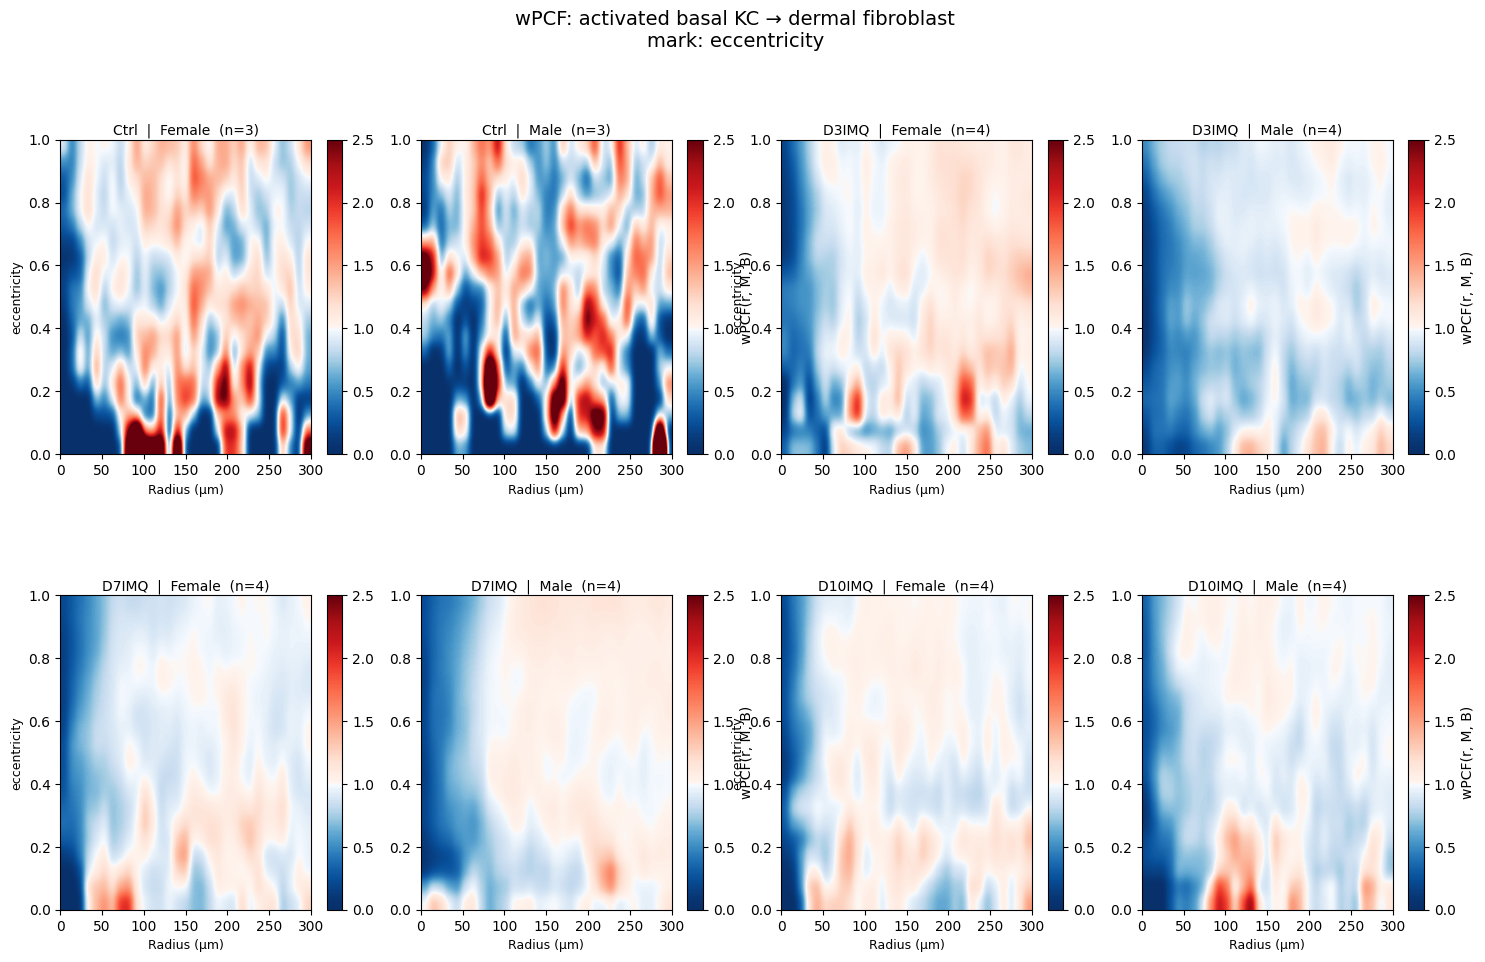

In [9]:
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ── 1. Compute wPCFs and average per group (same as before) ──────────────────

grouped_wpcfs = {}
shared_radii  = None

for name, domain in sorted(rep_domains.items()):
    match = re.match(r"^([A-Za-z0-9]+_[FM])", name)
    if not match:
        continue
    group_key = match.group(1)

    if group_key not in grouped_wpcfs:
        grouped_wpcfs[group_key] = []

    cellA = ms.query.query(domain, ('celltype_assignments'), 'is', 'activated_basal_KC')
    cellB = ms.query.query(domain, ('celltype_assignments'), 'is', 'dermal_fibroblast')

    radii, wPCF = ms.spatial_statistics.weighted_pair_correlation_function(
        domain, cellA, cellB,
        mark_pop_B=morph_prop,
        max_R=300,
        annulus_step=10,
        annulus_width=15,
    )

    if shared_radii is None or len(radii) > len(shared_radii):
        shared_radii = radii

    grouped_wpcfs[group_key].append(wPCF)

# ── 2. Average across replicates ─────────────────────────────────────────────

averaged_wpcfs = {}

for group_key, wpcf_list in grouped_wpcfs.items():
    max_rows = max(arr.shape[0] for arr in wpcf_list)
    max_cols = max(arr.shape[1] for arr in wpcf_list)

    padded_list = []
    for arr in wpcf_list:
        padded_arr = np.pad(
            arr,
            ((0, max_rows - arr.shape[0]), (0, max_cols - arr.shape[1])),
            mode='constant',
            constant_values=np.nan
        )
        padded_list.append(padded_arr)

    averaged_wpcfs[group_key] = np.nanmean(padded_list, axis=0)

# ── 3. Global colorbar limit across all groups ───────────────────────────────

# colorbar_limit = max(
#     np.nanmax(np.abs(avg))
#     for avg in averaged_wpcfs.values()
# )
#just using a baselevel for now, as control skews this badly
colorbar_limit = 2.5

# ── 4. Layout: 2 rows x 4 cols, each adjacent pair = one condition ───────────
# Column pairs:  0-1 = Ctrl,  2-3 = D3IMQ,  4-5 = D7IMQ,  6-7 = D10IMQ
# Rows:          0   = top,   1   = bottom

condition_layout = [
    ("Ctrl",   0, 0),   # (condition, grid_row, col_pair_index)
    ("D3IMQ",  0, 1),
    ("D7IMQ",  1, 0),
    ("D10IMQ", 1, 1),
]

sexes      = ["F", "M"]
sex_labels = {"F": "Female", "M": "Male"}

fig = plt.figure(figsize=(18, 10))

# Small hspace/wspace between individual axes; larger gap between condition blocks
# achieved by leaving column 4 and row 2 slightly wider via GridSpec ratios
gs = GridSpec(
    nrows=2, ncols=4,
    figure=fig,
    hspace=0.45,
    wspace=0.15,
)

for condition, grid_row, col_pair in condition_layout:
    col_base = col_pair * 2          # first of the two columns for this condition

    for sex_idx, sex in enumerate(sexes):
        group_key = f"{condition}_{sex}"
        ax        = fig.add_subplot(gs[grid_row, col_base + sex_idx])

        if group_key not in averaged_wpcfs:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10)
            ax.set_title(f"{condition} – {sex_labels[sex]}", fontsize=10)
            continue

        avg_wpcf   = averaged_wpcfs[group_key]
        n_reps     = len(grouped_wpcfs[group_key])

        # Only pass a colorbar to the rightmost panel of each condition pair
        # to avoid four colorbars per row; a single shared one is added after
        _, _ = ms.visualise.visualise_wpcf(
            shared_radii,
            avg_wpcf,
            ax=ax,
            colorbar_limit=colorbar_limit,
            cbar_kwargs={"label": "wPCF(r, M, B)"} if sex_idx == 1 else {"label":""},
        )

        ax.set_title(
            f"{condition}  |  {sex_labels[sex]}  (n={n_reps})",
            fontsize=10, pad=4
        )

        # Only label outer axes to reduce clutter
        if sex_idx == 0:
            ax.set_ylabel(morph_prop.replace("_", " "), fontsize=9)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Radius (µm)", fontsize=9)

fig.suptitle(
    f"wPCF: activated basal KC → dermal fibroblast\n"
    f"mark: {morph_prop.replace('_', ' ')}",
    fontsize=14, y=1.01
)

plt.tight_layout()

plt.savefig(r"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\morph_props figures\actbKC_fibroblast_wPCF", dpi = 500, bbox_inches = 'tight')


plt.show()